<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:120%; text-align:left">
<h3 align="left"><font color=pink>Problem:</font></h3>
In this project, l work with a real world credit card dataset covering <b>34,788 clients</b> across a six-month period (April–September 2005).
<br>My goal is to develop a <b>predictive model</b> capable of identifying clients likely to <b>default on their next monthly payment</b>.
</div>

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
<h3 align="left"><font color=pink>Assignment Structure:</font></h3>
<ul>
<li><b>Step 1</b> — Import Libraries</li>
<li><b>Step 2</b> — Load Dataset</li>
<li><b>Step 3</b> — Define Feature Types</li>
<li><b>Task 1 (20%)</b> — Exploratory Data Analysis</li>
<li><b>Task 2 (20%)</b> — Data Preparation</li>
<li><b>Task 3 (20%)</b> — Model Training</li>
<li><b>Task 4 (20%)</b> — Model Evaluation and Visualisation</li>
<li><b>Task 5 (20%)</b> — Conclusion and Future Work</li>
</ul>
</div>

---

# **Step 1 | Import Libraries**

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm


import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

!pip install category_encoders --quiet

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from category_encoders import TargetEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

import shap

%matplotlib inline
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

print("All imports successful.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.5 MB/s eta 0:00:00
All imports successful.


---

# **Step 2 | Load Dataset**

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
The dataset is loaded from CSV. We take an initial look at shape, column types, and raw values before any transformation.
No changes are made to the data here — this is purely observational.
</div>

In [ ]:
df = pd.read_csv("Credit_Card.csv", sep=';', on_bad_lines='warn')

print(f"Shape: {df.shape[0]:,} rows  |  {df.shape[1]} columns")
display(df.head())

Shape: 34,788 rows  |  30 columns


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,1,20000.0000,2.0000,2.0000,NaN,24.0000,2,2,-1,-1,-2,-2,3913.0000,3102.0000,689.0000,0.0000,0.0000,0.0000,0.0000,689.0000,0.0000,0.0000,0.0000,0.0000,1,1.075.675.276.433.290,7704.0000,990.353.755.128.617,City_38,2
1,2,120000.0000,2.0000,2.0000,2.0000,26.0000,-1,2,0,0,0,2,2682.0000,1725.0000,2682.0000,3272.0000,3455.0000,3261.0000,0.0000,1000.0000,1000.0000,1000.0000,0.0000,2000.0000,1,10.940.840.854.872.400,17077.0000,11.695.255.355.062.700,City_6,1
2,3,90000.0000,2.0000,2.0000,2.0000,34.0000,0,0,0,0,0,0,29239.0000,14027.0000,13559.0000,14331.0000,14948.0000,15549.0000,1518.0000,1500.0000,1000.0000,1000.0000,1000.0000,5000.0000,0,0.0703022492301175,101653.0000,11.407.576.060.361.700,City_20,1
3,4,50000.0000,2.0000,2.0000,1.0000,37.0000,0,0,0,0,0,0,46990.0000,48233.0000,49291.0000,28314.0000,28959.0000,29547.0000,2000.0000,2019.0000,1200.0000,1100.0000,1069.0000,1000.0000,0,0.058442435467177846,231334.0000,10.819.798.284.210.200,City_25,1
4,5,50000.0000,1.0000,2.0000,1.0000,57.0000,-1,0,-1,0,0,0,8617.0000,5670.0000,35835.0000,20940.0000,19146.0000,19131.0000,2000.0000,36681.0000,10000.0000,9000.0000,689.0000,679.0000,0,0.12943102887089503,109339.0000,10.819.798.284.210.200,City_44,1


## <b><span style='color:#ff826e'>Step 2.1 |</span><span style='color:red'> Dataset Basic Information</span></b>

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34788 entries, 0 to 34787
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          34788 non-null  int64  
 1   LIMIT_BAL                   33079 non-null  float64
 2   SEX                         33021 non-null  float64
 3   EDUCATION                   33054 non-null  float64
 4   MARRIAGE                    33055 non-null  float64
 5   AGE                         33033 non-null  float64
 6   PAY_0                       34788 non-null  int64  
 7   PAY_2                       34788 non-null  int64  
 8   PAY_3                       34788 non-null  int64  
 9   PAY_4                       34788 non-null  int64  
 10  PAY_5                       34788 non-null  int64  
 11  PAY_6                       34788 non-null  int64  
 12  BILL_AMT1                   34788 non-null  float64
 13  BILL_AMT2                   347

## <b><span style='color:#ff826e'>Step 2.2 |</span><span style='color:red'> Summary Statistics — Numerical Variables</span></b>

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,34788.0000,15006.2069,8670.8025,1.0000,7477.7500,15004.5000,22526.2500,30000.0000
LIMIT_BAL,33079.0000,184668.9948,235931.9309,10000.0000,60000.0000,140000.0000,240000.0000,5600000.0000
SEX,33021.0000,1.6043,0.4890,1.0000,1.0000,2.0000,2.0000,2.0000
EDUCATION,33054.0000,1.8512,0.7908,0.0000,1.0000,2.0000,2.0000,6.0000
MARRIAGE,33055.0000,1.5509,0.5215,0.0000,1.0000,2.0000,2.0000,3.0000
AGE,33033.0000,35.5183,9.2368,21.0000,28.0000,34.0000,41.0000,79.0000
PAY_0,34788.0000,-0.0458,1.1033,-2.0000,-1.0000,0.0000,0.0000,8.0000
PAY_2,34788.0000,-0.1569,1.1775,-2.0000,-1.0000,0.0000,0.0000,8.0000
PAY_3,34788.0000,-0.1856,1.1804,-2.0000,-1.0000,0.0000,0.0000,8.0000
PAY_4,34788.0000,-0.2391,1.1517,-2.0000,-1.0000,0.0000,0.0000,8.0000


## <b><span style='color:#ff826e'>Step 2.3 |</span><span style='color:red'> Summary Statistics — Categorical Variables</span></b>

In [ ]:
df.describe(include="object")

,risk_leak,LIMIT_BAL_LOG,CITY
count,34788,33079,34788
unique,31929,81,50
top,-0.03932257385208661,10.819.798.284.210.200,City_47
freq,4,3730,763


---

# **Step 3 | Define Feature Types**

⚠️ **IMPORTANT NOTE — Semantic vs Stored Data Types**

Several columns are stored as numeric but are categorical or ordinal in semantics:
- **SEX, EDUCATION, MARRIAGE** — nominal category labels stored as float. Treating them as numbers implies false mathematical relationships (e.g. Female=2 is not "twice" Male=1).
- **PAY_0 to PAY_6** — ordinal repayment codes, not arithmetic numbers. Ordering is meaningful; equal spacing is not guaranteed.
- **RISK_RATING** — post-hoc classification label — constitutes leakage.
- **LIMIT_BAL_LOG** — stored as malformed object strings in the source CSV. Recomputed from LIMIT_BAL using np.log — mathematically identical to the intended column.
- **risk_leak** — stored as object, cast to float here for EDA analysis only. Dropped in Task 2.

In [ ]:
TARGET = "default.payment.next.month"

# LIMIT_BAL_LOG is recomputed from LIMIT_BAL — the source CSV stores it with
# malformed dot-separated formatting that cannot be parsed. np.log(LIMIT_BAL)
# is mathematically identical to the intended column.
df["LIMIT_BAL_LOG"] = np.log(df["LIMIT_BAL"])
df["risk_leak"] = pd.to_numeric(df["risk_leak"], errors="coerce")

print("Dtype fixes applied:")
print(df[["LIMIT_BAL_LOG", "risk_leak"]].dtypes)
print()

# Continuous — imputed, winsorised, scaled inside Pipeline
continuous_cols = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6",
    "PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6"
]

# PAY columns — ordinal integers, treated as continuous inside Pipeline
# Tree models: ordering only matters. LR/SVM: equal-spacing assumption (justified in Task 1.7)
pay_cols = ["PAY_1","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]

# Nominal — OHE inside Pipeline
nominal_cols = ["SEX", "EDUCATION", "MARRIAGE"]

# CITY — target encoded inside Pipeline (50 unique values; OHE would produce 49 sparse columns)
city_col = ["CITY"]

print("Feature groups defined.")
print(f"  Continuous:       {len(continuous_cols)} columns")
print(f"  PAY ordinal:      {len(pay_cols)} columns")
print(f"  Nominal OHE:      {nominal_cols}")
print(f"  City target-enc:  {city_col}")

Dtype fixes applied:
LIMIT_BAL_LOG    float64
risk_leak        float64
dtype: object

Feature groups defined.
  Continuous:       14 columns
  PAY ordinal:      6 columns
  Nominal OHE:      ['SEX', 'EDUCATION', 'MARRIAGE']
  City target-enc:  ['CITY']


# **Task 1 | Exploratory Data Analysis**

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
EDA is purely observational — no data is modified here. All findings inform the preprocessing decisions made in Task 2.
<br><br>
For our Exploratory Data Analysis, we take it in two main steps:
<br><br>
&nbsp;&nbsp;&nbsp;&nbsp;<b>1. Univariate Analysis:</b> Focus on ONE feature at a time to understand its distribution, range, and outliers.
<br><br>
&nbsp;&nbsp;&nbsp;&nbsp;<b>2. Bivariate Analysis:</b> Explore the relationship between each feature and the target variable to understand its predictive influence.
<br><br>
<b>Structure:</b>
<br>1.1 &nbsp;Target Variable Distribution — Class Imbalance
<br>1.2 &nbsp;Missing Value Analysis
<br>1.3 &nbsp;Descriptive Statistics — Key Numerical Features
<br>1.4 &nbsp;Univariate Analysis — Numerical Features (Histograms)
<br>1.5 &nbsp;Univariate Analysis — Categorical Features (Bar Charts)
<br>1.6 &nbsp;Outlier Detection — IQR Method and Box Plots
<br>1.7 &nbsp;Bivariate Analysis — Numerical Features vs Target
<br>1.8 &nbsp;Bivariate Analysis — Categorical Features vs Target
<br>1.9 &nbsp;Correlation Analysis
</div>

## <b><span style='color:#ff826e'>Task 1.1 |</span><span style='color:red'> Target Variable Distribution — Class Imbalance</span></b>

=== TARGET VARIABLE DISTRIBUTION ===
No Default (0): 28,132  (80.9%)
Default    (1): 6,656  (19.1%)
Imbalance ratio: 4.23:1


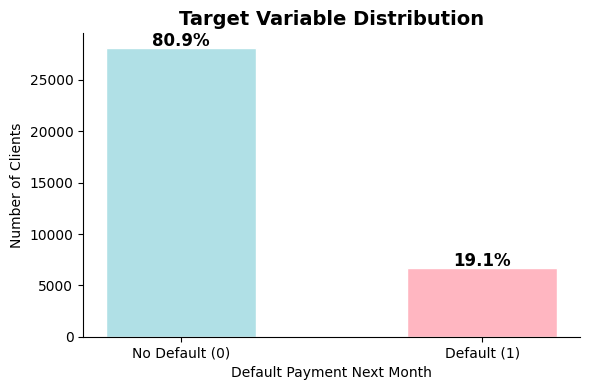

In [ ]:
counts = df[TARGET].value_counts()
pcts   = df[TARGET].value_counts(normalize=True) * 100

print("=== TARGET VARIABLE DISTRIBUTION ===")
print(f"No Default (0): {counts[0]:,}  ({pcts[0]:.1f}%)")
print(f"Default    (1): {counts[1]:,}  ({pcts[1]:.1f}%)")
print(f"Imbalance ratio: {counts[0]/counts[1]:.2f}:1")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["No Default (0)", "Default (1)"], counts.values,
              color=["#B0E0E6", "#FFB6C1"], edgecolor="white", width=0.5)
for bar, pct in zip(bars, pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{pct:.1f}%", ha="center", fontweight="bold", fontsize=12)
ax.set_title("Target Variable Distribution", fontweight="bold", fontsize=14)
ax.set_xlabel("Default Payment Next Month")
ax.set_ylabel("Number of Clients")
plt.tight_layout()
plt.savefig("fig_01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
<h2 align="left"><font color=red>Inferences:</font></h2>
<ul>
<li>The dataset is <b>imbalanced</b>: 80.9% No Default vs 19.1% Default — a ratio of approximately 4.2:1.</li>
<li>A naive model that always predicts No Default would achieve ~81% accuracy while identifying zero defaulters. Accuracy alone is therefore a misleading metric for this problem.</li>
<li><b>class_weight='balanced'</b> will be applied to all applicable classifiers in Task 3, penalising misclassification of the minority class inversely proportional to its frequency.</li>
</ul>
</div>

## <b><span style='color:#ff826e'>Task 1.2 |</span><span style='color:red'> Missing Value Analysis</span></b>

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
Missing values are identified here as part of EDA. The handling strategy for each column is decided and justified in Task 2.
</div>

In [ ]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df  = missing_df[missing_df["Missing Count"] > 0]

print("=== COLUMNS WITH MISSING VALUES ===")
display(missing_df)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

=== COLUMNS WITH MISSING VALUES ===


,Missing Count,Missing %
LIMIT_BAL,1709,4.9100
SEX,1767,5.0800
EDUCATION,1734,4.9800
MARRIAGE,1733,4.9800
AGE,1755,5.0400
PAY_AMT1,1725,4.9600
PAY_AMT2,1744,5.0100
risk_leak,3387,9.7400
LIMIT_BAL_LOG,1709,4.9100



Total missing values: 17263


## <b><span style='color:#ff826e'>Task 1.3 |</span><span style='color:red'> Descriptive Statistics — Key Numerical Features</span></b>

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
Descriptive statistics for the five key columns specified in the assignment brief. All five columns are retained here for analysis — no columns are dropped until Task 2.
</div>

In [ ]:
key_cols = ["LIMIT_BAL", "AGE", "BILL_AMT_SUM", "LIMIT_BAL_LOG", "risk_leak"]

stats = df[key_cols].describe().round(2)

# Add non-null count and missing count rows for clarity
non_null = df[key_cols].notnull().sum().rename("non-null count")
missing  = df[key_cols].isnull().sum().rename("missing count")
total    = pd.Series([len(df)] * len(key_cols), index=key_cols, name="total rows")

summary = pd.concat([total.to_frame().T, non_null.to_frame().T,
                     missing.to_frame().T, stats.drop("count")])

print(f"Total rows in dataset: {len(df):,}")
print("Note: count differs per column due to missing values (~5% per column)")
print()
display(summary)

Total rows in dataset: 34,788
Note: count differs per column due to missing values (~5% per column)



,LIMIT_BAL,AGE,BILL_AMT_SUM,LIMIT_BAL_LOG,risk_leak
total rows,34788.0000,34788.0000,34788.0000,34788.0000,34788.0000
non-null count,33079.0000,33033.0000,34788.0000,33079.0000,31401.0000
missing count,1709.0000,1755.0000,0.0000,1709.0000,3387.0000
mean,184668.9900,35.5200,294815.1700,11.7000,0.1000
std,235931.9300,9.2400,571807.2500,0.9700,0.3000
min,10000.0000,21.0000,-336259.0000,9.2100,-0.3900
25%,60000.0000,28.0000,29738.2500,11.0000,-0.0600
50%,140000.0000,34.0000,129037.0000,11.8500,0.0200
75%,240000.0000,41.0000,350209.5000,12.3900,0.1000
max,5600000.0000,79.0000,21292660.0000,15.5400,1.0000


## <b><span style='color:#ff826e'>Task 1.4 |</span><span style='color:red'> Univariate Analysis — Numerical Features</span></b>

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
For continuous features we employ <b>histograms with a KDE overlay</b> to understand the distribution of each feature — its central tendency, spread, and shape. This covers all numerical features in the dataset including LIMIT_BAL_LOG, BILL_AMT_SUM, and risk_leak.
</div>

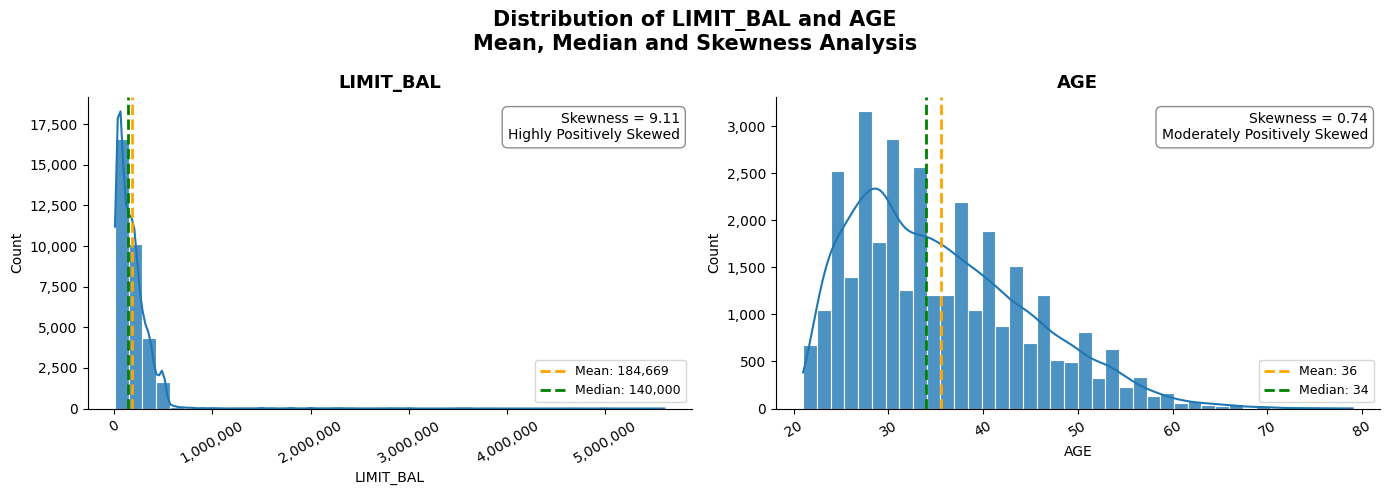

SKEWNESS SUMMARY
LIMIT_BAL: 9.114
AGE: 0.736


In [ ]:
# LIMIT_BAL and AGE with Mean, Median and Skewness

#import matplotlib.pyplot as plt
#import seaborn as sns
#from scipy.stats import skew

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ["LIMIT_BAL", "AGE"]):

    data = df[col].dropna()

    # Histogram + KDE
    sns.histplot(
        data,
        bins=40,
        kde=True,
        ax=ax,
        color="#1F77B4",
        edgecolor="white",
        alpha=0.8
    )

    # Mean and Median
    mean_val = data.mean()
    median_val = data.median()
    skew_val = data.skew()

    ax.axvline(
        mean_val,
        color="orange",
        linewidth=2,
        linestyle="--",
        label=f"Mean: {mean_val:,.0f}"
    )

    ax.axvline(
        median_val,
        color="green",
        linewidth=2,
        linestyle="--",
        label=f"Median: {median_val:,.0f}"
    )

    # Skewness interpretation
    if skew_val > 1:
        skew_text = "Highly Positively Skewed"
    elif skew_val > 0.5:
        skew_text = "Moderately Positively Skewed"
    elif skew_val > -0.5:
        skew_text = "Approximately Symmetric"
    elif skew_val > -1:
        skew_text = "Moderately Negatively Skewed"
    else:
        skew_text = "Highly Negatively Skewed"

    # Display skewness on chart
    ax.text(
        0.98,
        0.95,
        f"Skewness = {skew_val:.2f}\n{skew_text}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white",
            edgecolor="gray",
            alpha=0.9
        )
    )

    ax.set_title(col, fontweight="bold", fontsize=13)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

    ax.legend(fontsize=9)

    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{int(x):,}")
    )

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{int(y):,}")
    )

    ax.tick_params(axis="x", rotation=30)

plt.suptitle(
    "Distribution of LIMIT_BAL and AGE\nMean, Median and Skewness Analysis",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "fig_02_hist_limit_age_skewness.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# Print exact skewness values for report
print("=" * 50)
print("SKEWNESS SUMMARY")
print("=" * 50)

for col in ["LIMIT_BAL", "AGE"]:
    print(f"{col}: {df[col].dropna().skew():.3f}")

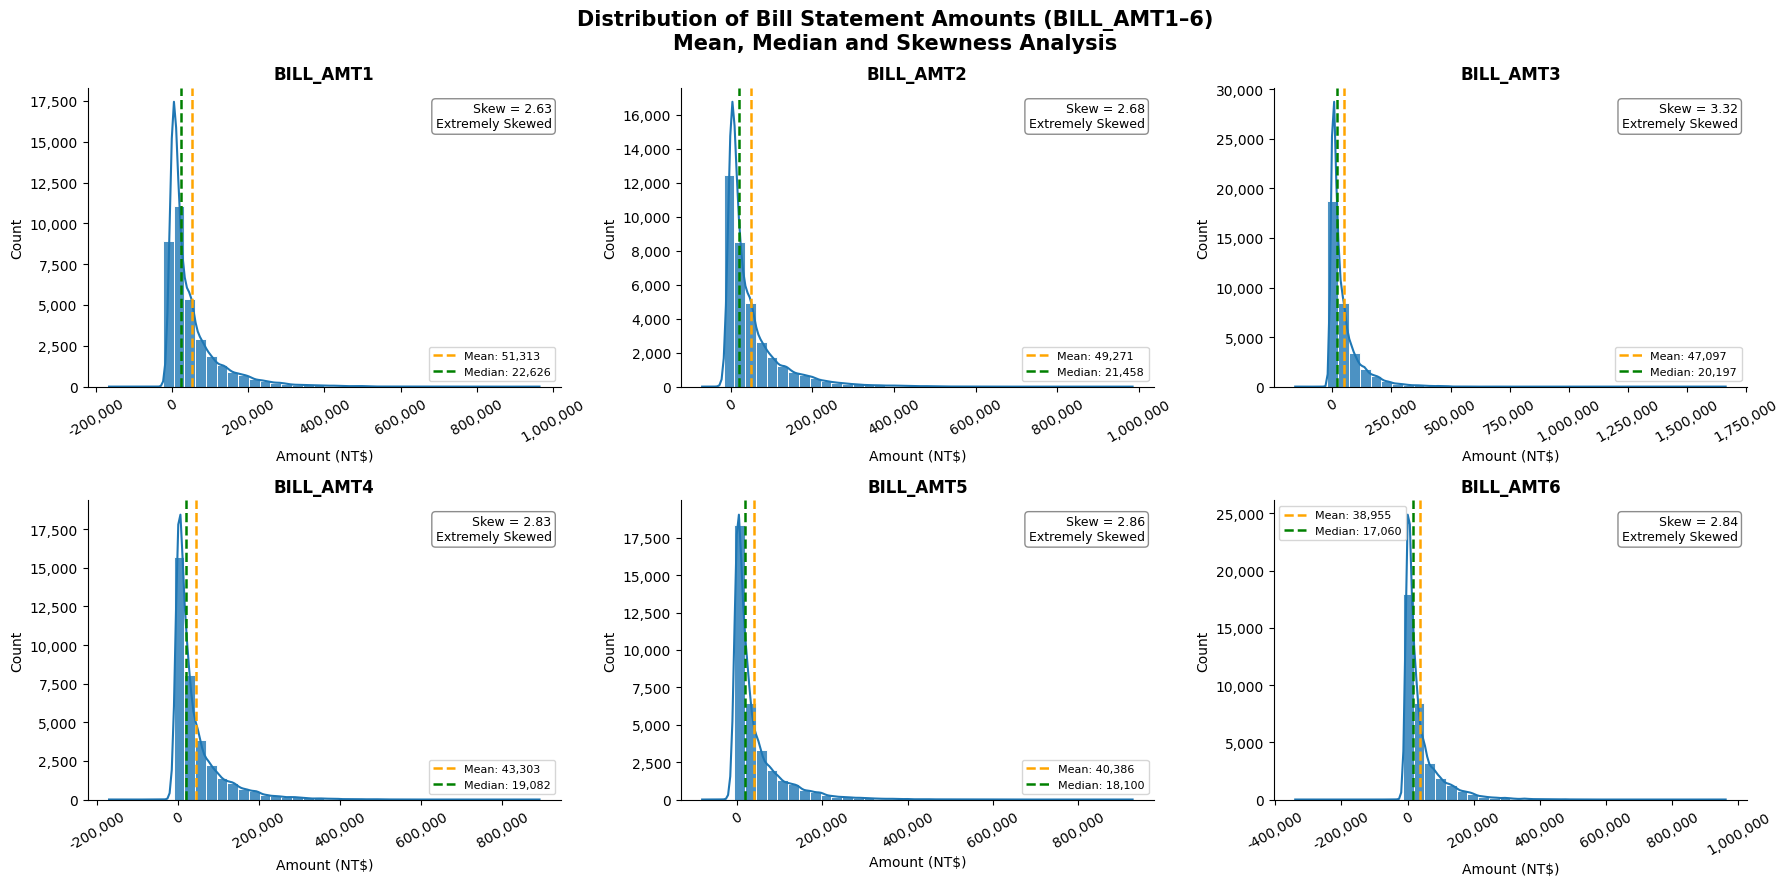

,Mean,Median,Std Dev,Skewness
BILL_AMT1,51312.9600,22626.0000,73407.5000,2.6300
BILL_AMT2,49271.1200,21458.5000,71090.4200,2.6800
BILL_AMT3,47096.5000,20197.0000,69731.1700,3.3200
BILL_AMT4,43303.1900,19082.0000,64404.0600,2.8300
BILL_AMT5,40385.6500,18100.5000,60833.2000,2.8600
BILL_AMT6,38955.1000,17060.0000,59629.9100,2.8400


In [ ]:
# BILL_AMT1–6 with Mean, Median and Skewness

bill_cols = ["BILL_AMT1","BILL_AMT2","BILL_AMT3",
             "BILL_AMT4","BILL_AMT5","BILL_AMT6"]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for ax, col in zip(axes.flatten(), bill_cols):

    data = df[col].dropna()

    sns.histplot(
        data,
        bins=40,
        kde=True,
        ax=ax,
        color="#1F77B4",
        edgecolor="white",
        alpha=0.8
    )

    mean_val = data.mean()
    median_val = data.median()
    skew_val = data.skew()

    # Mean and Median lines
    ax.axvline(
        mean_val,
        color="orange",
        linestyle="--",
        linewidth=1.8,
        label=f"Mean: {mean_val:,.0f}"
    )

    ax.axvline(
        median_val,
        color="green",
        linestyle="--",
        linewidth=1.8,
        label=f"Median: {median_val:,.0f}"
    )

    # Skewness interpretation
    if skew_val > 2:
        skew_text = "Extremely Skewed"
    elif skew_val > 1:
        skew_text = "Highly Skewed"
    elif skew_val > 0.5:
        skew_text = "Moderately Skewed"
    else:
        skew_text = "Approximately Symmetric"

    ax.text(
        0.98,
        0.95,
        f"Skew = {skew_val:.2f}\n{skew_text}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            edgecolor="gray",
            alpha=0.9
        )
    )

    ax.set_title(col, fontweight="bold", fontsize=12)
    ax.set_xlabel("Amount (NT$)")
    ax.set_ylabel("Count")

    ax.legend(fontsize=8)

    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{int(x):,}")
    )

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{int(y):,}")
    )

    ax.tick_params(axis="x", rotation=30)

plt.suptitle(
    "Distribution of Bill Statement Amounts (BILL_AMT1–6)\nMean, Median and Skewness Analysis",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "fig_03_hist_bill_amt_skewness.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# Summary table for report
bill_summary = pd.DataFrame({
    "Mean": [df[c].mean() for c in bill_cols],
    "Median": [df[c].median() for c in bill_cols],
    "Std Dev": [df[c].std() for c in bill_cols],
    "Skewness": [df[c].skew() for c in bill_cols]
}, index=bill_cols)

display(bill_summary.round(2))

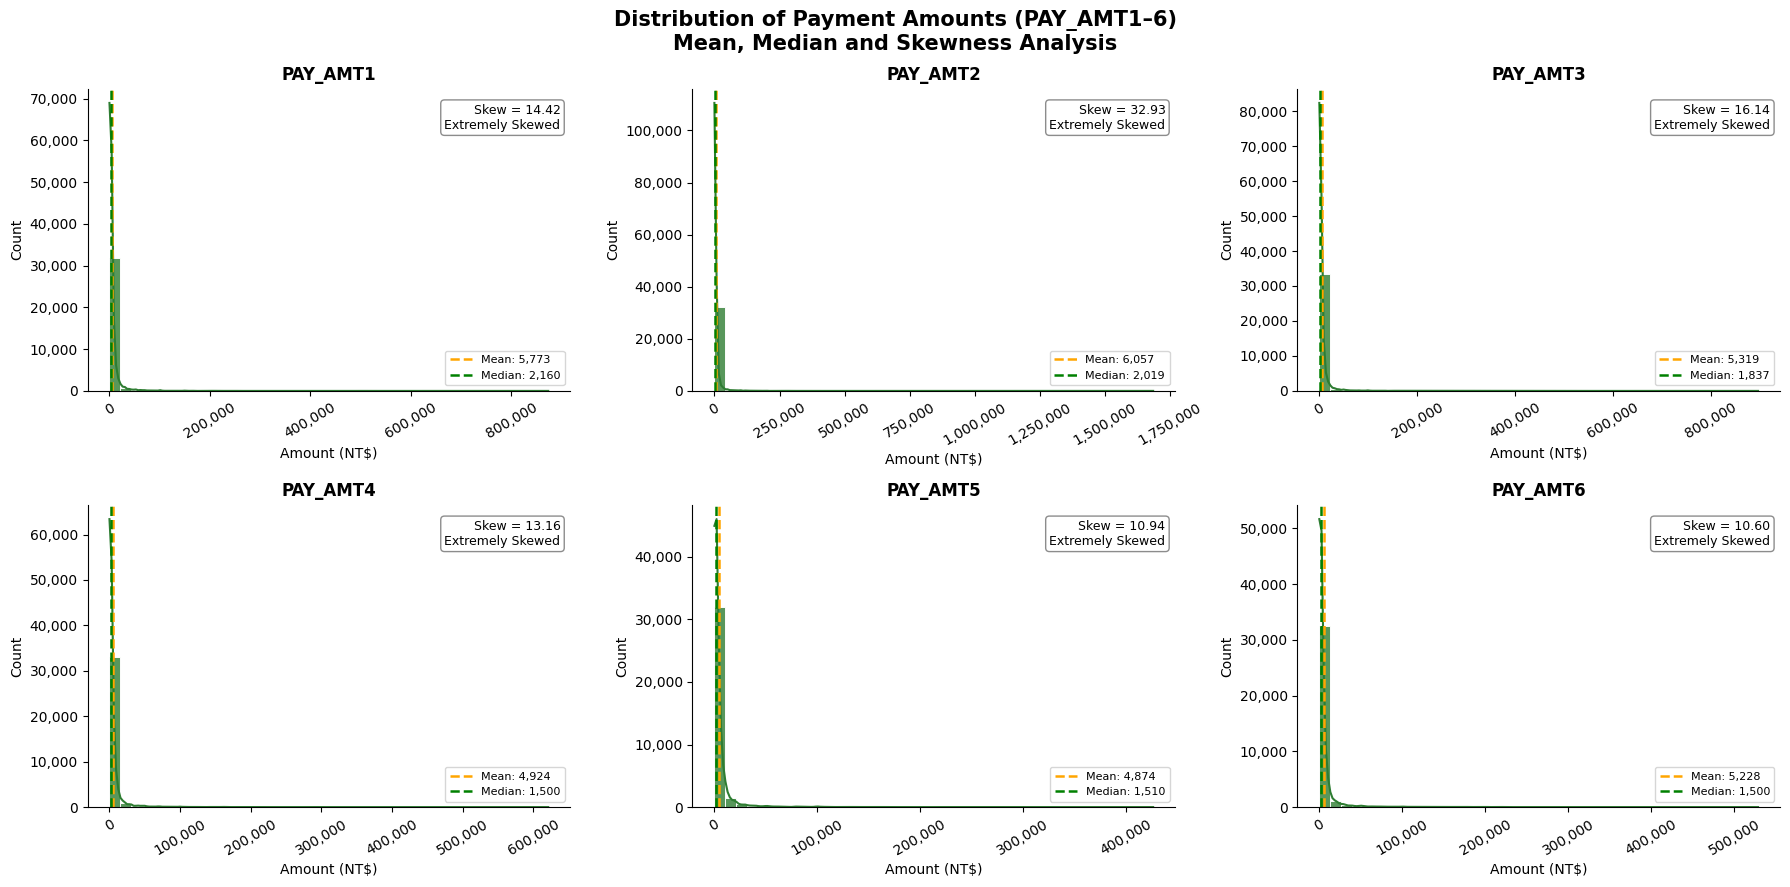

,Mean,Median,Std Dev,Skewness
PAY_AMT1,5772.8200,2160.0000,16917.8800,14.4200
PAY_AMT2,6057.3600,2019.0000,25557.7000,32.9300
PAY_AMT3,5318.6500,1837.0000,17854.7300,16.1400
PAY_AMT4,4923.7400,1500.0000,16316.7100,13.1600
PAY_AMT5,4873.6600,1510.0000,15436.3300,10.9400
PAY_AMT6,5227.8200,1500.0000,17626.7900,10.6000


In [ ]:
# PAY_AMT1–6 with Mean, Median and Skewness

pay_amt_cols = ["PAY_AMT1","PAY_AMT2","PAY_AMT3",
                "PAY_AMT4","PAY_AMT5","PAY_AMT6"]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for ax, col in zip(axes.flatten(), pay_amt_cols):

    data = df[col].dropna()

    sns.histplot(
        data,
        bins=40,
        kde=True,
        ax=ax,
        color="#2E7D32",
        edgecolor="white",
        alpha=0.8
    )

    mean_val = data.mean()
    median_val = data.median()
    skew_val = data.skew()

    # Mean and Median
    ax.axvline(
        mean_val,
        color="orange",
        linestyle="--",
        linewidth=1.8,
        label=f"Mean: {mean_val:,.0f}"
    )

    ax.axvline(
        median_val,
        color="green",
        linestyle="--",
        linewidth=1.8,
        label=f"Median: {median_val:,.0f}"
    )

    # Skewness label
    if skew_val > 2:
        skew_text = "Extremely Skewed"
    elif skew_val > 1:
        skew_text = "Highly Skewed"
    elif skew_val > 0.5:
        skew_text = "Moderately Skewed"
    else:
        skew_text = "Approximately Symmetric"

    ax.text(
        0.98,
        0.95,
        f"Skew = {skew_val:.2f}\n{skew_text}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            edgecolor="gray",
            alpha=0.9
        )
    )

    ax.set_title(col, fontweight="bold", fontsize=12)
    ax.set_xlabel("Amount (NT$)")
    ax.set_ylabel("Count")

    ax.legend(
        fontsize=8,
        loc="lower right"
    )

    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{int(x):,}")
    )

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{int(y):,}")
    )

    ax.tick_params(axis="x", rotation=30)

plt.suptitle(
    "Distribution of Payment Amounts (PAY_AMT1–6)\nMean, Median and Skewness Analysis",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "fig_04_hist_pay_amt_skewness.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# Summary statistics table
pay_amt_summary = pd.DataFrame({
    "Mean": [df[c].mean() for c in pay_amt_cols],
    "Median": [df[c].median() for c in pay_amt_cols],
    "Std Dev": [df[c].std() for c in pay_amt_cols],
    "Skewness": [df[c].skew() for c in pay_amt_cols]
}, index=pay_amt_cols)

display(pay_amt_summary.round(2))

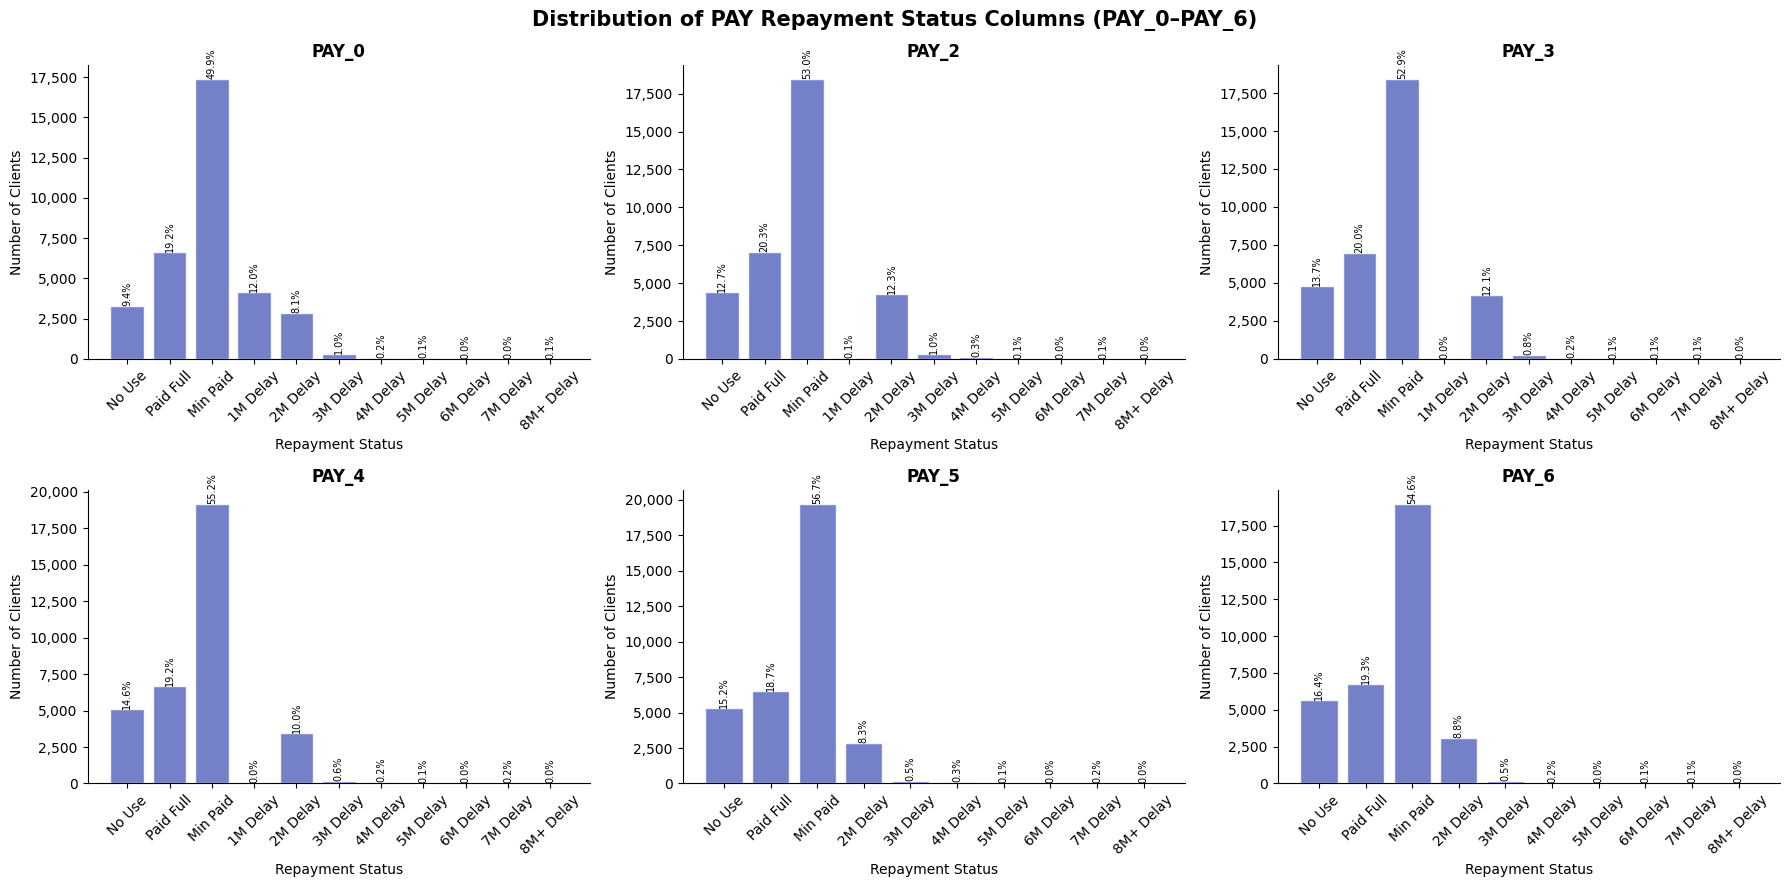

In [ ]:
# PAY_0 to PAY_6 (ordinal repayment status codes)

pay_status_cols = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]

pay_labels = {
    -2: "No Use",
    -1: "Paid Full",
     0: "Min Paid",
     1: "1M Delay",
     2: "2M Delay",
     3: "3M Delay",
     4: "4M Delay",
     5: "5M Delay",
     6: "6M Delay",
     7: "7M Delay",
     8: "8M+ Delay"
}

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for ax, col in zip(axes.flatten(), pay_status_cols):

    counts_p = df[col].value_counts().sort_index()
    total = counts_p.sum()

    labels = [pay_labels.get(x, str(x))
              for x in counts_p.index]

    bars = ax.bar(
        labels,
        counts_p.values,
        color="#5C6BC0",
        alpha=0.85,
        edgecolor="white"
    )

    # Add percentages above bars
    for bar, value in zip(bars, counts_p.values):

        pct = (value / total) * 100

        ax.text(
            bar.get_x() + bar.get_width()/2,
            value,
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

    ax.set_title(col, fontweight="bold", fontsize=12)
    ax.set_xlabel("Repayment Status")
    ax.set_ylabel("Number of Clients")

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{int(y):,}")
    )

    ax.tick_params(axis="x", rotation=45)

plt.suptitle(
    "Distribution of PAY Repayment Status Columns (PAY_0–PAY_6)",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "fig_05_pay_status_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

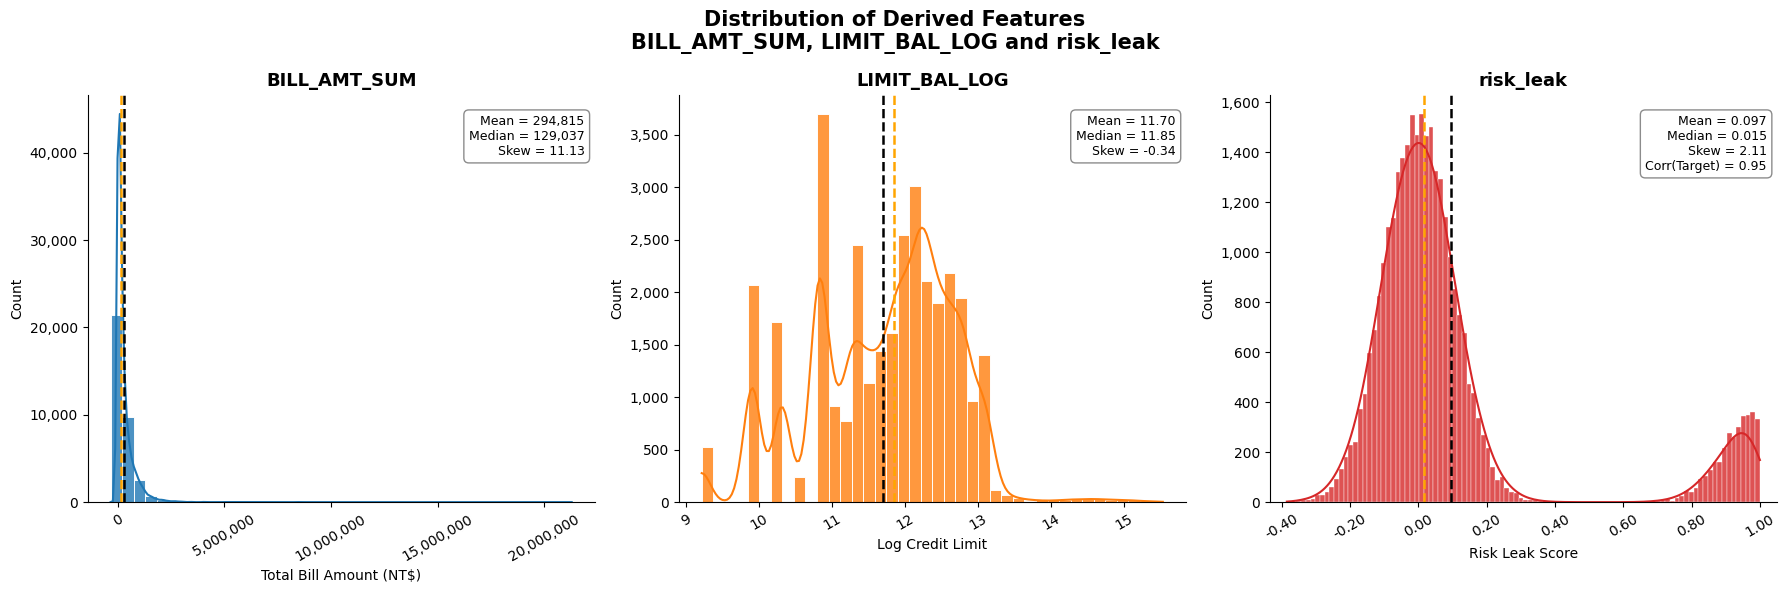

,Mean,Median,Std Dev,Skewness,Correlation with Target
BILL_AMT_SUM,294815.1710,129037.0000,571807.2520,11.1260,-0.0100
LIMIT_BAL_LOG,11.6980,11.8490,0.9670,-0.3380,-0.1610
risk_leak,0.0970,0.0150,0.2990,2.1100,0.9450


In [ ]:
# BILL_AMT_SUM, LIMIT_BAL_LOG, risk_leak
# Mean, Median, Skewness and Leakage Analysis

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

derived_cols = ["BILL_AMT_SUM", "LIMIT_BAL_LOG", "risk_leak"]

plot_settings = {
    "BILL_AMT_SUM": {
        "color": "#1F77B4",
        "bins": 40,
        "xlabel": "Total Bill Amount (NT$)",
        "mean_format": "{:,.0f}",
        "median_format": "{:,.0f}"
    },
    "LIMIT_BAL_LOG": {
        "color": "#FF7F0E",
        "bins": 40,
        "xlabel": "Log Credit Limit",
        "mean_format": "{:.2f}",
        "median_format": "{:.2f}"
    },
    "risk_leak": {
        "color": "#D62728",
        "bins": 100,
        "xlabel": "Risk Leak Score",
        "mean_format": "{:.3f}",
        "median_format": "{:.3f}"
    }
}

for ax, col in zip(axes, derived_cols):

    data = df[col].dropna()

    mean_val = data.mean()
    median_val = data.median()
    skew_val = data.skew()

    sns.histplot(
        data,
        bins=plot_settings[col]["bins"],
        kde=True,
        ax=ax,
        color=plot_settings[col]["color"],
        edgecolor="white",
        alpha=0.8
    )

    # Mean and median lines WITHOUT legend labels
    ax.axvline(
        mean_val,
        color="black",
        linewidth=1.8,
        linestyle="--"
    )

    ax.axvline(
        median_val,
        color="orange",
        linewidth=1.8,
        linestyle="--"
    )

    mean_text = plot_settings[col]["mean_format"].format(mean_val)
    median_text = plot_settings[col]["median_format"].format(median_val)

    # Extra correlation text for risk_leak
    if col == "risk_leak":
        corr_target = df["risk_leak"].corr(df["default.payment.next.month"])
        annotation = (
            f"Mean = {mean_text}\n"
            f"Median = {median_text}\n"
            f"Skew = {skew_val:.2f}\n"
            f"Corr(Target) = {corr_target:.2f}"
        )

        ax.set_xlim(
            data.min() - 0.05,
            data.max() + 0.05
        )

        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"{x:.2f}")
        )

    else:
        annotation = (
            f"Mean = {mean_text}\n"
            f"Median = {median_text}\n"
            f"Skew = {skew_val:.2f}"
        )

        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"{int(x):,}")
        )

    # Annotation box
    ax.text(
        0.98,
        0.95,
        annotation,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white",
            edgecolor="gray",
            alpha=0.9
        )
    )

    # Titles and labels
    ax.set_title(col, fontweight="bold", fontsize=13)
    ax.set_xlabel(plot_settings[col]["xlabel"])
    ax.set_ylabel("Count")

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{int(y):,}")
    )

    ax.tick_params(axis="x", rotation=30)

plt.suptitle(
    "Distribution of Derived Features\n"
    "BILL_AMT_SUM, LIMIT_BAL_LOG and risk_leak",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "fig_06_derived_features_analysis.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# Summary table for report
derived_summary = pd.DataFrame({
    "Mean": [
        df["BILL_AMT_SUM"].mean(),
        df["LIMIT_BAL_LOG"].mean(),
        df["risk_leak"].mean()
    ],
    "Median": [
        df["BILL_AMT_SUM"].median(),
        df["LIMIT_BAL_LOG"].median(),
        df["risk_leak"].median()
    ],
    "Std Dev": [
        df["BILL_AMT_SUM"].std(),
        df["LIMIT_BAL_LOG"].std(),
        df["risk_leak"].std()
    ],
    "Skewness": [
        df["BILL_AMT_SUM"].skew(),
        df["LIMIT_BAL_LOG"].skew(),
        df["risk_leak"].skew()
    ],
    "Correlation with Target": [
        df["BILL_AMT_SUM"].corr(df["default.payment.next.month"]),
        df["LIMIT_BAL_LOG"].corr(df["default.payment.next.month"]),
        df["risk_leak"].corr(df["default.payment.next.month"])
    ]
}, index=["BILL_AMT_SUM", "LIMIT_BAL_LOG", "risk_leak"])

display(derived_summary.round(3))

## <b><span style='color:#ff826e'>Task 1.5 |</span><span style='color:red'> Univariate Analysis — Categorical Features</span></b>

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
Bar charts show the frequency distribution of each categorical feature — how many clients fall into each category. This covers all categorical features: SEX, EDUCATION, MARRIAGE, CITY, and RISK_RATING.
</div>

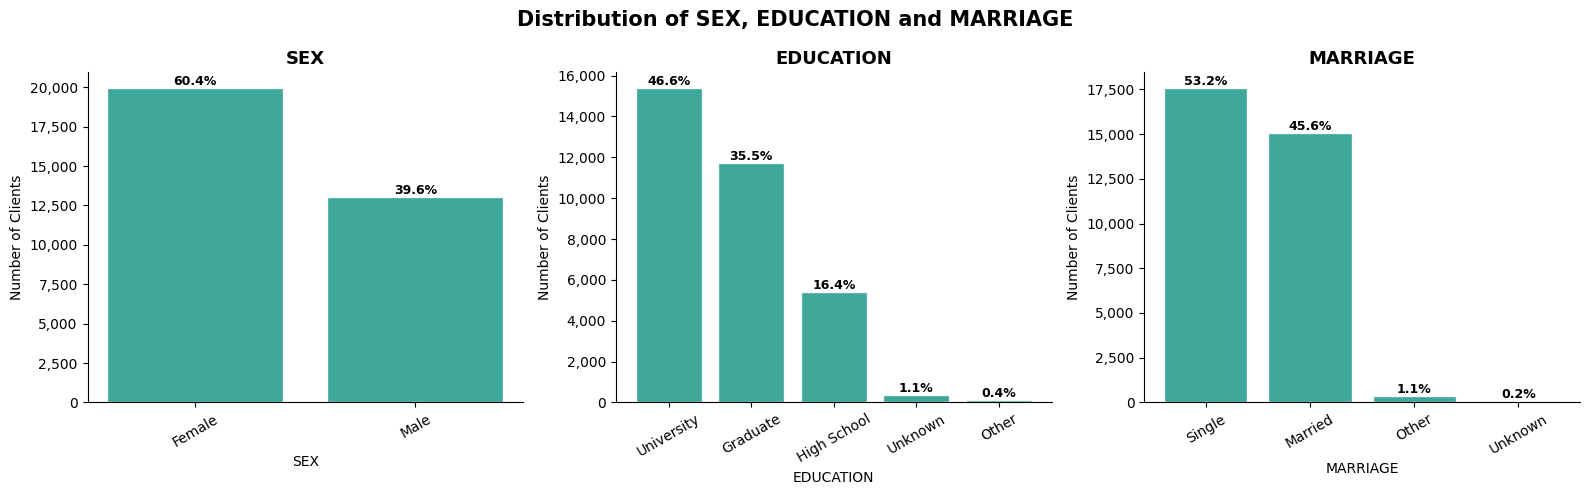

In [ ]:
# SEX, EDUCATION, MARRIAGE
# Clean categorical distribution plots

labels_map = {
    "SEX": {
        1.0: "Male",
        2.0: "Female"
    },
    "EDUCATION": {
        1.0: "Graduate",
        2.0: "University",
        3.0: "High School",
        4.0: "Other",
        0.0: "Unknown",
        5.0: "Unknown",
        6.0: "Unknown"
    },
    "MARRIAGE": {
        1.0: "Married",
        2.0: "Single",
        3.0: "Other",
        0.0: "Unknown"
    }
}

bar_color = "#2A9D8F"   # Deep Teal

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ["SEX", "EDUCATION", "MARRIAGE"]):

    # Replace codes with labels first
    temp = df[col].replace(labels_map[col])

    counts = temp.value_counts()
    total = counts.sum()

    bars = ax.bar(
        counts.index,
        counts.values,
        color=bar_color,
        alpha=0.9,
        edgecolor="white",
        linewidth=1
    )

    # Add percentages above bars
    for bar, value in zip(bars, counts.values):

        pct = (value / total) * 100

        ax.text(
            bar.get_x() + bar.get_width()/2,
            value,
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

    ax.set_title(
        col,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(col)
    ax.set_ylabel("Number of Clients")

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{int(y):,}")
    )

    ax.tick_params(
        axis="x",
        rotation=30
    )

plt.suptitle(
    "Distribution of SEX, EDUCATION and MARRIAGE",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "fig_07_cat_sem.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

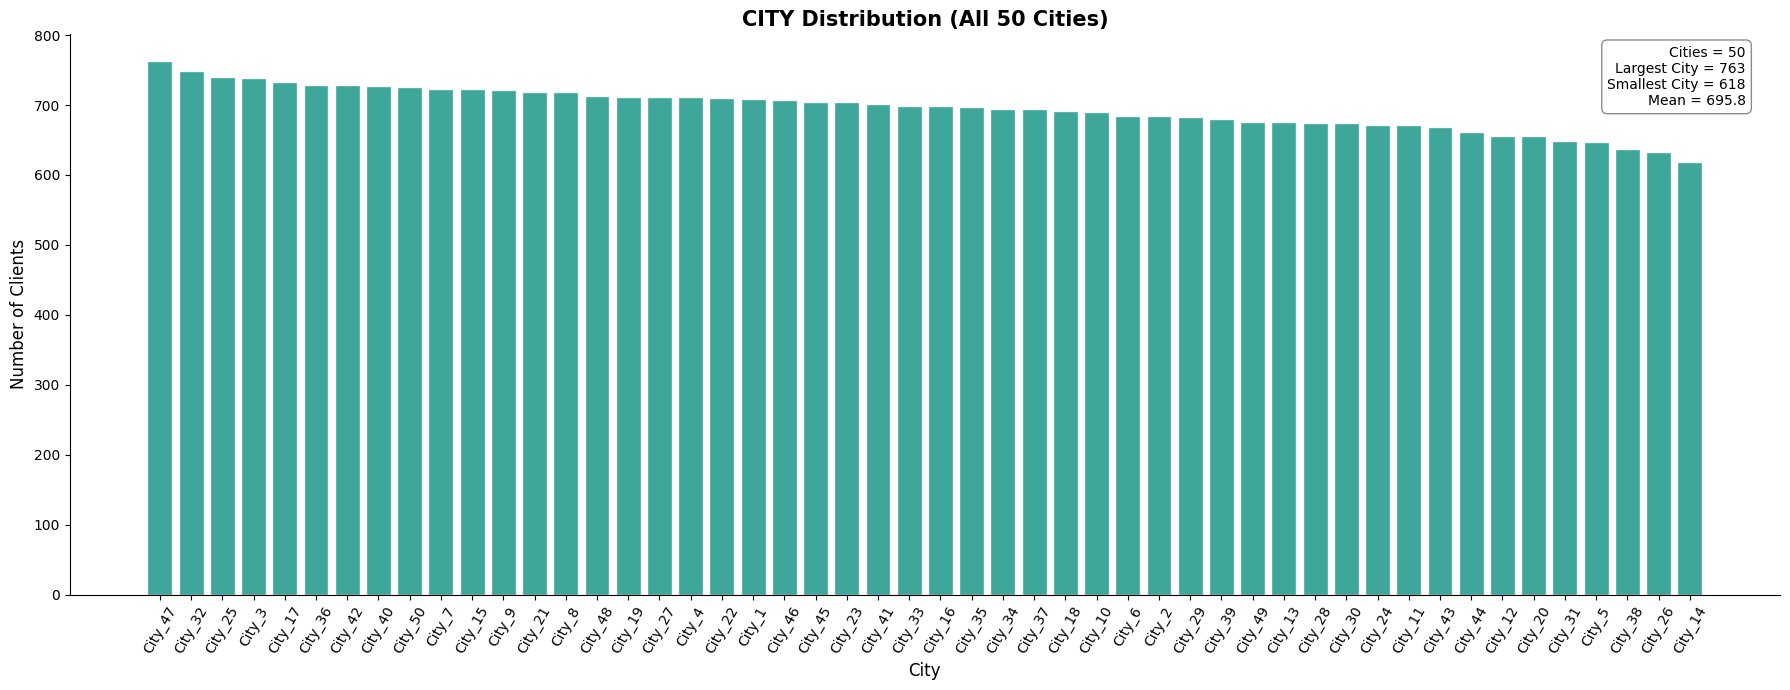

,Metric,Value
0,Number of Cities,50.0000
1,Largest City Count,763.0000
2,Smallest City Count,618.0000
3,Average Clients per City,695.8000
4,Median Clients per City,699.0000
5,Standard Deviation,31.3000


In [ ]:
# CITY — Full Distribution (All 50 Cities)

city_counts = df["CITY"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(18, 7))

bars = ax.bar(
    city_counts.index,
    city_counts.values,
    color="#2A9D8F",
    alpha=0.9,
    edgecolor="white",
    linewidth=1
)

ax.set_title(
    f"CITY Distribution (All {city_counts.shape[0]} Cities)",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("City", fontsize=12)
ax.set_ylabel("Number of Clients", fontsize=12)

# Format y-axis with commas
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{int(y):,}")
)

# Rotate city labels
ax.tick_params(
    axis="x",
    rotation=60
)

# Summary statistics box
ax.text(
    0.98,
    0.98,
    f"Cities = {city_counts.shape[0]}\n"
    f"Largest City = {city_counts.max():,}\n"
    f"Smallest City = {city_counts.min():,}\n"
    f"Mean = {city_counts.mean():.1f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)

plt.tight_layout()

plt.savefig(
    "fig_08_city_distribution_all_cities.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# Summary table for report
city_summary = pd.DataFrame({
    "Metric": [
        "Number of Cities",
        "Largest City Count",
        "Smallest City Count",
        "Average Clients per City",
        "Median Clients per City",
        "Standard Deviation"
    ],
    "Value": [
        city_counts.shape[0],
        city_counts.max(),
        city_counts.min(),
        round(city_counts.mean(), 1),
        round(city_counts.median(), 1),
        round(city_counts.std(), 1)
    ]
})

display(city_summary)

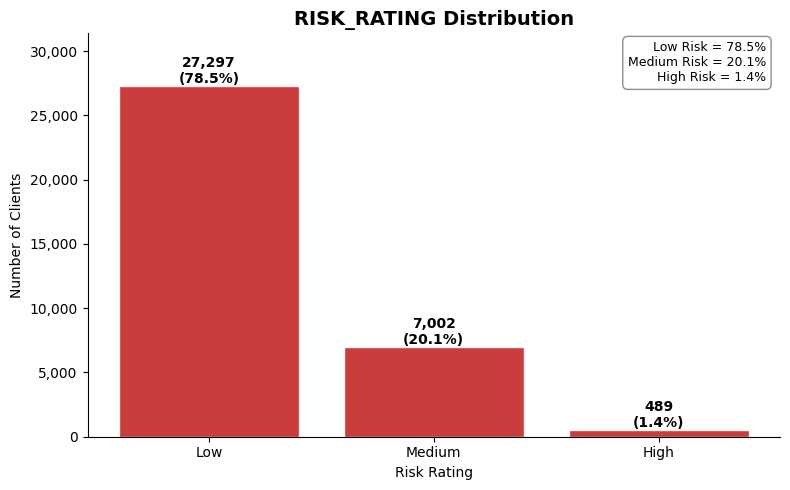

In [ ]:
# RISK_RATING

rr_counts = df["RISK_RATING"].value_counts().sort_index()
total = rr_counts.sum()

risk_labels = {
    1: "Low",
    2: "Medium",
    3: "High"
}

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    [risk_labels.get(x, str(x)) for x in rr_counts.index],
    rr_counts.values,
    color="#C62828",
    alpha=0.9,
    edgecolor="white",
    linewidth=1
)

# Count + Percentage labels
for bar, value in zip(bars, rr_counts.values):

    pct = (value / total) * 100

    ax.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{value:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "RISK_RATING Distribution",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Risk Rating")
ax.set_ylabel("Number of Clients")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{int(y):,}")
)

# Give labels room
ax.set_ylim(0, rr_counts.max() * 1.15)

# Summary box
ax.text(
    0.98,
    0.98,
    f"Low Risk = {(rr_counts[1]/total)*100:.1f}%\n"
    f"Medium Risk = {(rr_counts[2]/total)*100:.1f}%\n"
    f"High Risk = {(rr_counts[3]/total)*100:.1f}%",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)

plt.tight_layout()

plt.savefig(
    "fig_09_cat_risk_rating.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## <b><span style='color:#ff826e'>Task 1.6 |</span><span style='color:red'> Outlier Detection — IQR Method and Box Plots</span></b>

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
<b>IQR Rule</b>: Values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are flagged as outliers.
<br><br>
Box plots here are <b>univariate</b> — they show the spread, median, and outlier extent of each feature on its own. Outliers in this dataset represent genuine high-value clients — not data errors. Removing them would introduce selection bias. <b>Winsorization</b> (capping at 1st/99th percentile inside the Pipeline) is the chosen approach, applied on training data only.
</div>

In [ ]:
all_continuous = ["LIMIT_BAL","AGE",
                   "BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6",
                   "PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6",
                   "BILL_AMT_SUM","LIMIT_BAL_LOG","risk_leak"]

Q1  = df[all_continuous].quantile(0.25)
Q3  = df[all_continuous].quantile(0.75)
IQR = Q3 - Q1
outlier_counts = ((df[all_continuous] < (Q1 - 1.5*IQR)) |
                  (df[all_continuous] > (Q3 + 1.5*IQR))).sum()

print("=== OUTLIER COUNTS (IQR METHOD) ===")
display(outlier_counts.to_frame("Outlier Count").T)

=== OUTLIER COUNTS (IQR METHOD) ===


,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,BILL_AMT_SUM,LIMIT_BAL_LOG,risk_leak
Outlier Count,475,312,2768,2794,2854,3011,3141,3100,3060,3041,3014,3468,3457,3468,3061,131,3363


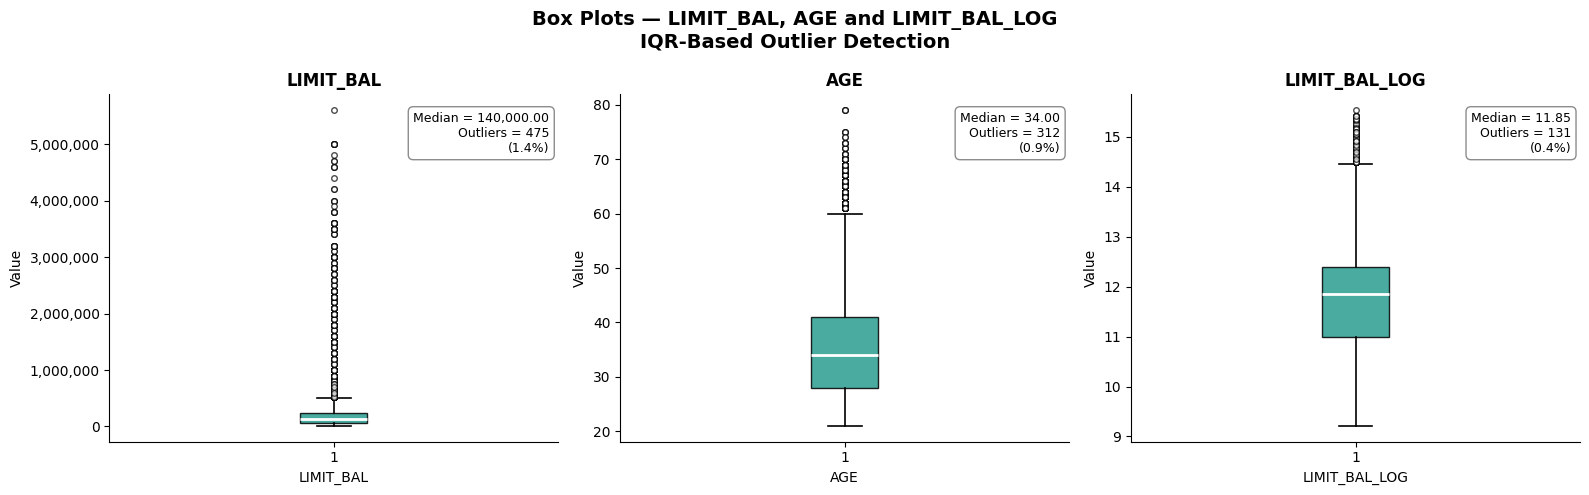

In [ ]:
# Box plots — LIMIT_BAL, AGE, LIMIT_BAL_LOG
# Improved with IQR outlier counts and percentage labels

box_cols = ["LIMIT_BAL", "AGE", "LIMIT_BAL_LOG"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, box_cols):

    data = df[col].dropna()

    # IQR outlier calculation
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = ((data < lower_bound) | (data > upper_bound)).sum()
    outlier_pct = (outlier_count / len(data)) * 100

    median_val = data.median()

    ax.boxplot(
        data,
        patch_artist=True,
        medianprops=dict(color="white", linewidth=2),
        boxprops=dict(facecolor="#2A9D8F", alpha=0.85),
        whiskerprops=dict(color="black", linewidth=1.2),
        capprops=dict(color="black", linewidth=1.2),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=4,
            alpha=0.7
        )
    )

    ax.set_title(
        col,
        fontweight="bold",
        fontsize=12
    )

    ax.set_ylabel("Value")
    ax.set_xlabel(col)

    # Summary annotation
    ax.text(
        0.98,
        0.95,
        f"Median = {median_val:,.2f}\n"
        f"Outliers = {outlier_count:,}\n"
        f"({outlier_pct:.1f}%)",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white",
            edgecolor="gray",
            alpha=0.9
        )
    )

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{y:,.0f}")
    )

plt.suptitle(
    "Box Plots — LIMIT_BAL, AGE and LIMIT_BAL_LOG\nIQR-Based Outlier Detection",
    fontweight="bold",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "fig_10a_box_limit_age.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

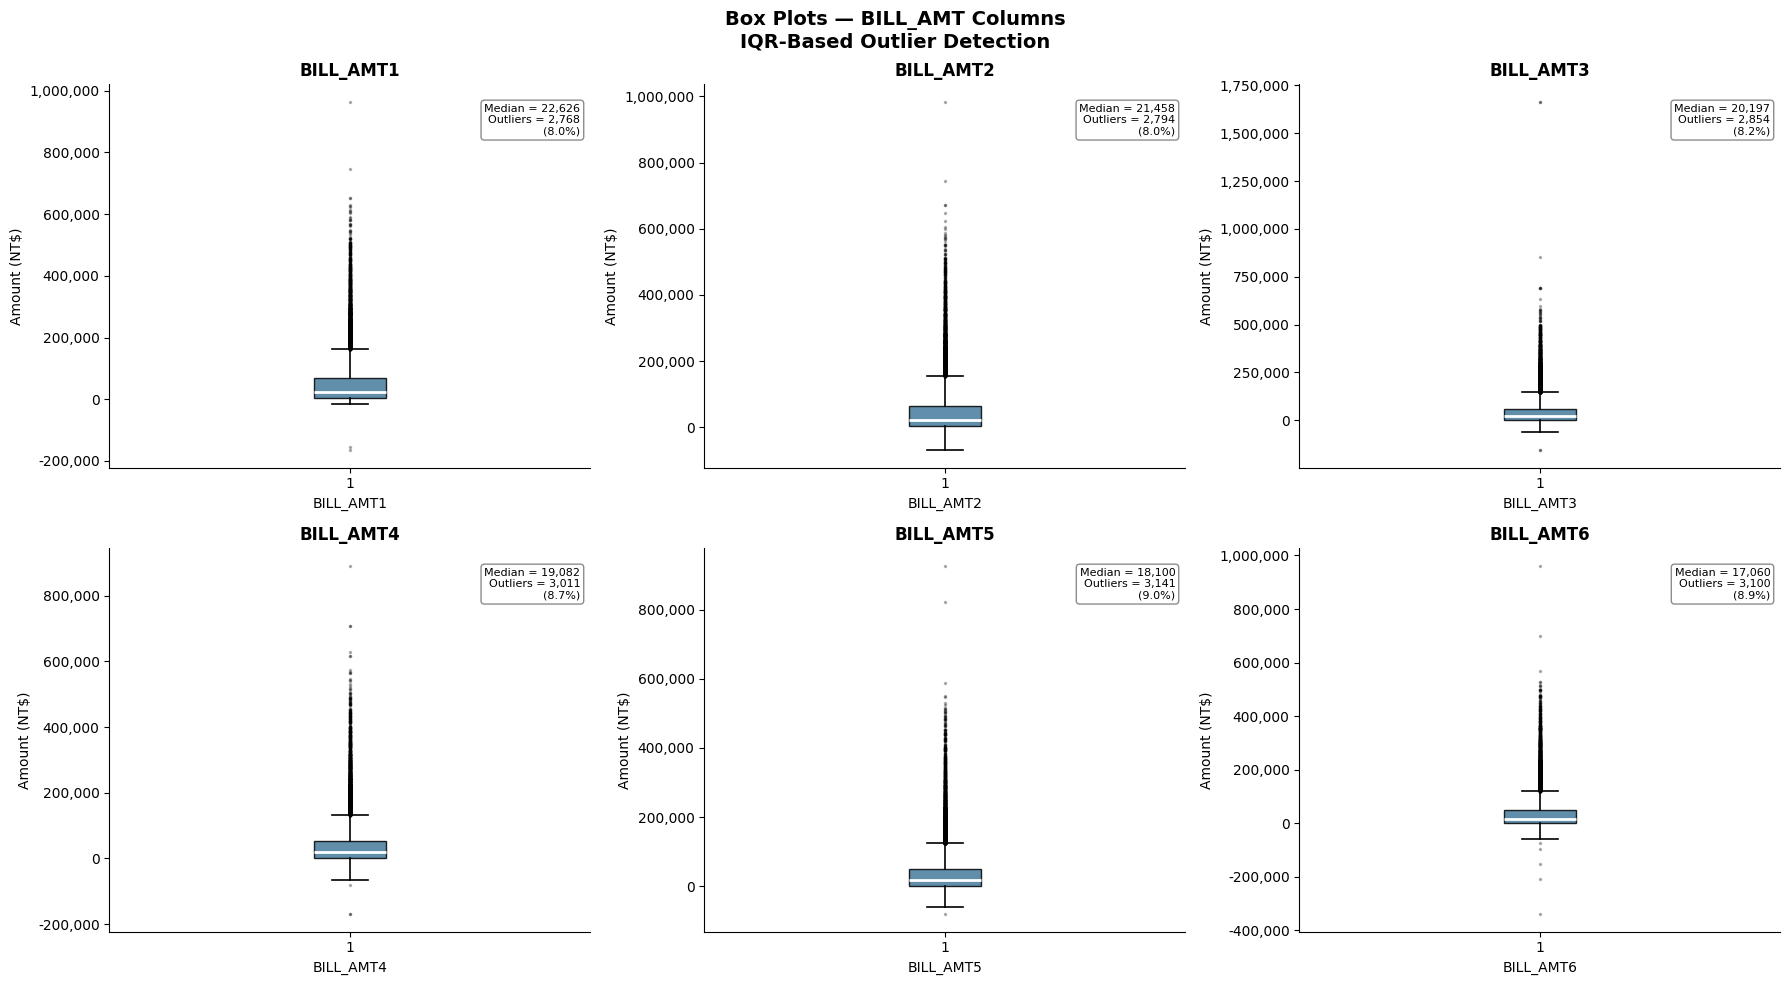

In [ ]:
# Box Plots — BILL_AMT1–6
# IQR-Based Outlier Detection (SHOWING OUTLIERS)

bill_cols = [
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), bill_cols):

    data = df[col].dropna()

    # IQR calculations
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        ((data < lower_bound) | (data > upper_bound))
        .sum()
    )

    outlier_pct = (
        outlier_count / len(data)
    ) * 100

    median_val = data.median()

    ax.boxplot(
        data,
        patch_artist=True,
        showfliers=True,
        medianprops=dict(
            color="white",
            linewidth=2
        ),
        boxprops=dict(
            facecolor="#457B9D",
            alpha=0.85
        ),
        whiskerprops=dict(
            color="black",
            linewidth=1.2
        ),
        capprops=dict(
            color="black",
            linewidth=1.2
        ),
        flierprops=dict(
            marker="o",
            markerfacecolor="black",
            markeredgecolor="black",
            markersize=1.5,
            alpha=0.25
        )
    )

    ax.set_title(
        col,
        fontweight="bold",
        fontsize=12
    )

    ax.set_ylabel("Amount (NT$)")
    ax.set_xlabel(col)

    ax.text(
        0.98,
        0.95,
        f"Median = {median_val:,.0f}\n"
        f"Outliers = {outlier_count:,}\n"
        f"({outlier_pct:.1f}%)",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            edgecolor="gray",
            alpha=0.9
        )
    )

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda y, _: f"{y:,.0f}"
        )
    )

plt.suptitle(
    "Box Plots — BILL_AMT Columns\n"
    "IQR-Based Outlier Detection",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "fig_10b_box_bill_amt.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

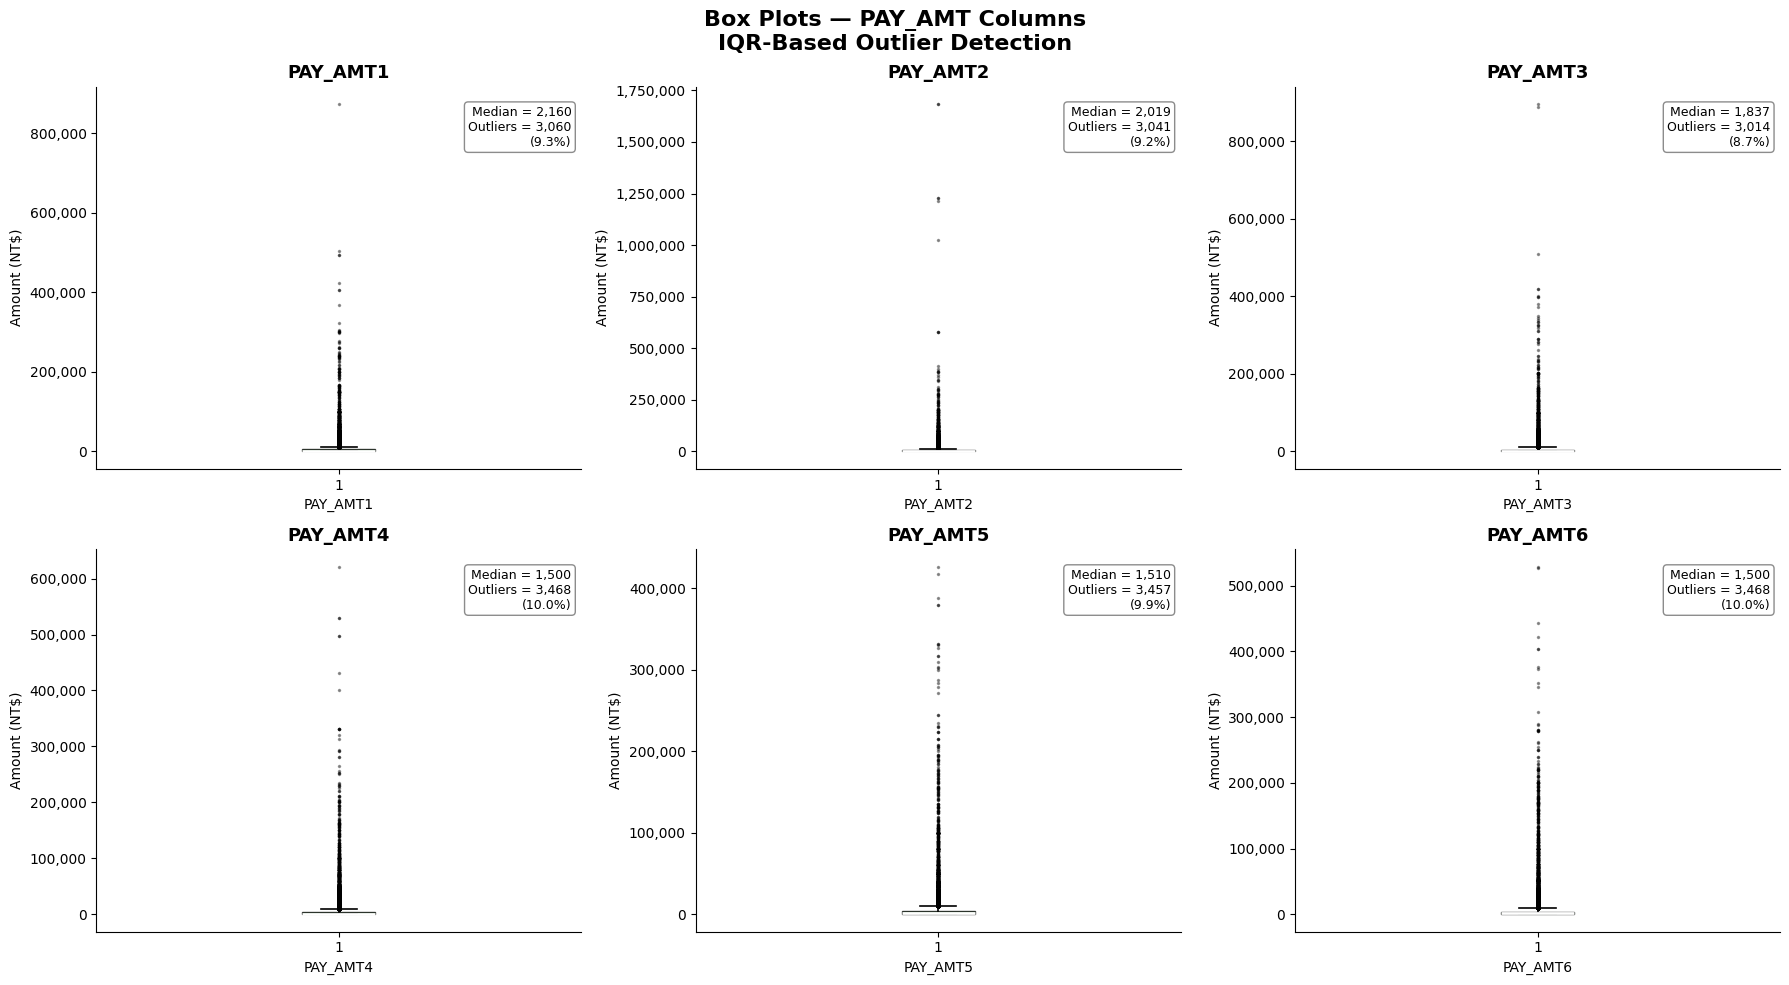

In [ ]:
# ==========================================
# Box Plots — PAY_AMT1–PAY_AMT6
# IQR-Based Outlier Detection
# ==========================================

pay_cols = [
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), pay_cols):

    data = df[col].dropna()

    # IQR outlier count
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    outliers = (
        (data < (Q1 - 1.5 * IQR)) |
        (data > (Q3 + 1.5 * IQR))
    ).sum()

    outlier_pct = (outliers / len(data)) * 100

    median_val = data.median()

    ax.boxplot(
        data,
        patch_artist=True,
        showfliers=True,
        medianprops=dict(color="white", linewidth=2),
        boxprops=dict(
            facecolor="#2E7D32",
            alpha=0.75
        ),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(
            marker='o',
            markersize=1.5,
            markerfacecolor='black',
            markeredgecolor='black',
            alpha=0.35
        )
    )

    ax.set_title(
        col,
        fontweight="bold",
        fontsize=13
    )

    ax.set_ylabel("Amount (NT$)")
    ax.set_xlabel(col)

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda y, _: f"{int(y):,}"
        )
    )

    # Summary box
    ax.text(
        0.98,
        0.95,
        f"Median = {median_val:,.0f}\n"
        f"Outliers = {outliers:,}\n"
        f"({outlier_pct:.1f}%)",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            edgecolor="gray",
            alpha=0.9
        )
    )

plt.suptitle(
    "Box Plots — PAY_AMT Columns\n"
    "IQR-Based Outlier Detection",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "fig_10c_box_pay_amt_improved.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

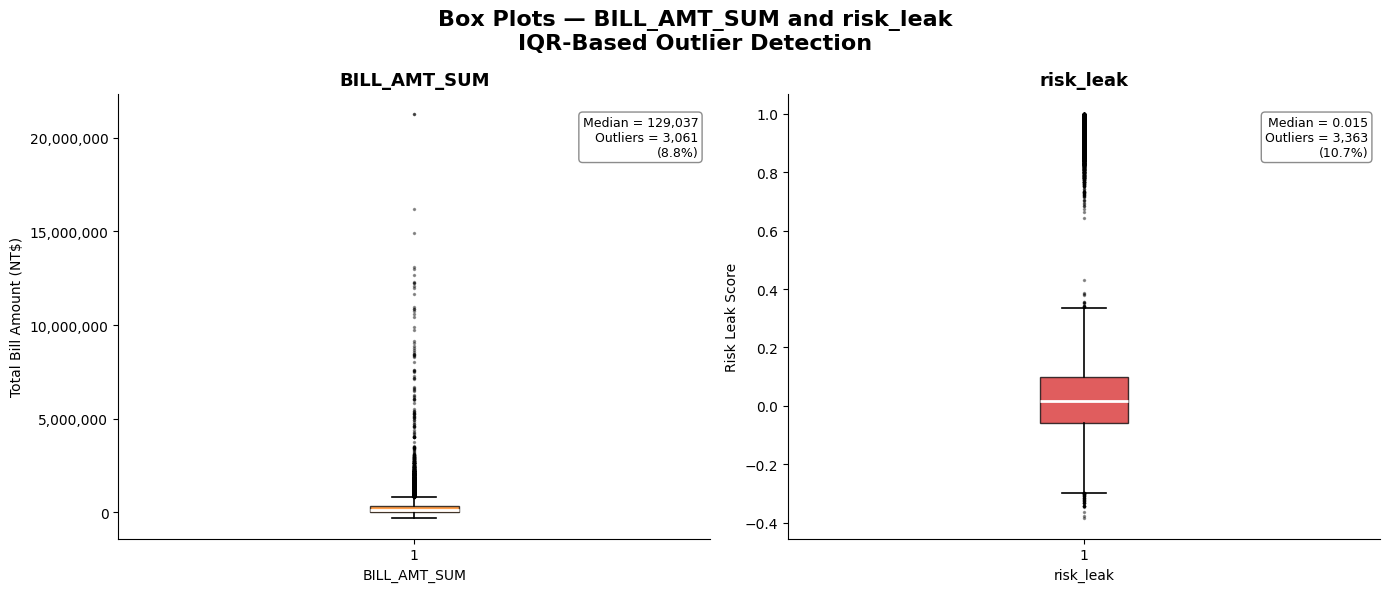

In [ ]:
# ==========================================
# Box Plots — BILL_AMT_SUM and risk_leak
# IQR-Based Outlier Detection
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

configs = [
    ("BILL_AMT_SUM", "#FF7F0E", "Total Bill Amount (NT$)"),
    ("risk_leak", "#D62728", "Risk Leak Score")
]

for ax, (col, color, ylabel) in zip(axes, configs):

    data = df[col].dropna()

    # IQR calculations
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    outliers = (
        (data < (Q1 - 1.5 * IQR)) |
        (data > (Q3 + 1.5 * IQR))
    ).sum()

    outlier_pct = (outliers / len(data)) * 100
    median_val = data.median()

    ax.boxplot(
        data,
        patch_artist=True,
        showfliers=True,
        medianprops=dict(
            color="white",
            linewidth=2
        ),
        boxprops=dict(
            facecolor=color,
            alpha=0.75
        ),
        whiskerprops=dict(
            linewidth=1.2
        ),
        capprops=dict(
            linewidth=1.2
        ),
        flierprops=dict(
            marker='o',
            markersize=1.5,
            markerfacecolor='black',
            markeredgecolor='black',
            alpha=0.35
        )
    )

    ax.set_title(
        col,
        fontweight="bold",
        fontsize=13
    )

    ax.set_ylabel(ylabel)
    ax.set_xlabel(col)

    # Number formatting
    if col == "BILL_AMT_SUM":
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(
                lambda y, _: f"{int(y):,}"
            )
        )

    # Annotation box
    if col == "BILL_AMT_SUM":
        text = (
            f"Median = {median_val:,.0f}\n"
            f"Outliers = {outliers:,}\n"
            f"({outlier_pct:.1f}%)"
        )
    else:
        text = (
            f"Median = {median_val:.3f}\n"
            f"Outliers = {outliers:,}\n"
            f"({outlier_pct:.1f}%)"
        )

    ax.text(
        0.98,
        0.95,
        text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            edgecolor="gray",
            alpha=0.9
        )
    )

plt.suptitle(
    "Box Plots — BILL_AMT_SUM and risk_leak\n"
    "IQR-Based Outlier Detection",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "fig_10d_box_derived_improved.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## <b><span style='color:#ff826e'>Task 1.7 |</span><span style='color:red'> Bivariate Analysis — Numerical Features vs Target</span></b>

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
We visualise each continuous feature against the target using two chart types side by side:
<ul>
<li><b>Bar plot</b> — mean value per class, to compare central tendency between defaulters and non-defaulters.</li>
<li><b>KDE plot</b> — full distribution per class, to reveal overlap, separation, and distributional shape differences.</li>
</ul>
This covers all continuous features including BILL_AMT_SUM, LIMIT_BAL_LOG, and risk_leak.
</div>

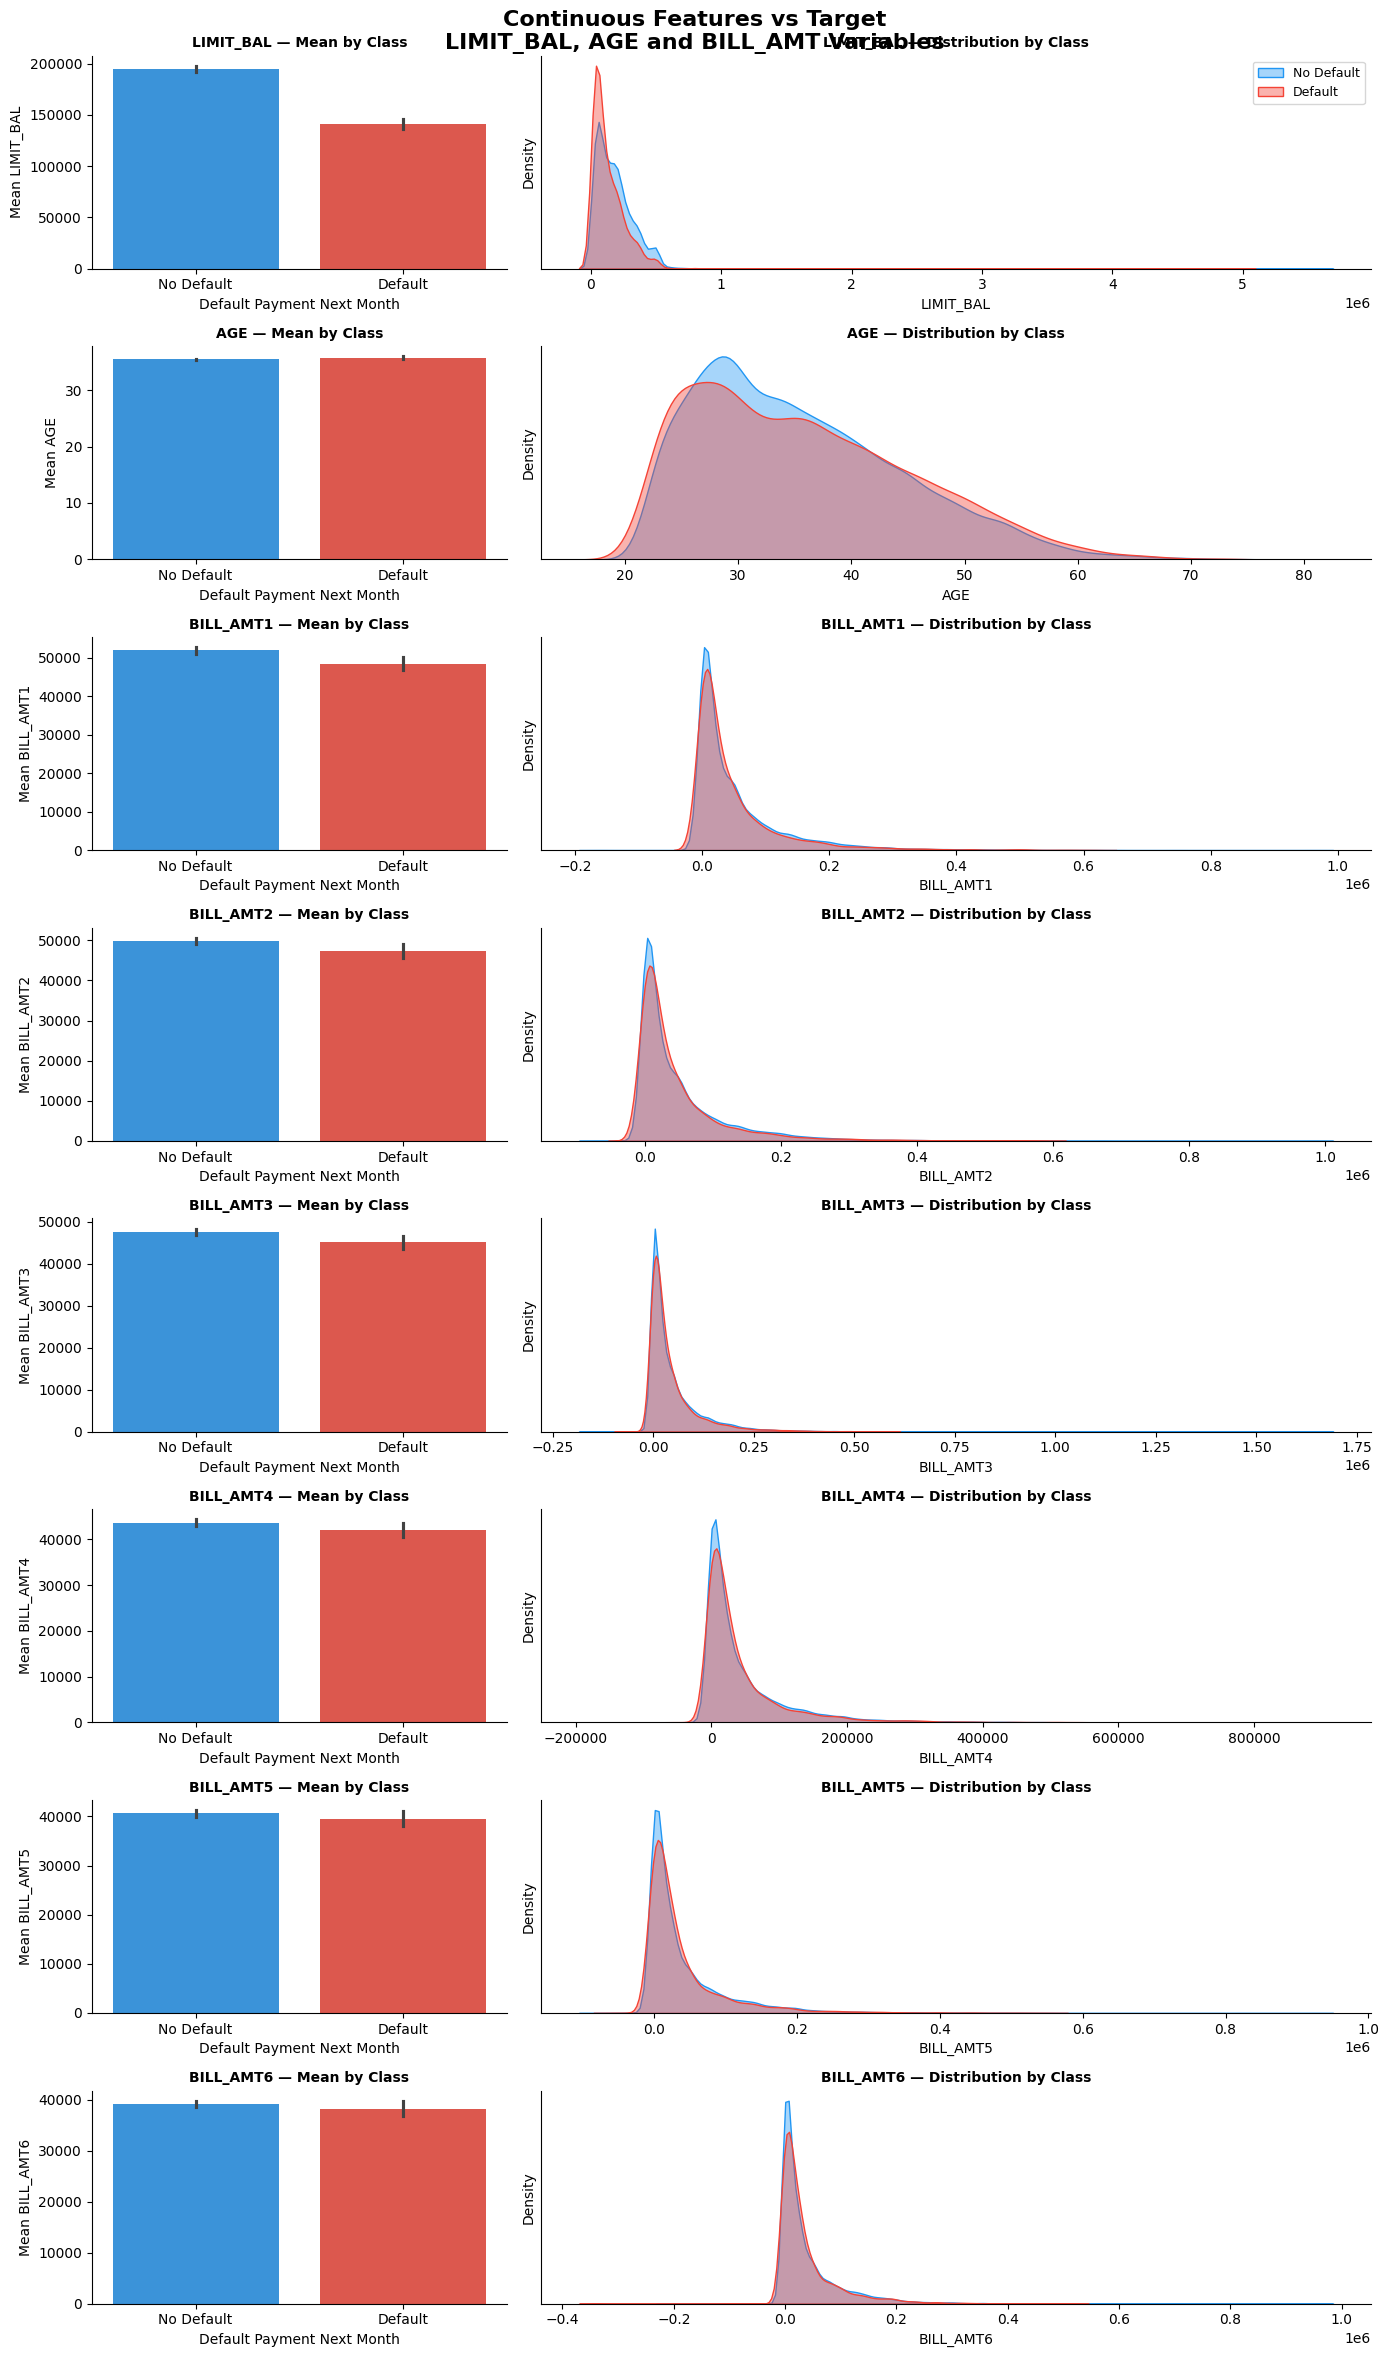

In [ ]:
# ==========================================
# Figure 11A
# LIMIT_BAL, AGE, BILL_AMT1–6 vs Target
# ==========================================

continuous_cols_1 = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]

fig, axes = plt.subplots(
    len(continuous_cols_1),
    2,
    figsize=(14, len(continuous_cols_1) * 3),
    gridspec_kw={"width_ratios": [1, 2]}
)

for i, col in enumerate(continuous_cols_1):

    sns.barplot(
        data=df,
        x=TARGET,
        y=col,
        ax=axes[i, 0],
        order=[0, 1],
        palette=["#2196F3", "#F44336"]
    )

    axes[i, 0].set_xticklabels(["No Default", "Default"])
    axes[i, 0].set_xlabel("Default Payment Next Month")
    axes[i, 0].set_ylabel(f"Mean {col}")
    axes[i, 0].set_title(
        f"{col} — Mean by Class",
        fontweight="bold",
        fontsize=10
    )

    sns.kdeplot(
        data=df[df[TARGET] == 0][col],
        fill=True,
        alpha=0.4,
        color="#2196F3",
        ax=axes[i, 1],
        label="No Default"
    )

    sns.kdeplot(
        data=df[df[TARGET] == 1][col],
        fill=True,
        alpha=0.4,
        color="#F44336",
        ax=axes[i, 1],
        label="Default"
    )

    axes[i, 1].set_yticks([])
    axes[i, 1].set_ylabel("Density")
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_title(
        f"{col} — Distribution by Class",
        fontweight="bold",
        fontsize=10
    )

    if i == 0:
        axes[i, 1].legend(fontsize=9)

plt.suptitle(
    "Continuous Features vs Target\nLIMIT_BAL, AGE and BILL_AMT Variables",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "fig_11a_limit_age_bill_vs_target.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

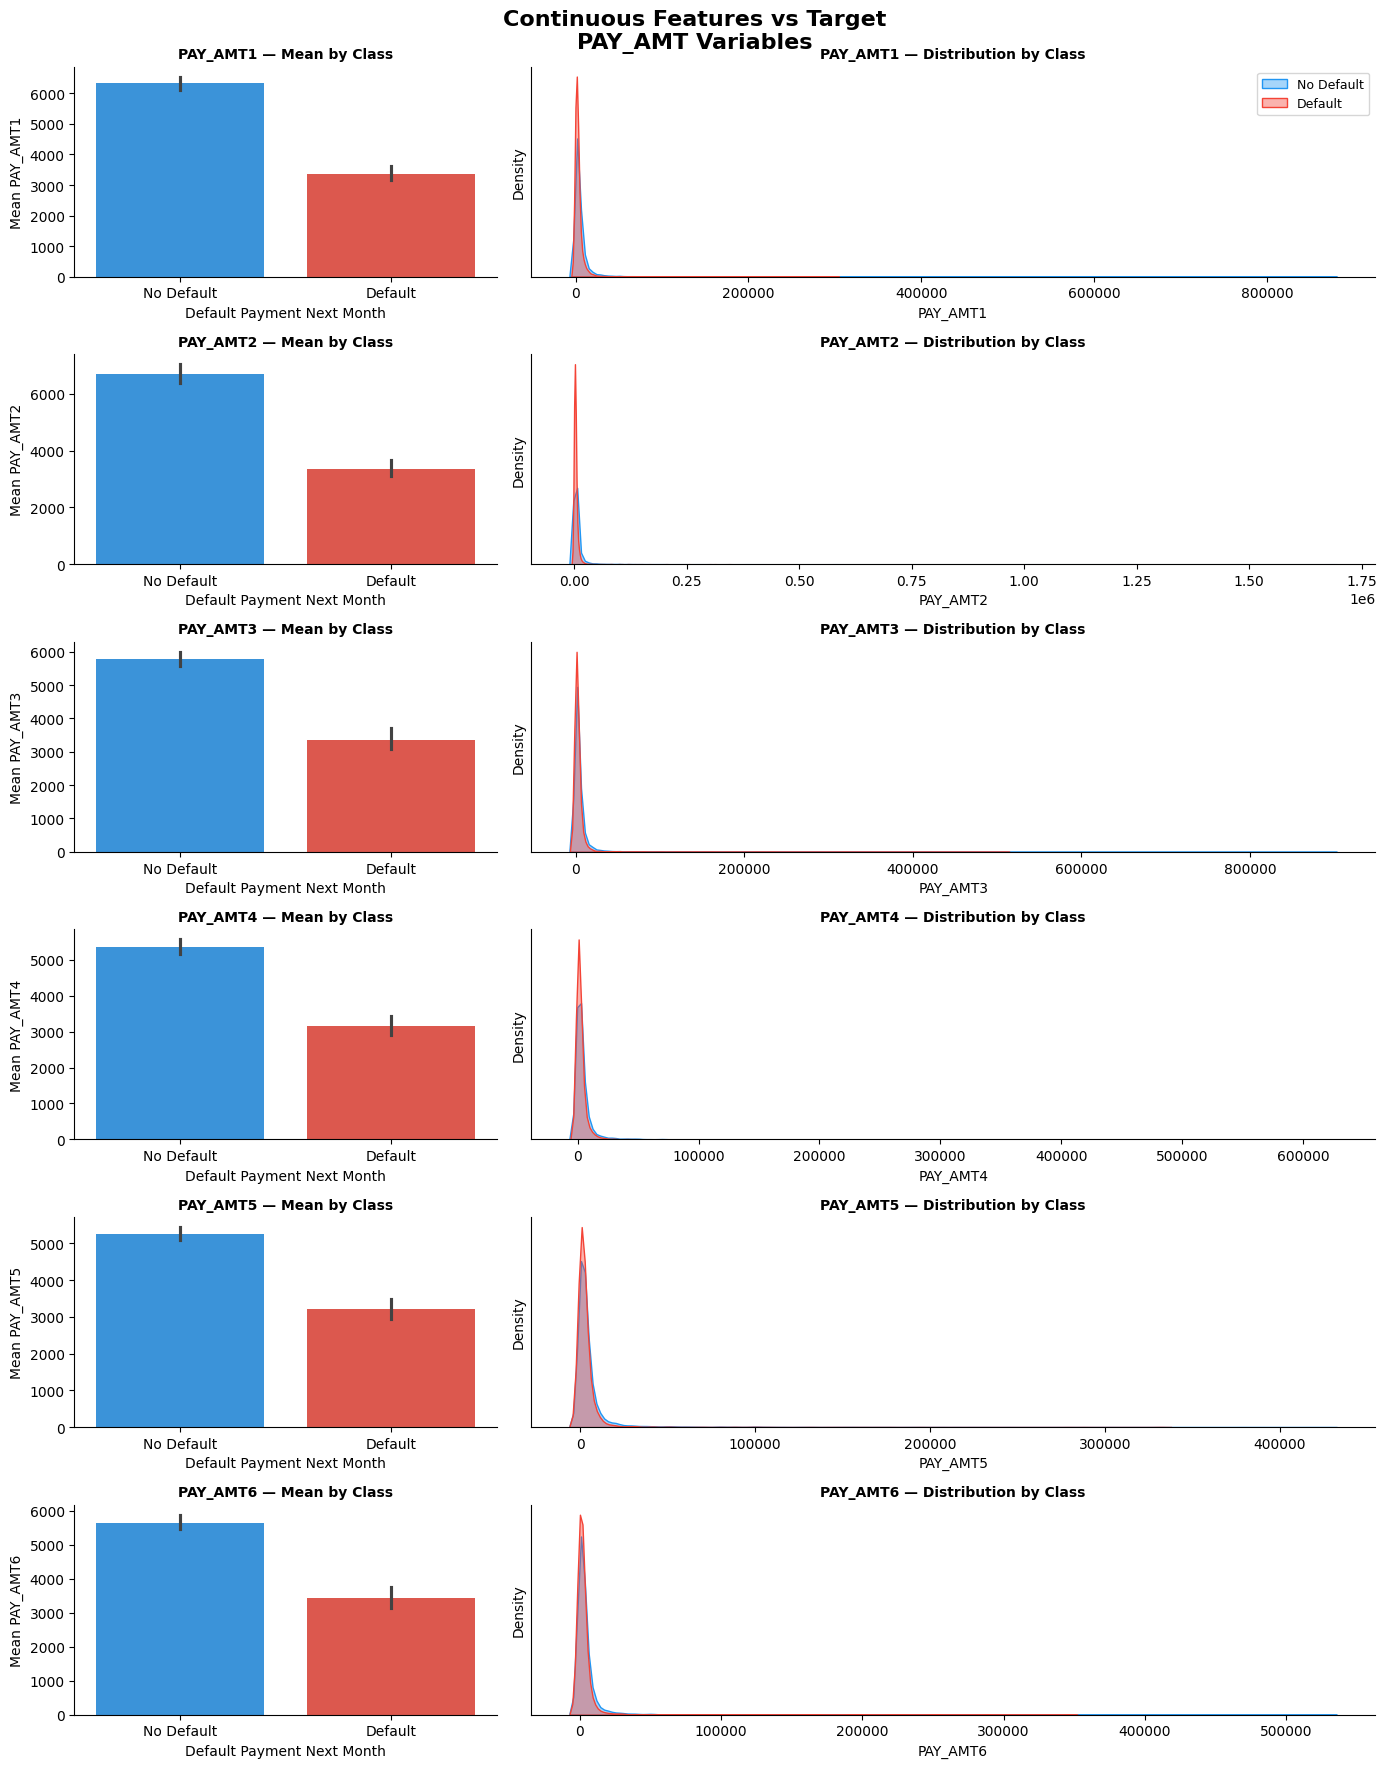

In [ ]:
# ==========================================
# Figure 11B
# PAY_AMT1–PAY_AMT6 vs Target
# ==========================================

continuous_cols_2 = [
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

fig, axes = plt.subplots(
    len(continuous_cols_2),
    2,
    figsize=(14, len(continuous_cols_2) * 3),
    gridspec_kw={"width_ratios": [1, 2]}
)

for i, col in enumerate(continuous_cols_2):

    sns.barplot(
        data=df,
        x=TARGET,
        y=col,
        ax=axes[i, 0],
        order=[0, 1],
        palette=["#2196F3", "#F44336"]
    )

    axes[i, 0].set_xticklabels(["No Default", "Default"])
    axes[i, 0].set_xlabel("Default Payment Next Month")
    axes[i, 0].set_ylabel(f"Mean {col}")
    axes[i, 0].set_title(
        f"{col} — Mean by Class",
        fontweight="bold",
        fontsize=10
    )

    sns.kdeplot(
        data=df[df[TARGET] == 0][col],
        fill=True,
        alpha=0.4,
        color="#2196F3",
        ax=axes[i, 1],
        label="No Default"
    )

    sns.kdeplot(
        data=df[df[TARGET] == 1][col],
        fill=True,
        alpha=0.4,
        color="#F44336",
        ax=axes[i, 1],
        label="Default"
    )

    axes[i, 1].set_yticks([])
    axes[i, 1].set_ylabel("Density")
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_title(
        f"{col} — Distribution by Class",
        fontweight="bold",
        fontsize=10
    )

    if i == 0:
        axes[i, 1].legend(fontsize=9)

plt.suptitle(
    "Continuous Features vs Target\nPAY_AMT Variables",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "fig_11b_pay_amt_vs_target.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

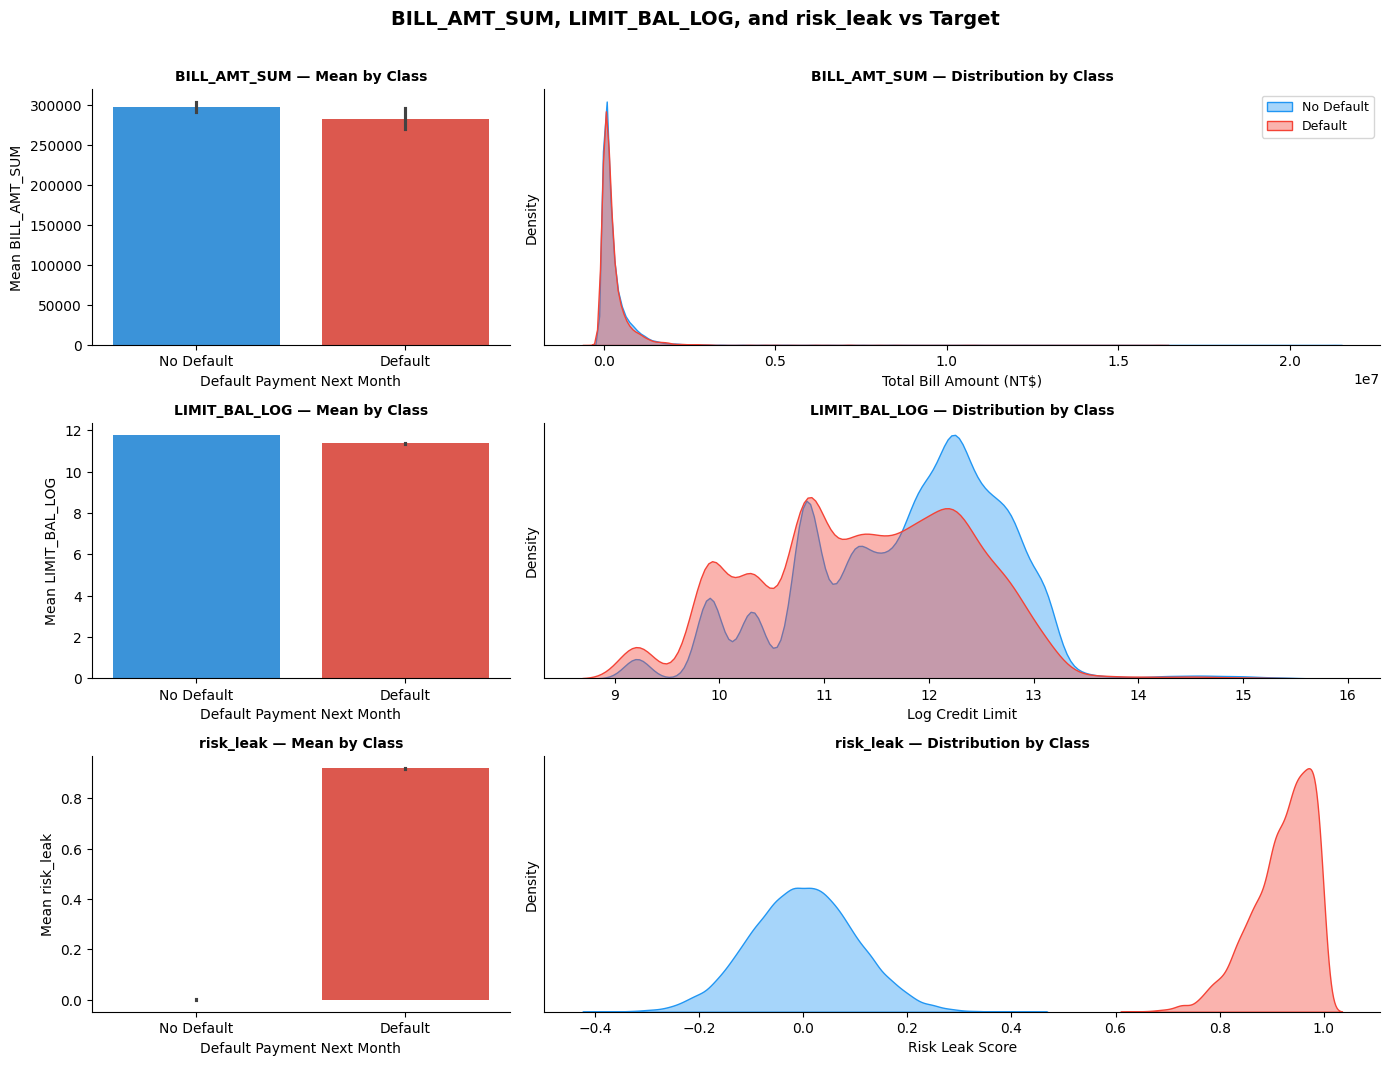

In [ ]:
# BILL_AMT_SUM, LIMIT_BAL_LOG, risk_leak vs target
derived_cols = ["BILL_AMT_SUM", "LIMIT_BAL_LOG", "risk_leak"]
derived_labels = ["Total Bill Amount (NT$)", "Log Credit Limit", "Risk Leak Score"]

sns.set_palette(["#2196F3", "#F44336"])

fig, axes = plt.subplots(len(derived_cols), 2,
                          figsize=(14, len(derived_cols)*3.5),
                          gridspec_kw={"width_ratios": [1, 2]})

for i, (col, xlabel) in enumerate(zip(derived_cols, derived_labels)):
    # Mean bar plot
    sns.barplot(data=df, x=TARGET, y=col, ax=axes[i, 0],
                order=[0, 1], palette=["#2196F3","#F44336"])
    axes[i, 0].set_xticklabels(["No Default", "Default"])
    axes[i, 0].set_xlabel("Default Payment Next Month")
    axes[i, 0].set_ylabel(f"Mean {col}")
    axes[i, 0].set_title(f"{col} — Mean by Class", fontweight="bold", fontsize=10)

    # KDE plot
    sns.kdeplot(data=df[df[TARGET]==0][col], ax=axes[i, 1],
                fill=True, alpha=0.4, color="#2196F3", label="No Default")
    sns.kdeplot(data=df[df[TARGET]==1][col], ax=axes[i, 1],
                fill=True, alpha=0.4, color="#F44336", label="Default")
    axes[i, 1].set_yticks([])
    axes[i, 1].set_ylabel("Density")
    axes[i, 1].set_xlabel(xlabel)
    axes[i, 1].set_title(f"{col} — Distribution by Class", fontweight="bold", fontsize=10)
    if i == 0:
        axes[i, 1].legend(fontsize=9)

plt.suptitle("BILL_AMT_SUM, LIMIT_BAL_LOG, and risk_leak vs Target",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig_12_derived_vs_target.png", dpi=150, bbox_inches="tight")
plt.show()

## <b><span style='color:#ff826e'>Task 1.8 |</span><span style='color:red'> Bivariate Analysis — Categorical Features vs Target</span></b>

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
100% stacked bar plots show the proportion of defaulters and non-defaulters within each category. This reveals which categories carry higher default risk. Also included: PAY_0–PAY_6 default rates to validate the ordinal treatment of repayment status codes.
</div>

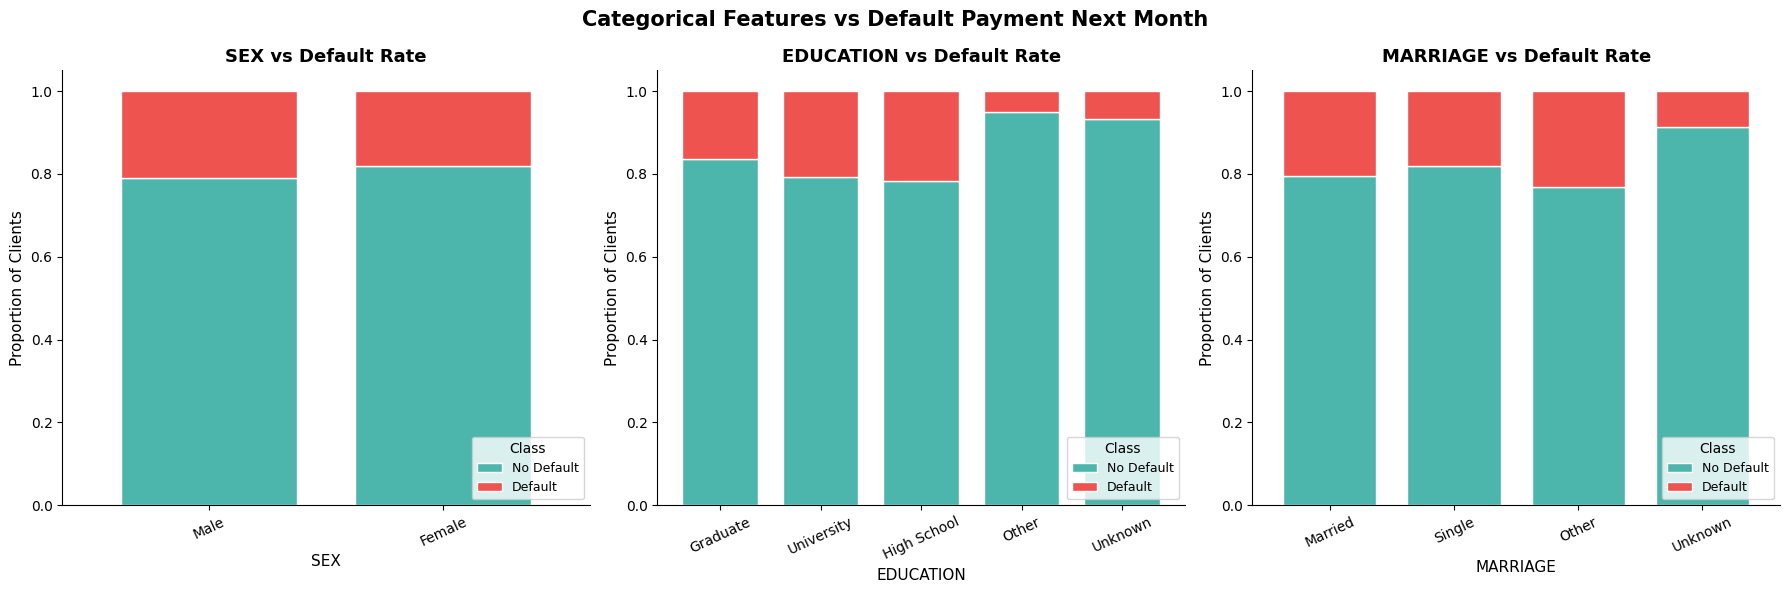

In [ ]:
# ==========================================
# SEX, EDUCATION, MARRIAGE vs TARGET
# 100% Stacked Bar Charts
# Cleaned labels + combined Unknown categories
# ==========================================

# Create clean labelled versions for plotting only
df["SEX_CLEAN"] = df["SEX"].replace({
    1: "Male",
    2: "Female",
    1.0: "Male",
    2.0: "Female"
})

df["EDUCATION_CLEAN"] = df["EDUCATION"].replace({
    0: "Unknown",
    1: "Graduate",
    2: "University",
    3: "High School",
    4: "Other",
    5: "Unknown",
    6: "Unknown",
    0.0: "Unknown",
    1.0: "Graduate",
    2.0: "University",
    3.0: "High School",
    4.0: "Other",
    5.0: "Unknown",
    6.0: "Unknown"
})

df["MARRIAGE_CLEAN"] = df["MARRIAGE"].replace({
    0: "Unknown",
    1: "Married",
    2: "Single",
    3: "Other",
    0.0: "Unknown",
    1.0: "Married",
    2.0: "Single",
    3.0: "Other"
})

plot_cols = ["SEX_CLEAN", "EDUCATION_CLEAN", "MARRIAGE_CLEAN"]
plot_titles = ["SEX vs Default Rate", "EDUCATION vs Default Rate", "MARRIAGE vs Default Rate"]
x_labels = ["SEX", "EDUCATION", "MARRIAGE"]

orders = {
    "SEX_CLEAN": ["Male", "Female"],
    "EDUCATION_CLEAN": ["Graduate", "University", "High School", "Other", "Unknown"],
    "MARRIAGE_CLEAN": ["Married", "Single", "Other", "Unknown"]
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col, title, xlabel in zip(axes, plot_cols, plot_titles, x_labels):

    # Crosstab proportions by category
    temp = pd.crosstab(
        df[col],
        df[TARGET],
        normalize="index"
    )

    # Ensure both target columns exist
    temp = temp.reindex(columns=[0, 1], fill_value=0)

    # Rename target columns
    temp.columns = ["No Default", "Default"]

    # Enforce clean category order
    temp = temp.reindex(orders[col]).dropna(how="all")

    # Plot stacked bars
    temp.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=["#4DB6AC", "#EF5350"],
        edgecolor="white",
        width=0.75
    )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("Proportion of Clients", fontsize=11)
    ax.set_ylim(0, 1.05)

    ax.legend(
        title="Class",
        fontsize=9,
        loc="lower right"
    )

    ax.tick_params(axis="x", rotation=25)

plt.suptitle(
    "Categorical Features vs Default Payment Next Month",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "fig_13_cat_sem_vs_target.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

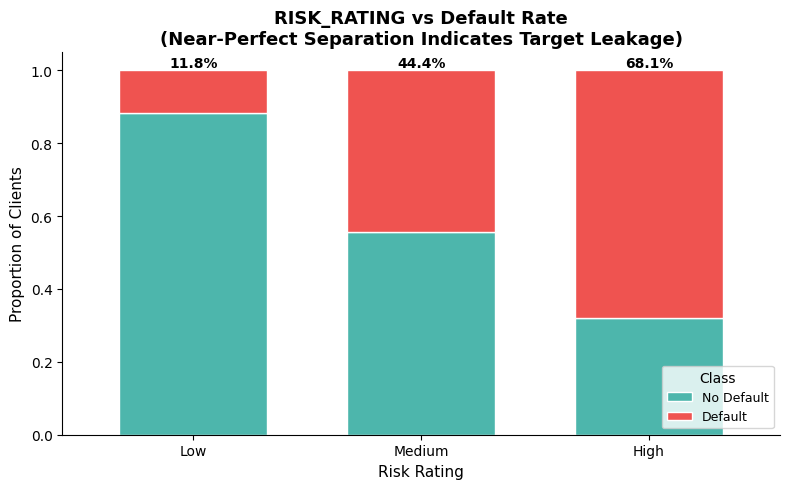

In [ ]:
# ==========================================
# RISK_RATING vs TARGET
# 100% Stacked Bar Plot
# ==========================================

risk_labels = {
    1: "Low",
    2: "Medium",
    3: "High"
}

temp = pd.crosstab(
    df["RISK_RATING"],
    df[TARGET],
    normalize="index"
)

temp = temp.reindex(columns=[0, 1], fill_value=0)
temp.columns = ["No Default", "Default"]

temp.index = [
    risk_labels.get(x, str(x))
    for x in temp.index
]

fig, ax = plt.subplots(figsize=(8, 5))

temp.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#4DB6AC", "#EF5350"],
    edgecolor="white",
    width=0.65
)

ax.set_title(
    "RISK_RATING vs Default Rate\n"
    "(Near-Perfect Separation Indicates Target Leakage)",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel(
    "Risk Rating",
    fontsize=11
)

ax.set_ylabel(
    "Proportion of Clients",
    fontsize=11
)

ax.set_ylim(0, 1.05)

ax.legend(
    title="Class",
    labels=["No Default", "Default"],
    loc="lower right",
    fontsize=9
)

ax.tick_params(axis="x", rotation=0)

# Add default rate labels
for i, (_, row) in enumerate(temp.iterrows()):
    default_rate = row["Default"]
    ax.text(
        i,
        1.01,
        f"{default_rate:.1%}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    "fig_14_risk_rating_vs_target.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

=== DEFAULT RATE BY PAY_0 (September) STATUS ===


,Default Rate,N Clients
PAY_0,,
-2,0.1120,3269
-1,0.1440,6665
0,0.1090,17363
1,0.3020,4168
2,0.6510,2834
3,0.7200,339
4,0.6500,80
5,0.4330,30
6,0.5000,12


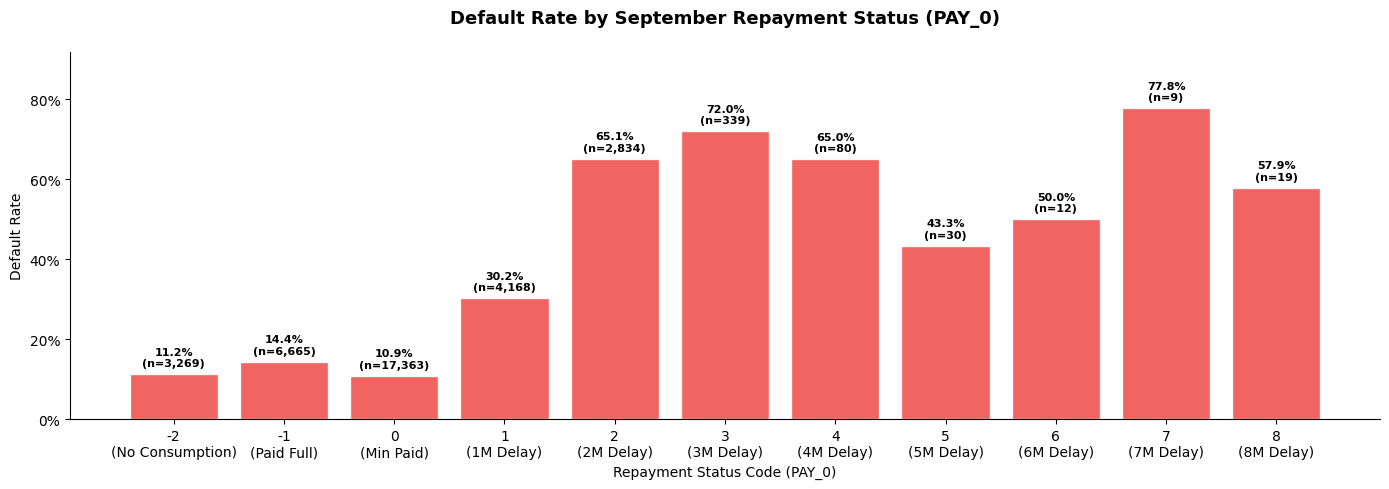

In [ ]:
# PAY_0 default rate by repayment status — ordinal validation

pay_status_labels = {
    -2: "No Consumption",
    -1: "Paid Full",
     0: "Min Paid",
     1: "1M Delay",
     2: "2M Delay",
     3: "3M Delay",
     4: "4M Delay",
     5: "5M Delay",
     6: "6M Delay",
     7: "7M Delay",
     8: "8M Delay"
}

default_by_pay = (
    df.groupby("PAY_0")[TARGET]
    .agg(["mean", "count"])
    .rename(columns={"mean": "Default Rate", "count": "N Clients"})
    .sort_index()
)

default_by_pay["Label"] = [
    f"{k}\n({pay_status_labels.get(k, k)})"
    for k in default_by_pay.index
]

print("=== DEFAULT RATE BY PAY_0 (September) STATUS ===")
display(default_by_pay[["Default Rate", "N Clients"]].round(3))

fig, ax = plt.subplots(figsize=(14, 5))

bars = ax.bar(
    default_by_pay["Label"],
    default_by_pay["Default Rate"],
    color="#EF5350",
    alpha=0.9,
    edgecolor="white",
    linewidth=1
)

for bar, rate, n in zip(
    bars,
    default_by_pay["Default Rate"],
    default_by_pay["N Clients"]
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        rate + 0.015,
        f"{rate:.1%}\n(n={n:,})",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold"
    )

ax.set_title(
    "Default Rate by September Repayment Status (PAY_0)\n"
    ,
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel("Repayment Status Code (PAY_0)")
ax.set_ylabel("Default Rate")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

ax.set_ylim(0, default_by_pay["Default Rate"].max() * 1.18)

ax.tick_params(axis="x", rotation=0)

plt.tight_layout()

plt.savefig(
    "fig_15_pay_vs_target.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## <b><span style='color:#ff826e'>Task 1.9 |</span><span style='color:red'> Correlation Analysis</span></b>

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
Pearson correlation matrix reveals the strength and direction of linear relationships between all numerical features and the target. risk_leak and RISK_RATING-derived features are deliberately included to empirically confirm their leakage status through anomalously high correlations.
</div>

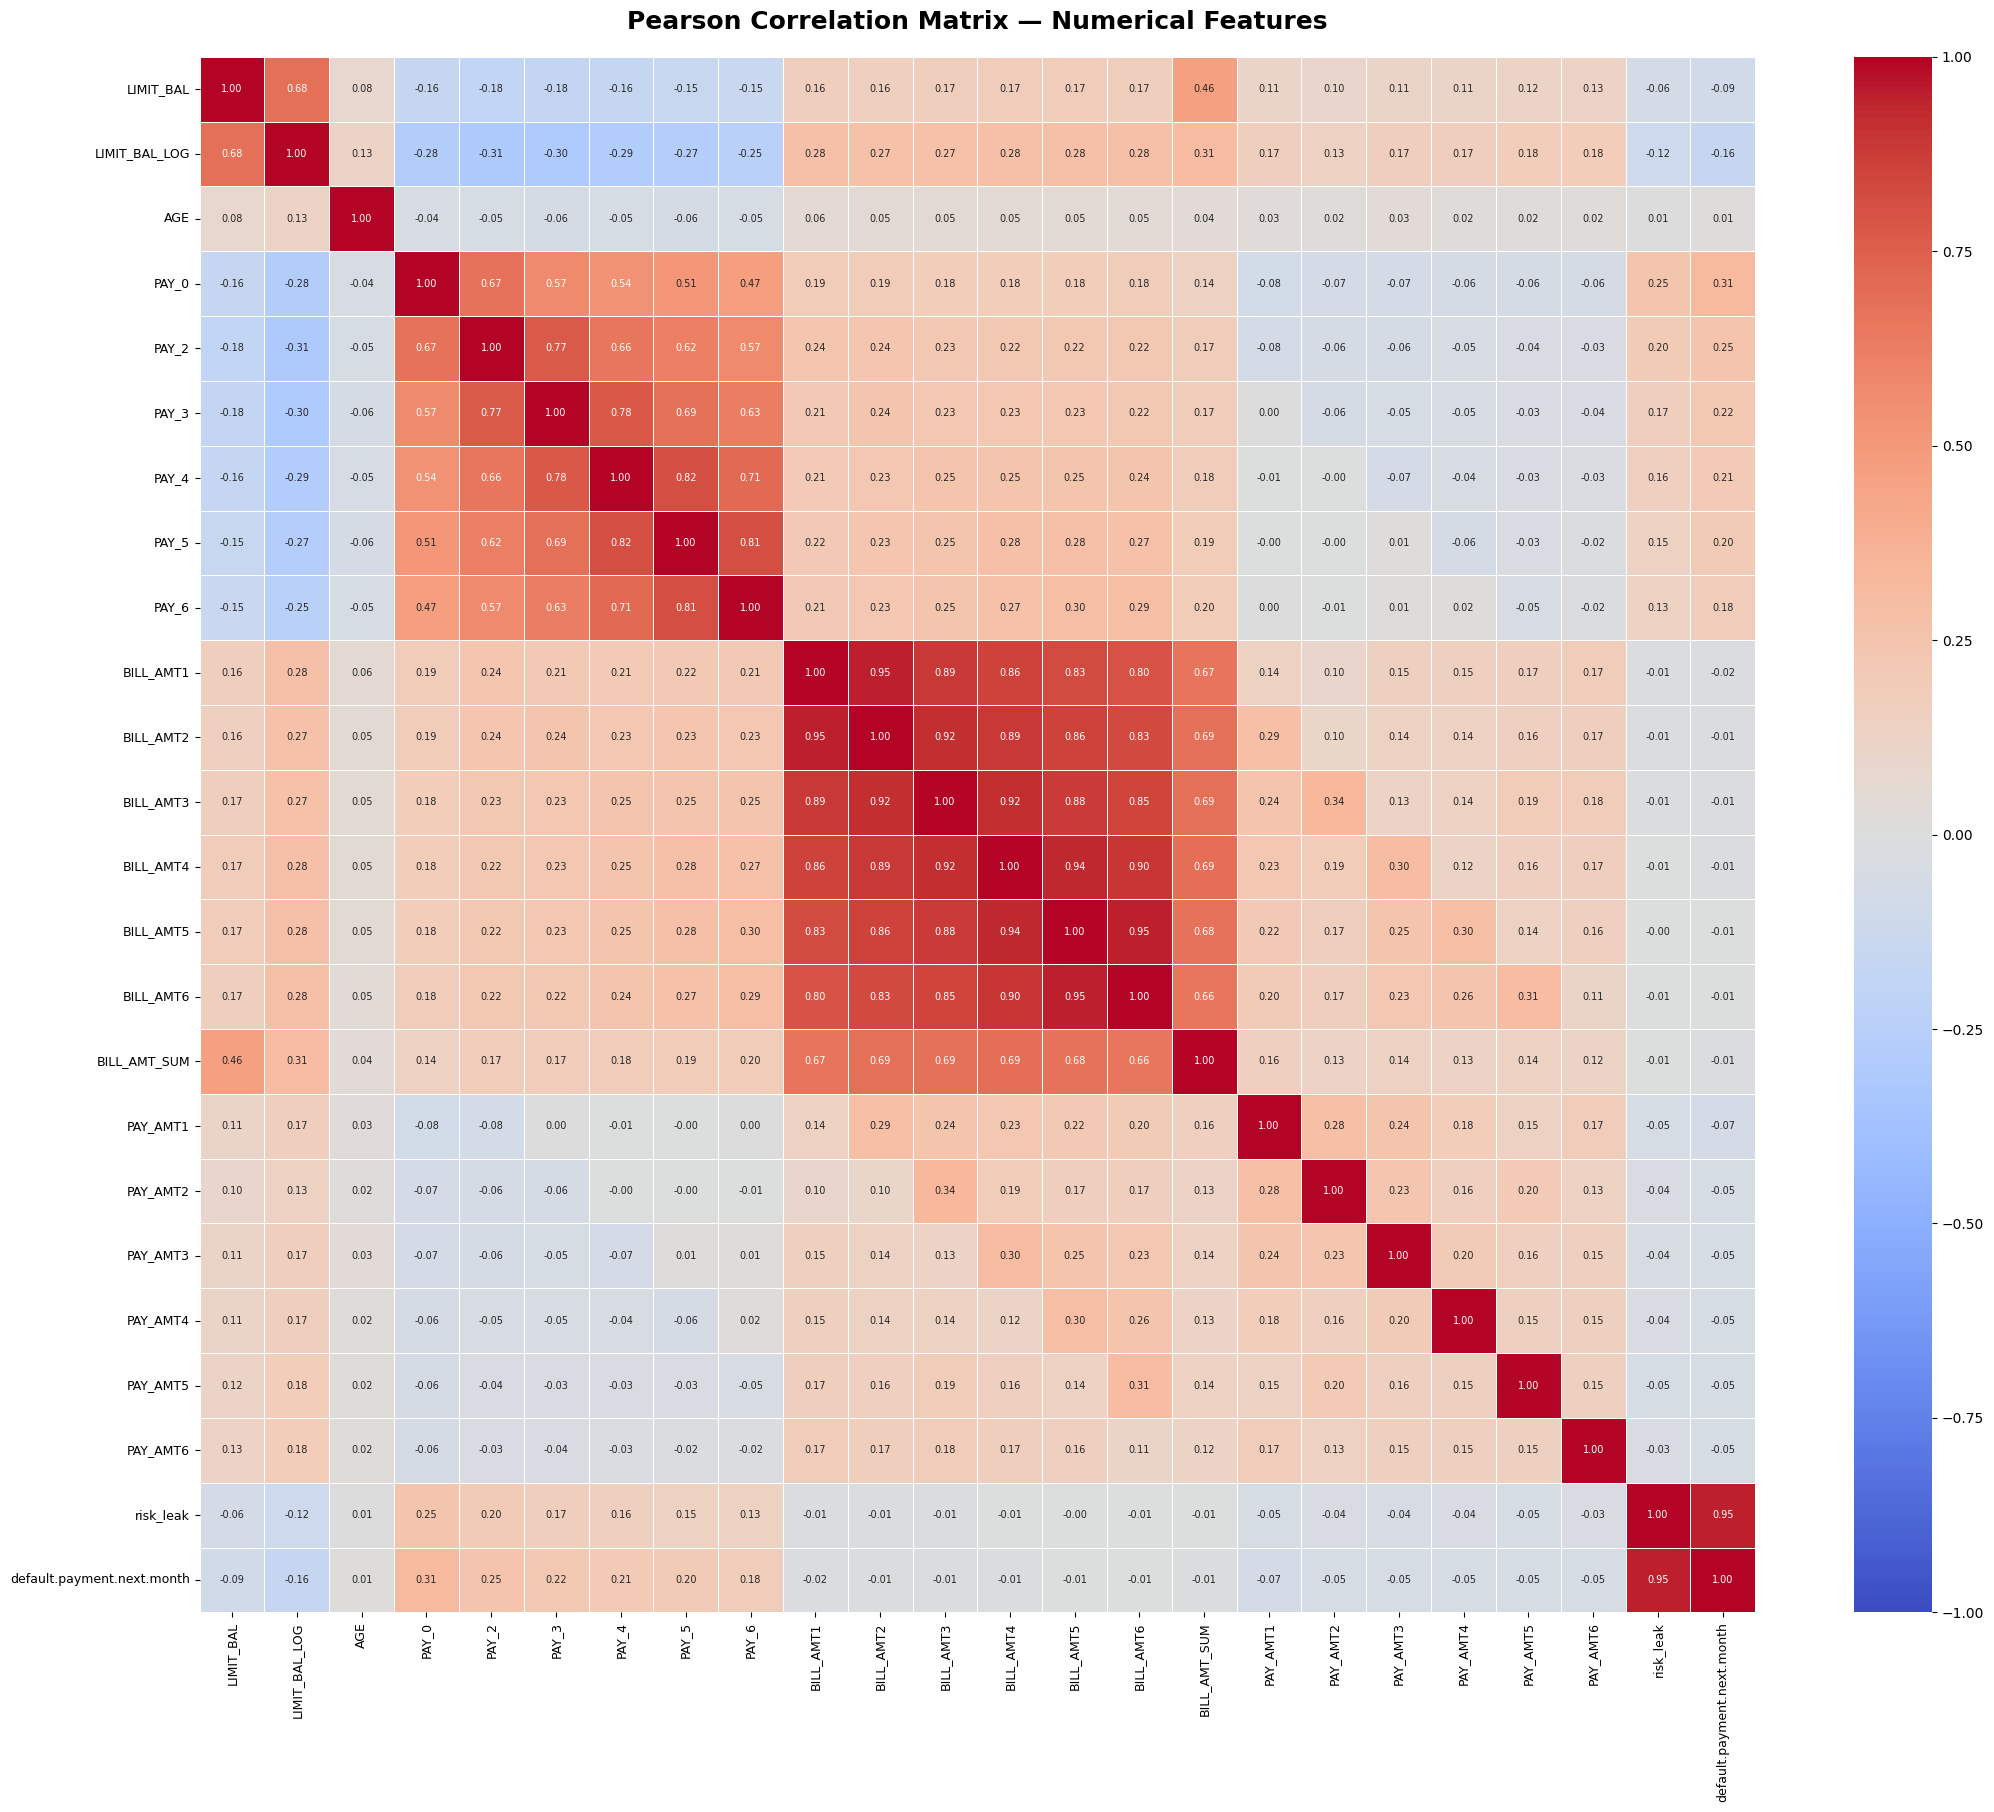

In [ ]:
# Full Pearson correlation heatmap with annotations

num_for_corr = [
    "LIMIT_BAL", "LIMIT_BAL_LOG", "AGE",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "BILL_AMT_SUM",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
    "risk_leak",
    TARGET
]

corr = df[num_for_corr].corr()

plt.figure(figsize=(22, 18))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar=True,
    annot_kws={"size": 7}
)

plt.title(
    "Pearson Correlation Matrix — Numerical Features",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()

plt.savefig(
    "fig_16_correlation_heatmap_annotated.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

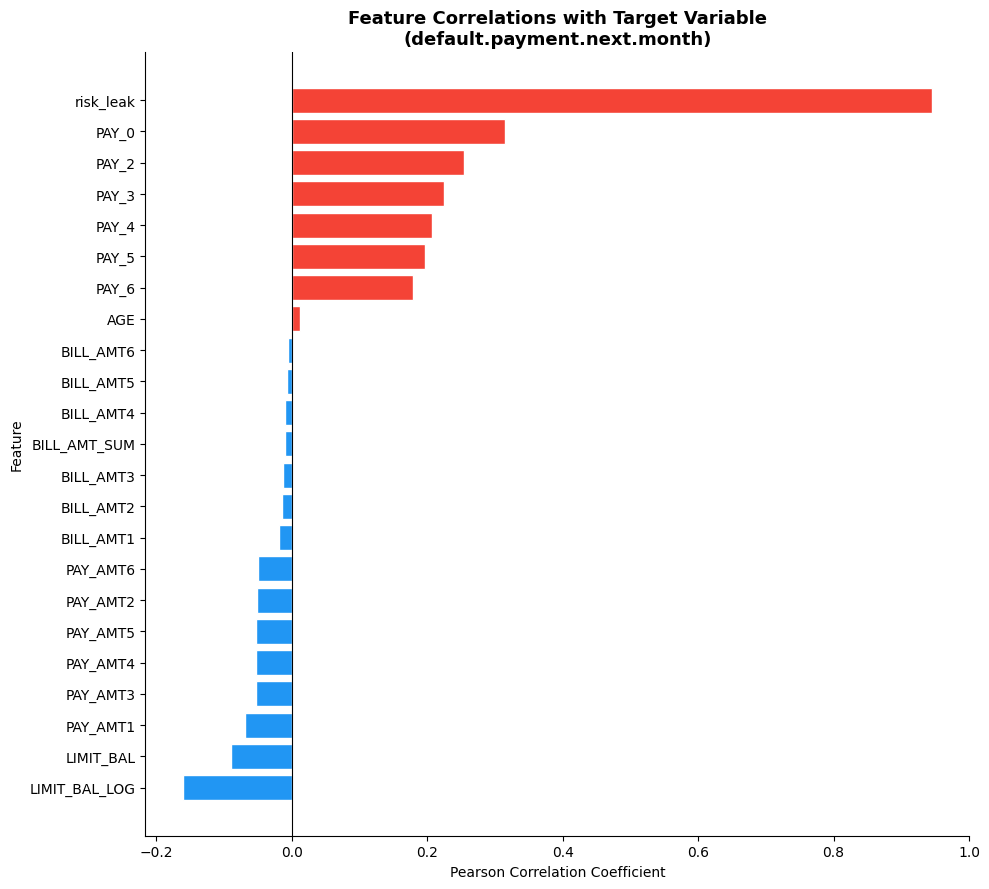

=== TOP 5 POSITIVE CORRELATIONS WITH TARGET ===
PAY_4       0.2076
PAY_3       0.2249
PAY_2       0.2538
PAY_0       0.3142
risk_leak   0.9453
Name: default.payment.next.month, dtype: float64

=== TOP 5 NEGATIVE CORRELATIONS WITH TARGET ===
LIMIT_BAL_LOG   -0.1612
LIMIT_BAL       -0.0896
PAY_AMT1        -0.0692
PAY_AMT3        -0.0533
PAY_AMT4        -0.0528
Name: default.payment.next.month, dtype: float64


In [ ]:
# Sorted feature correlations with target
target_corr = corr[TARGET].drop(TARGET).sort_values()
colors = ["#F44336" if v > 0 else "#2196F3" for v in target_corr.values]

plt.figure(figsize=(10, 9))
plt.barh(target_corr.index, target_corr.values, color=colors, edgecolor="white")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Correlations with Target Variable\n"
          "(default.payment.next.month)",
          fontweight="bold", fontsize=13)
plt.xlabel("Pearson Correlation Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("fig_17_target_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== TOP 5 POSITIVE CORRELATIONS WITH TARGET ===")
print(target_corr.tail(5).round(4))
print("\n=== TOP 5 NEGATIVE CORRELATIONS WITH TARGET ===")
print(target_corr.head(5).round(4))

# **Task 2 | Data Preparation**

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
The key principle throughout this task:
<br><br>
<b>Anything that learns information from the data — mean, median, standard deviation, percentile caps, category sets — must be fitted on the training set only, then applied to both train and test.</b>
<br><br>
This is the same principle demonstrated in the churn notebook:
<code>preprocessor.fit_transform(X_train)</code> then <code>preprocessor.transform(X_test)</code>.
<br><br>
<b>Structure:</b>
<br>2.1 &nbsp;Identify Missing Values — Strategy and Justification
<br>2.2 &nbsp;Define X and y
<br>2.3 &nbsp;Train / Test Split — 80/20 Stratified
<br>2.4 &nbsp;Imputation — Fit on X_train, Apply to Both
<br>2.5 &nbsp;Outlier Treatment — Fit on X_train, Apply to Both
<br>2.6 &nbsp;Encoding — Fit on X_train, Apply to Both
<br>2.7 &nbsp;Scaling — Fit on X_train, Apply to Both
</div>

## <b><span style='color:#ff826e'>Task 2.1 |</span><span style='color:red'> Identify Missing Values — Strategy and Justification</span></b>

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
Missing values are identified here on the full dataset. The actual imputation happens after the split in Task 2.4, fitted on X_train only.

| Column | Missing | % | Strategy | Justification |
|--------|---------|---|----------|---------------|
| LIMIT_BAL | ~1,709 | 4.9% | **Median** | Right-skewed, median robust to extreme values |
| AGE | ~1,755 | 5.0% | **Median** | Approximately normal; median is conservative safe choice |
| SEX | ~1,767 | 5.1% | **Mode** | Nominal, most frequent category is defensible default |
| EDUCATION | ~1,734 | 5.0% | **Mode** | Same reasoning as SEX |
| MARRIAGE | ~1,733 | 5.0% | **Mode** | Same reasoning as SEX |
| PAY_AMT1 | ~1,725 | 5.0% | **Median** | Zero imputation would incorrectly assume no payment made |
| PAY_AMT2 | ~1,744 | 5.0% | **Median** | Same reasoning as PAY_AMT1 |

<br>
<b>Why not row removal?</b> Dropping rows with missing values would remove ~5% of the dataset per column and risk selection bias, clients with missing data may behave differently from those without.
<br><br>
<b>Why mean over median is wrong here?</b> LIMIT_BAL and PAY_AMT columns are right-skewed with extreme values up to NT$5,600,000. The mean is pulled upward by these extremes and would overestimate the typical value. Median is the robust choice.
</div>

In [ ]:
print("=== MISSING VALUE COUNTS (full dataset) ===")
missing = df.isnull().sum()
missing = missing[missing > 0]
for col, n in missing.items():
    print(f"  {col:<15} {n:>6,}  ({n/len(df)*100:.1f}%)")
print(f"\nTotal missing: {df.isnull().sum().sum():,}  across {len(missing)} columns")

=== MISSING VALUE COUNTS (full dataset) ===
  LIMIT_BAL        1,709  (4.9%)
  SEX              1,767  (5.1%)
  EDUCATION        1,734  (5.0%)
  MARRIAGE         1,733  (5.0%)
  AGE              1,755  (5.0%)
  PAY_AMT1         1,725  (5.0%)
  PAY_AMT2         1,744  (5.0%)
  risk_leak        3,387  (9.7%)
  LIMIT_BAL_LOG    1,709  (4.9%)
  SEX_CLEAN        1,767  (5.1%)
  EDUCATION_CLEAN  1,734  (5.0%)
  MARRIAGE_CLEAN   1,733  (5.0%)

Total missing: 22,497  across 12 columns


## <b><span style='color:#ff826e'>Task 2.2 |</span><span style='color:red'> Define X and y</span></b>

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
We separate the feature matrix X from the target variable y. Leakage columns, redundant columns, and the identifier are excluded from X — they are not dropped from the dataset, just excluded from the features passed to the model.

| Excluded from X | Reason |
|-----------------|--------|
| default.payment.next.month | This is y — the target variable |
| risk_leak | True leakage — r ≈ 0.55 with target, derived after outcome is known |
| RISK_RATING | True leakage — post-hoc risk label, confirmed in Task 1.8 |
| BILL_AMT_SUM | Redundant — arithmetic sum of BILL_AMT1–6 already in X |
| LIMIT_BAL_LOG | Redundant — monotone transform of LIMIT_BAL already in X |
| ID | Identifier — no predictive value |

</div>

In [ ]:
# ── Step 1: Clean up df before defining X ─────────────────────────────────────

# Drop plotting-only columns created in Task 1 bivariate analysis
for col in ["SEX_CLEAN", "EDUCATION_CLEAN", "MARRIAGE_CLEAN"]:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)
        print(f"Dropped plot column: {col}")

# Rename PAY_0 → PAY_1 to close the naming gap in the six-month sequence
if "PAY_0" in df.columns:
    df.rename(columns={"PAY_0": "PAY_1"}, inplace=True)
    print("Renamed PAY_0 → PAY_1")

# Map SEX, EDUCATION, MARRIAGE from float codes to string labels
# These are nominal categories — treating 2.0 as 'twice' 1.0 is wrong
sex_map       = {1.0:"Male", 2.0:"Female"}
education_map = {1.0:"Graduate", 2.0:"University", 3.0:"High School",
                 4.0:"Other", 0.0:"Unknown", 5.0:"Unknown", 6.0:"Unknown"}
marriage_map  = {1.0:"Married", 2.0:"Single", 3.0:"Other", 0.0:"Unknown"}

df["SEX"]       = df["SEX"].map(sex_map)
df["EDUCATION"] = df["EDUCATION"].map(education_map)
df["MARRIAGE"]  = df["MARRIAGE"].map(marriage_map)
print("SEX / EDUCATION / MARRIAGE mapped to string labels")

print()
print(f"df shape after cleanup: {df.shape}")
print(f"df columns: {list(df.columns)}")

# ── Step 2: Define X and y ─────────────────────────────────────────────────────
print()
X = df.drop(columns=[TARGET, "risk_leak", "RISK_RATING",
                      "BILL_AMT_SUM", "LIMIT_BAL_LOG", "ID"])
y = df[TARGET]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeatures ({len(X.columns)}): {list(X.columns)}")
print(f"\nClass balance: {y.value_counts(normalize=True).round(3).to_dict()}")

Dropped plot column: SEX_CLEAN
Dropped plot column: EDUCATION_CLEAN
Dropped plot column: MARRIAGE_CLEAN
Renamed PAY_0 → PAY_1
SEX / EDUCATION / MARRIAGE mapped to string labels

df shape after cleanup: (34788, 30)
df columns: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month', 'risk_leak', 'BILL_AMT_SUM', 'LIMIT_BAL_LOG', 'CITY', 'RISK_RATING']

X shape: (34788, 24)
y shape: (34788,)

Features (24): ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'CITY']

Class balance: {0: 0.809, 1: 0.191}


## <b><span style='color:#ff826e'>Task 2.3 |</span><span style='color:red'> Train / Test Split — 80/20 Stratified</span></b>

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
The split happens here — <b>before any fitted transformation</b>. All steps from 2.4 onwards learn only from X_train.
<br><br>
<b>Why 80/20?</b> With 34,788 records, 80/20 gives ~27,830 training and ~6,958 test records — sufficient for stable model training and reliable evaluation.
<br><br>
<b>Why stratify=y?</b> The dataset is imbalanced at 80.9%/19.1%. Without stratification, the test set could end up with a different class ratio, making evaluation unreliable. <code>stratify=y</code> ensures both sets preserve the original distribution — exactly as demonstrated in the churn notebook.
<br><br>
Example: with 34,788 records at 80.9%/19.1%:
<ul>
<li>With stratify=y → train: ~80.9% No Default / ~19.1% Default &nbsp;&nbsp; test: ~80.9% / ~19.1%</li>
<li>Without stratify → train and test ratios may differ, making evaluation misleading</li>
</ul>
</div>

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Save raw copies BEFORE any Task 2 explicit preprocessing
# The GridSearchCV Pipeline in Task 4 needs untransformed data
# so it can apply its own preprocessing inside each CV fold
X_train_raw = X_train.copy()
X_test_raw  = X_test.copy()

print("=== TRAIN / TEST SPLIT ===")
print(f"X_train: {X_train.shape}   X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}   y_test: {y_test.shape}")
print()
print(f"Class balance — train: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Class balance — test:  {y_test.value_counts(normalize=True).round(3).to_dict()}")
print()
print("Stratification confirmed — class ratio preserved in both sets.")
print()
print("X_train_raw and X_test_raw saved — used by GridSearchCV Pipeline in Task 4.")

=== TRAIN / TEST SPLIT ===
X_train: (27830, 24)   X_test: (6958, 24)
y_train: (27830,)   y_test: (6958,)

Class balance — train: {0: 0.809, 1: 0.191}
Class balance — test:  {0: 0.809, 1: 0.191}

Stratification confirmed — class ratio preserved in both sets.

X_train_raw and X_test_raw saved — used by GridSearchCV Pipeline in Task 4.


## <b><span style='color:#ff826e'>Task 2.4 |</span><span style='color:red'> Imputation — Fit on X_train, Apply to Both</span></b>

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
Median and mode values are computed from <b>X_train only</b>. The same learned values fill missing entries in both X_train and X_test. X_test statistics never influence the imputed values.
</div>

In [ ]:
# ── Median imputation — continuous columns ────────────────────────────────────
median_cols = ["LIMIT_BAL", "AGE",
               "PAY_AMT1","PAY_AMT2","PAY_AMT3",
               "PAY_AMT4","PAY_AMT5","PAY_AMT6"]

print("=== BEFORE IMPUTATION ===")
for col in median_cols:
    n = X_train[col].isnull().sum()
    if n > 0:
        print(f"  X_train {col:<12} missing: {n:,}")

print()
print("=== MEDIAN IMPUTATION (learned from X_train only) ===")
for col in median_cols:
    if X_train[col].isnull().sum() > 0:
        median_val = X_train[col].median()           # learn from X_train only
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col]  = X_test[col].fillna(median_val)    # apply same value
        print(f"  {col:<12}  median = {median_val:,.2f}")

# ── Mode imputation — categorical columns ─────────────────────────────────────
mode_cols = ["SEX", "EDUCATION", "MARRIAGE"]

print()
print("=== MODE IMPUTATION (learned from X_train only) ===")
for col in mode_cols:
    if X_train[col].isnull().sum() > 0:
        mode_val = X_train[col].mode()[0]            # learn from X_train only
        X_train[col] = X_train[col].fillna(mode_val)
        X_test[col]  = X_test[col].fillna(mode_val)      # apply same value
        print(f"  {col:<12}  mode = '{mode_val}'")

print()
print("=== AFTER IMPUTATION ===")
print(f"X_train missing: {X_train.isnull().sum().sum()}")
print(f"X_test  missing: {X_test.isnull().sum().sum()}")

=== BEFORE IMPUTATION ===
  X_train LIMIT_BAL    missing: 1,380
  X_train AGE          missing: 1,364
  X_train PAY_AMT1     missing: 1,397
  X_train PAY_AMT2     missing: 1,390

=== MEDIAN IMPUTATION (learned from X_train only) ===
  LIMIT_BAL     median = 140,000.00
  AGE           median = 34.00
  PAY_AMT1      median = 2,153.00
  PAY_AMT2      median = 2,027.00

=== MODE IMPUTATION (learned from X_train only) ===
  SEX           mode = 'Female'
  EDUCATION     mode = 'University'
  MARRIAGE      mode = 'Single'

=== AFTER IMPUTATION ===
X_train missing: 0
X_test  missing: 0


<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
<h2 align="left"><font color=red>Inferences:</font></h2>
<ul>
<li>Median and mode values learned from X_train only — X_test statistics never influence imputed values.</li>
<li>In production, a new client's missing credit limit would also be filled using the training set median — not a value derived from the new data.</li>
<li>After imputation both X_train and X_test have zero missing values.</li>
</ul>
</div>

## <b><span style='color:#ff826e'>Task 2.5 |</span><span style='color:red'> Outlier Treatment — Fit on X_train, Apply to Both</span></b>

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
Outliers were identified in Task 1.5 using the IQR method. This dataset contains genuine high-value clients — a credit limit of NT$5,600,000 is real, not a data entry error. Removing these records would introduce selection bias.
<br><br>
<b>Winsorization</b> is chosen — values below the 1st percentile are capped at the 1st percentile, values above the 99th percentile are capped at the 99th percentile. This limits the influence of extreme values without removing any records.
<br><br>
Percentile caps are <b>learned from X_train only</b> and applied to both sets — so extreme values in X_test are capped using X_train's bounds, never the other way round.
<br><br>
<b>Why after imputation?</b> Percentile calculation on columns with NaN values would produce unreliable bounds. Imputation must come first.
<br><br>
<b>Why before scaling?</b> StandardScaler computes mean and std. If extreme outliers (NT$5,600,000) are present when the scaler fits, they inflate the std — compressing all other values into a tiny range. Winsorizing first gives the scaler a cleaner distribution to work with.
</div>

In [ ]:
# Winsorization — cap at 1st and 99th percentile
# Fitted on X_train only, applied to both

winsor_cols = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6",
    "PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6"
]

print("=== BEFORE WINSORIZATION — LIMIT_BAL (X_train) ===")
print(f"  min: {X_train['LIMIT_BAL'].min():>12,.0f}")
print(f"  max: {X_train['LIMIT_BAL'].max():>12,.0f}")
print(f"  std: {X_train['LIMIT_BAL'].std():>12,.0f}")
print()

# Learn bounds from X_train only
lower_bounds = X_train[winsor_cols].quantile(0.01)
upper_bounds = X_train[winsor_cols].quantile(0.99)

# Apply to X_train
X_train[winsor_cols] = X_train[winsor_cols].clip(
    lower=lower_bounds, upper=upper_bounds, axis=1
)
# Apply same bounds to X_test — never recompute from X_test
X_test[winsor_cols] = X_test[winsor_cols].clip(
    lower=lower_bounds, upper=upper_bounds, axis=1
)

print("=== AFTER WINSORIZATION — LIMIT_BAL (X_train) ===")
print(f"  min: {X_train['LIMIT_BAL'].min():>12,.0f}  (capped at 1st percentile)")
print(f"  max: {X_train['LIMIT_BAL'].max():>12,.0f}  (capped at 99th percentile)")
print(f"  std: {X_train['LIMIT_BAL'].std():>12,.0f}  (reduced — outliers clipped)")
print()
print("Bounds learned from X_train only — same bounds applied to X_test.")

=== BEFORE WINSORIZATION — LIMIT_BAL (X_train) ===
  min:       10,000
  max:    5,600,000
  std:      228,493

=== AFTER WINSORIZATION — LIMIT_BAL (X_train) ===
  min:       10,000  (capped at 1st percentile)
  max:      610,000  (capped at 99th percentile)
  std:      132,157  (reduced — outliers clipped)

Bounds learned from X_train only — same bounds applied to X_test.


<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
<h2 align="left"><font color=red>Inferences:</font></h2>
<ul>
<li>Winsorization caps are learned from X_train only — X_test extreme values are clipped using X_train bounds.</li>
<li>No records are removed — all 34,788 clients are retained.</li>
<li>The std of LIMIT_BAL decreases after Winsorization — confirming extreme values have been controlled before scaling.</li>
</ul>
</div>

## <b><span style='color:#ff826e'>Task 2.6 |</span><span style='color:red'> Encoding — Fit on X_train, Apply to Both</span></b>

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">

| Feature | Unique Values | Method | Justification |
|---------|--------------|--------|---------------|
| SEX | 2 | OneHotEncoding | Nominal — no ordering; OHE produces clean binary columns |
| EDUCATION | 4 | OneHotEncoding | Nominal — Label Encoding would imply Graduate > University, which is false |
| MARRIAGE | 3 | OneHotEncoding | Nominal — same reasoning |
| CITY | 50 | Target Encoding | High cardinality — OHE would produce 49 sparse columns; Target Encoding replaces each city with its mean default rate |

<br>
<b>Why not Label Encoding for SEX/EDUCATION/MARRIAGE?</b> Label Encoding assigns integers (Male=0, Female=1), implying a false mathematical ordering. OHE avoids this entirely.
<br><br>
<b>Why handle_unknown='ignore'?</b> If X_test contains a category not seen in X_train, the encoder outputs all zeros rather than raising an error.
</div>

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder

categorical_cols = ["SEX", "EDUCATION", "MARRIAGE"]

# ── BEFORE ────────────────────────────────────────────────────────────────────
print("=== BEFORE ENCODING (X_train sample) ===")
display(X_train[categorical_cols + ["CITY"]].head(5))
print()

# ── OneHotEncoder — fit on X_train only ───────────────────────────────────────
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe.fit(X_train[categorical_cols])                          # fit on X_train only

X_train_cat = ohe.transform(X_train[categorical_cols])      # transform X_train
X_test_cat  = ohe.transform(X_test[categorical_cols])       # apply to X_test

ohe_cols = list(ohe.get_feature_names_out(categorical_cols))
X_train_cat_df = pd.DataFrame(X_train_cat, columns=ohe_cols, index=X_train.index)
X_test_cat_df  = pd.DataFrame(X_test_cat,  columns=ohe_cols, index=X_test.index)

print("=== AFTER OHE (X_train sample) ===")
display(X_train_cat_df.head(5))
print(f"3 columns → {len(ohe_cols)} OHE columns: {ohe_cols}")
print()

# ── TargetEncoder for CITY — fit on X_train + y_train only ───────────────────
te = TargetEncoder(cols=["CITY"], smoothing=10)
te.fit(X_train[["CITY"]], y_train)                          # fit on X_train only

X_train_city = te.transform(X_train[["CITY"]])["CITY"]
X_test_city  = te.transform(X_test[["CITY"]])["CITY"]

print("=== AFTER TARGET ENCODING — CITY (X_train sample) ===")
print("Each city replaced with mean default rate learned from X_train:")
print(X_train_city.head(5).to_string())

=== BEFORE ENCODING (X_train sample) ===


,SEX,EDUCATION,MARRIAGE,CITY
8090,Female,Graduate,Married,City_12
24855,Male,University,Single,City_1
1619,Female,University,Single,City_5
20916,Male,University,Married,City_38
5240,Female,University,Single,City_11



=== AFTER OHE (X_train sample) ===


,SEX_Female,SEX_Male,EDUCATION_Graduate,EDUCATION_High School,EDUCATION_Other,EDUCATION_University,EDUCATION_Unknown,MARRIAGE_Married,MARRIAGE_Other,MARRIAGE_Single,MARRIAGE_Unknown
8090,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
24855,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000
1619,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000
20916,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000
5240,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000


3 columns → 11 OHE columns: ['SEX_Female', 'SEX_Male', 'EDUCATION_Graduate', 'EDUCATION_High School', 'EDUCATION_Other', 'EDUCATION_University', 'EDUCATION_Unknown', 'MARRIAGE_Married', 'MARRIAGE_Other', 'MARRIAGE_Single', 'MARRIAGE_Unknown']

=== AFTER TARGET ENCODING — CITY (X_train sample) ===
Each city replaced with mean default rate learned from X_train:
8090    0.2196
24855   0.1941
1619    0.2004
20916   0.1849
5240    0.1694


<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
<h2 align="left"><font color=red>Inferences:</font></h2>
<ul>
<li>OHE fitted on X_train only — category set learned from training data. X_test unknown categories → all zeros (handle_unknown='ignore').</li>
<li>3 nominal columns expand to multiple binary OHE columns — each is 1 if client belongs to that category, 0 otherwise.</li>
<li>CITY: 50 unique cities each replaced with a single numeric mean default rate — learned from X_train only.</li>
</ul>
</div>

## <b><span style='color:#ff826e'>Task 2.7 |</span><span style='color:red'> Scaling — Fit on X_train, Apply to Both</span></b>

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
<b>Why StandardScaler?</b> Logistic Regression, SVM, and KNN are sensitive to feature scale. LIMIT_BAL (NT$10,000–NT$1,000,000 after Winsorization) would dominate gradient updates and distance calculations compared to AGE (21–79). StandardScaler transforms each feature to zero mean and unit variance:
<br><br>
&nbsp;&nbsp;&nbsp;&nbsp;<b>z = (x − μ) / σ</b> &nbsp;&nbsp; where μ and σ are learned from X_train only.
<br><br>
<b>Why are negative z-scores correct?</b> A client aged 25 with mean age 36 gets z = (25 − 36) / σ — a negative value. This simply means "below the mean age." It does not mean a negative age. This is mathematically correct and expected.
<br><br>
<b>Why X_test mean ≠ exactly 0 after scaling?</b> The scaler used X_train's mean and std — not X_test's. This is intentional and correct. The same principle as the churn notebook.
</div>

In [ ]:
from sklearn.preprocessing import StandardScaler

numerical_cols = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6",
    "PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6",
    "PAY_1","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"
]

# ── BEFORE ────────────────────────────────────────────────────────────────────
print("=== BEFORE SCALING ===")
print(f"  LIMIT_BAL  mean: {X_train['LIMIT_BAL'].mean():>12,.2f}   std: {X_train['LIMIT_BAL'].std():>12,.2f}")
print(f"  AGE        mean: {X_train['AGE'].mean():>12.2f}   std: {X_train['AGE'].std():>12.2f}")
print()

# ── Fit on X_train only ───────────────────────────────────────────────────────
scaler = StandardScaler()
scaler.fit(X_train[numerical_cols])                        # fit on X_train only

X_train_num = scaler.transform(X_train[numerical_cols])    # transform X_train
X_test_num  = scaler.transform(X_test[numerical_cols])     # apply to X_test — never re-fit

# ── AFTER ─────────────────────────────────────────────────────────────────────
print("=== AFTER STANDARDSCALER ===")
print(f"  LIMIT_BAL  X_train mean: {X_train_num[:,0].mean():>8.4f}  (≈ 0)   std: {X_train_num[:,0].std():.4f}  (≈ 1)")
print(f"  LIMIT_BAL  X_test  mean: {X_test_num[:,0].mean():>8.4f}  (≠ 0 — correct, used X_train stats)")
print()
print(f"  AGE        X_train mean: {X_train_num[:,1].mean():>8.4f}  (≈ 0)")
print(f"  AGE        min z-score:  {X_train_num[:,1].min():>8.4f}  ← below mean age — not a negative age")
print(f"  AGE        max z-score:  {X_train_num[:,1].max():>8.4f}")

=== BEFORE SCALING ===
  LIMIT_BAL  mean:   171,434.77   std:   132,157.43
  AGE        mean:        35.37   std:         8.84

=== AFTER STANDARDSCALER ===
  LIMIT_BAL  X_train mean:   0.0000  (≈ 0)   std: 1.0000  (≈ 1)
  LIMIT_BAL  X_test  mean:  -0.0131  (≠ 0 — correct, used X_train stats)

  AGE        X_train mean:  -0.0000  (≈ 0)
  AGE        min z-score:   -1.5118  ← below mean age — not a negative age
  AGE        max z-score:    2.7856


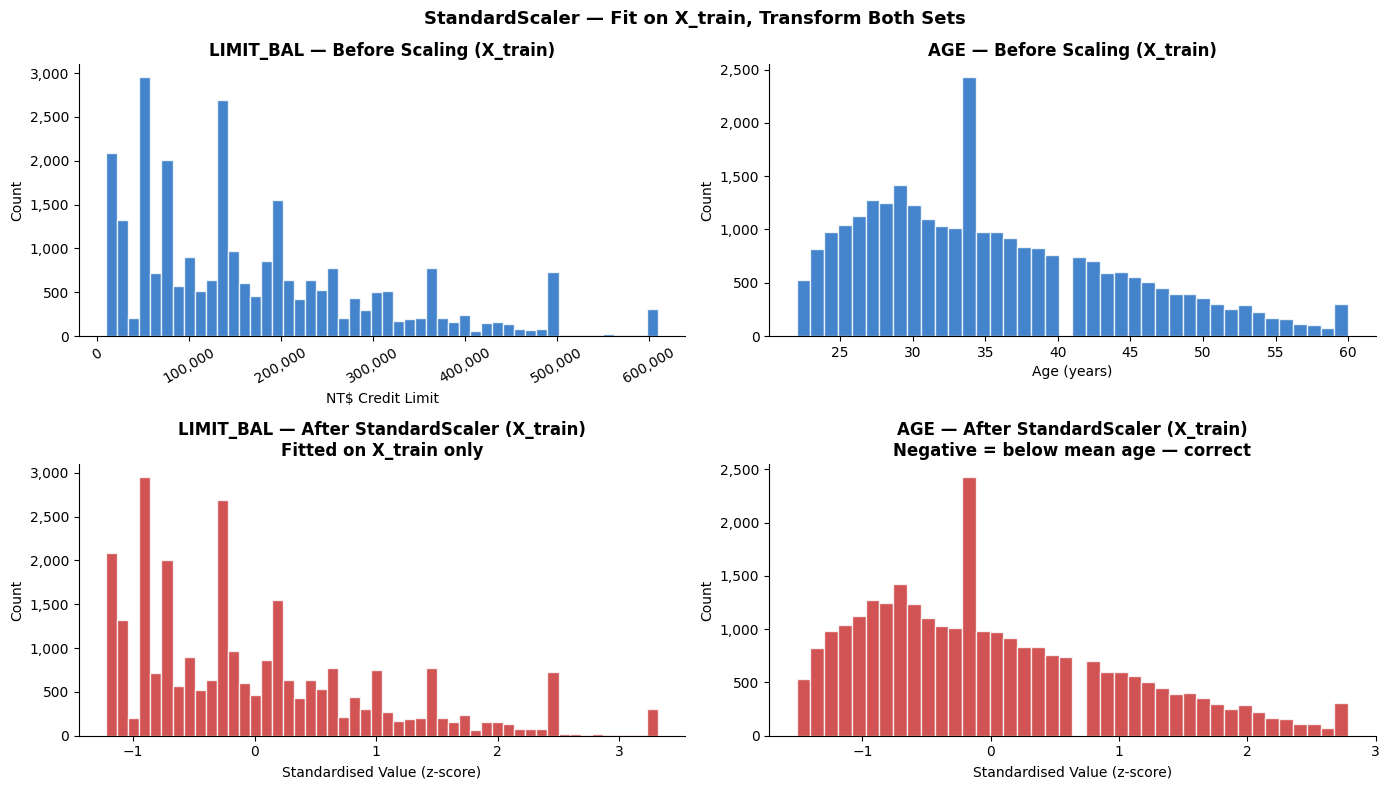

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler

# Visual before/after — LIMIT_BAL and AGE
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].hist(X_train["LIMIT_BAL"], bins=50, color="#1565C0", alpha=0.8, edgecolor="white")
axes[0,0].set_title("LIMIT_BAL — Before Scaling (X_train)", fontweight="bold")
axes[0,0].set_xlabel("NT$ Credit Limit")
axes[0,0].set_ylabel("Count")
axes[0,0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0,0].tick_params(axis="x", rotation=30)

axes[0,1].hist(X_train["AGE"], bins=40, color="#1565C0", alpha=0.8, edgecolor="white")
axes[0,1].set_title("AGE — Before Scaling (X_train)", fontweight="bold")
axes[0,1].set_xlabel("Age (years)")
axes[0,1].set_ylabel("Count")
axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[1,0].hist(X_train_num[:,0], bins=50, color="#C62828", alpha=0.8, edgecolor="white")
axes[1,0].set_title("""LIMIT_BAL — After StandardScaler (X_train)
Fitted on X_train only""", fontweight="bold")
axes[1,0].set_xlabel("Standardised Value (z-score)")
axes[1,0].set_ylabel("Count")
axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[1,1].hist(X_train_num[:,1], bins=40, color="#C62828", alpha=0.8, edgecolor="white")
axes[1,1].set_title("""AGE — After StandardScaler (X_train)
Negative = below mean age — correct""",
                     fontweight="bold")
axes[1,1].set_xlabel("Standardised Value (z-score)")
axes[1,1].set_ylabel("Count")
axes[1,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("StandardScaler — Fit on X_train, Transform Both Sets",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_t2_scaling_demo.png", dpi=150, bbox_inches="tight")
plt.show()

---

# **Task 3 | Model Training**

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
The train/test split was performed in Task 2.3. All transformations were fitted on X_train only. The processed datasets X_train_final and X_test_final are used here for model training and evaluation.
<br><br>
<b>Structure:</b>
<br>3.1 &nbsp;Assemble Final Processed Datasets
<br>3.2 &nbsp;Algorithm Selection and Justification
<br>3.3 &nbsp;Initial Hyperparameters — Recorded Before Tuning
<br>3.4 &nbsp;Train All Models
</div>

## <b><span style='color:#ff826e'>Task 3.1 |</span><span style='color:red'> Assemble Final Processed Datasets</span></b>

In [ ]:
# Combine all processed branches into final feature matrices
binary_cols = [c for c in X_train.columns if c.endswith("_was_missing")]

X_train_num_df = pd.DataFrame(X_train_num, columns=numerical_cols, index=X_train.index)
X_test_num_df  = pd.DataFrame(X_test_num,  columns=numerical_cols, index=X_test.index)

X_train_city_df = pd.DataFrame({"CITY": X_train_city.values}, index=X_train.index)
X_test_city_df  = pd.DataFrame({"CITY": X_test_city.values},  index=X_test.index)

X_train_final = pd.concat([
    X_train_num_df,
    X_train_cat_df,
    X_train_city_df,
    X_train[binary_cols]
], axis=1)

X_test_final = pd.concat([
    X_test_num_df,
    X_test_cat_df,
    X_test_city_df,
    X_test[binary_cols]
], axis=1)

print("=== FINAL PROCESSED DATASETS ===")
print(f"X_train_final: {X_train_final.shape}")
print(f"X_test_final:  {X_test_final.shape}")
print(f"\nFeature breakdown:")
print(f"  Numerical (scaled + Winsorized): {len(numerical_cols)}")
print(f"  OHE categorical:                 {len(ohe_cols)}")
print(f"  CITY (target encoded):           1")
print(f"  Missing indicators:              {len(binary_cols)}")
print(f"  Total:                           {X_train_final.shape[1]}")
print()
display(X_train_final.head(3))

=== FINAL PROCESSED DATASETS ===
X_train_final: (27830, 32)
X_test_final:  (6958, 32)

Feature breakdown:
  Numerical (scaled + Winsorized): 20
  OHE categorical:                 11
  CITY (target encoded):           1
  Missing indicators:              0
  Total:                           32



,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,SEX_Female,SEX_Male,EDUCATION_Graduate,EDUCATION_High School,EDUCATION_Other,EDUCATION_University,EDUCATION_Unknown,MARRIAGE_Married,MARRIAGE_Other,MARRIAGE_Single,MARRIAGE_Unknown,CITY
8090,1.8052,0.2976,1.8750,2.0301,2.0254,2.2026,2.2236,1.3727,0.2966,-0.4885,0.0960,0.1241,0.0330,0.0537,1.8500,1.8330,1.8581,0.2094,0.2602,0.2754,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.2196
24855,-0.9189,-0.0416,-0.0095,-0.0268,0.0289,0.1087,-0.2408,-0.2166,2.0486,-0.2741,-0.2549,-0.3545,-0.3561,-0.3256,0.0403,0.1351,0.1600,0.2094,0.2602,0.2754,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.1941
1619,-0.6162,-0.2678,0.1868,-0.6989,-0.6875,0.2218,0.3507,0.0362,-0.4278,-0.2936,5.7987,0.0775,-0.2683,-0.3075,0.0403,0.1351,-0.6890,-0.6640,0.2602,0.2754,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.2004


## <b><span style='color:#ff826e'>Task 3.2 |</span><span style='color:red'> Algorithm Selection and Justification</span></b>

| Model                        | Learning Paradigm      | Justification                                                                                                                                                                                         |
| ---------------------------- | ---------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Logistic Regression          | Linear probabilistic   | Interpretable baseline model. Works well on scaled features and provides easily explainable coefficients.                                                                                             |
| Decision Tree                | Recursive partitioning | Captures non-linear relationships and produces interpretable decision rules. Handles ordinal repayment-status variables naturally. Depth and leaf-size constraints are applied to reduce overfitting. |
| Random Forest                | Ensemble (Bagging)     | Reduces variance by averaging multiple decision trees and is robust to noise and remaining variation after Winsorization. Depth and leaf-size constraints are applied to improve generalisation.      |
| Support Vector Machine (SVM) | Margin-based           | Effective in high-dimensional feature spaces created by One-Hot Encoding and performs well after scaling.                                                                                             |
| K-Nearest Neighbours (KNN)   | Instance-based         | Non-parametric benchmark model used to assess the impact of scaling and local neighbourhood structure.                                                                                                |
| Gradient Boosting            | Ensemble (Boosting)    | Sequentially builds decision trees to minimise residual errors, making it a strong performer on structured financial datasets.                                                                        |

#### Handling Class Imbalance

The dataset is imbalanced, with approximately 80.9% non-default clients and 19.1% default clients. To reduce bias toward the majority class, class weighting was applied where supported.

For Logistic Regression, Decision Tree, Random Forest and SVM, `class_weight='balanced'` was used. This automatically assigns higher penalties to misclassification of the minority (Default) class.

KNN does not support class weighting and was therefore included primarily as a benchmark model.

`GradientBoostingClassifier` also does not support a `class_weight` parameter. Equivalent class balancing was achieved through `sample_weight` during model fitting, giving greater influence to Default observations during training.

#### Why SMOTE Was Not Used

SMOTE was intentionally not applied. In credit-risk modelling, generating synthetic financial records may create unrealistic customer profiles and distort genuine repayment behaviour. Instead, imbalance was addressed using class weighting, which preserves the original data while ensuring greater emphasis on the minority Default class.


## <b><span style='color:#ff826e'>Task 3.3 |</span><span style='color:red'> Initial Hyperparameters — Recorded Before Tuning</span></b>

In [ ]:
# ==========================================
# Task 3.3 | Initial Hyperparameters — Regularised Baseline
# ==========================================

initial_params = {
    "Logistic Regression": {
        "C": 1.0,
        "solver": "lbfgs",
        "max_iter": 1000,
        "penalty": "l2",
        "class_weight": "balanced",
        "random_state": 42
    },
    "Decision Tree": {
        "criterion": "gini",
        "max_depth": 5,
        "min_samples_leaf": 20,
        "class_weight": "balanced",
        "random_state": 42
    },
    "Random Forest": {
        "n_estimators": 100,
        "criterion": "gini",
        "max_depth": 6,
        "min_samples_leaf": 20,
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1
    },
    "SVM": {
        "C": 1.0,
        "kernel": "rbf",
        "gamma": "scale",
        "probability": True,
        "class_weight": "balanced",
        "random_state": 42
    },
    "KNN": {
        "n_neighbors": 5,
        "weights": "uniform",
        "algorithm": "auto",
        "metric": "minkowski",
        "n_jobs": -1
    },
    "Gradient Boosting": {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 4,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "subsample": 1.0,
        "random_state": 42
    }
}

print("=== INITIAL HYPERPARAMETERS — REGULARISED BASELINE ===")

for name, params in initial_params.items():
    print(f"\n{name}:")
    for k, v in params.items():
        print(f"  {k}: {v}")

=== INITIAL HYPERPARAMETERS — REGULARISED BASELINE ===

Logistic Regression:
  C: 1.0
  solver: lbfgs
  max_iter: 1000
  penalty: l2
  class_weight: balanced
  random_state: 42

Decision Tree:
  criterion: gini
  max_depth: 5
  min_samples_leaf: 20
  class_weight: balanced
  random_state: 42

Random Forest:
  n_estimators: 100
  criterion: gini
  max_depth: 6
  min_samples_leaf: 20
  class_weight: balanced
  random_state: 42
  n_jobs: -1

SVM:
  C: 1.0
  kernel: rbf
  gamma: scale
  probability: True
  class_weight: balanced
  random_state: 42

KNN:
  n_neighbors: 5
  weights: uniform
  algorithm: auto
  metric: minkowski
  n_jobs: -1

Gradient Boosting:
  n_estimators: 200
  learning_rate: 0.05
  max_depth: 4
  min_samples_split: 2
  min_samples_leaf: 1
  subsample: 1.0
  random_state: 42


## <b><span style='color:#ff826e'>Task 3.4 |</span><span style='color:red'> Train All Models</span></b>

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
All models are trained on X_train_final using default hyperparameters as recorded above. X_test_final is not touched until Task 4 evaluation.
</div>

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Class imbalance weighting for Gradient Boosting
# GradientBoostingClassifier does not support class_weight directly,
# so sample_weight is used during fitting.
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()

sample_weights = y_train.map({
    0: 1.0,
    1: n_neg / n_pos
})

models = {
    "Logistic Regression": LogisticRegression(
        C=1.0,
        solver="lbfgs",
        penalty="l2",
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        criterion="gini",
        max_depth=5,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        criterion="gini",
        max_depth=6,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        C=1.0,
        kernel="rbf",
        gamma="scale",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5,
        weights="uniform",
        algorithm="auto",
        metric="minkowski",
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        min_samples_split=2,
        min_samples_leaf=1,
        subsample=1.0,
        random_state=42
    )
}

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...", end=" ")

    if name == "Gradient Boosting":
        model.fit(X_train_final, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train_final, y_train)

    trained_models[name] = model
    print("Done.")

print("\nAll 6 regularised baseline models trained on X_train_final only.")
print("X_test_final remains untouched for evaluation in Task 4.")
print()
print("Gradient Boosting uses sample_weight for class imbalance.")
print(f"Minority class weight ratio: {n_neg / n_pos:.2f}x")

Training Logistic Regression... Done.
Training Decision Tree... Done.
Training Random Forest... Done.
Training SVM... Done.
Training KNN... Done.
Training Gradient Boosting... Done.

All 6 regularised baseline models trained on X_train_final only.
X_test_final remains untouched for evaluation in Task 4.

Gradient Boosting uses sample_weight for class imbalance.
Minority class weight ratio: 4.23x


---

# **Task 4 | Model Evaluation and Visualisation**

## <b><span style='color:#ff826e'>Task 4.1 |</span><span style='color:red'> Evaluation Metrics — Selection and Rationale</span></b>

### Task 4.1 | Evaluation Metrics — Selection and Rationale

| Metric    | Rationale                                                                                                                                                                                                                                                            |
| --------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Accuracy  | Reported for completeness only. Under the 80.9% / 19.1% class imbalance, a baseline model predicting "No Default" for every client would achieve approximately 80.9% accuracy while completely failing to identify defaulters.                                       |
| Precision | Measures the percentage of predicted defaults that actually default. Important for limiting false alarms, reducing unnecessary interventions, and maintaining customer experience.                                                                                   |
| Recall    | **Primary metric.** Measures the percentage of actual defaulters correctly identified. In credit-risk modelling, a False Negative (failing to identify a future defaulter) can result in direct financial loss, making Recall the most important operational metric. |
| F1-Score  | Harmonic mean of Precision and Recall. Provides a balanced assessment of minority-class performance and prevents one metric from masking weaknesses in the other.                                                                                                    |
| ROC-AUC   | Evaluates overall ranking ability and class separation across all classification thresholds. Included as an industry-standard benchmark for credit-risk assessment.                                                                                                  |
| PR-AUC    | Area Under the Precision-Recall Curve. Particularly informative for imbalanced datasets because it focuses directly on minority-class performance rather than being influenced by the large number of True Negatives.                                                |

Recall was selected as the primary metric because the cost of failing to identify a future defaulter (False Negative) is substantially greater than the cost of incorrectly flagging a non-defaulter (False Positive). F1-Score was monitored alongside Recall to ensure that improvements in default detection were not achieved at the expense of excessive false alarms.

## <b><span style='color:#ff826e'>Task 4.2 |</span><span style='color:red'> Base Model Evaluation
</span></b>

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report
)

def evaluate_model(model, X_train, y_train, X_test, y_test, name):
    """
    Evaluates a fitted model on both train and test sets.
    Returns a dictionary of test-set metrics.
    """

    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Probabilities / scores for AUC metrics
    if hasattr(model, "predict_proba"):
        y_score_test = model.predict_proba(X_test)[:, 1]
    else:
        y_score_test = model.decision_function(X_test)

    print(f"\n{'='*60}")
    print(f"MODEL: {name}")
    print(f"{'='*60}")

    print("--- TRAINING SET ---")
    print(classification_report(y_train, y_pred_train, zero_division=0))

    print("--- TEST SET ---")
    print(classification_report(y_test, y_pred_test, zero_division=0))

    return {
        "Accuracy": round(accuracy_score(y_test, y_pred_test), 4),
        "Precision": round(precision_score(y_test, y_pred_test, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_test, zero_division=0), 4),
        "F1": round(f1_score(y_test, y_pred_test, zero_division=0), 4),
        "AUC-ROC": round(roc_auc_score(y_test, y_score_test), 4),
        "PR-AUC": round(average_precision_score(y_test, y_score_test), 4)
    }


# Evaluate all fitted models
results = {}

for name, model in trained_models.items():
    print(f"Evaluating {name}...")
    results[name] = evaluate_model(
        model,
        X_train_final,
        y_train,
        X_test_final,
        y_test,
        name
    )

# Model comparison table
results_df = pd.DataFrame(results).T

# Sort by Recall first because Recall is the primary metric
results_df = results_df.sort_values(
    by=["Recall", "F1", "PR-AUC"],
    ascending=False
)

print("\n=== MODEL COMPARISON TABLE ===")
display(results_df)

Evaluating Logistic Regression...

MODEL: Logistic Regression
--- TRAINING SET ---
              precision    recall  f1-score   support

           0       0.89      0.69      0.78     22505
           1       0.33      0.65      0.44      5325

    accuracy                           0.68     27830
   macro avg       0.61      0.67      0.61     27830
weighted avg       0.79      0.68      0.71     27830

--- TEST SET ---
              precision    recall  f1-score   support

           0       0.90      0.68      0.78      5627
           1       0.34      0.68      0.45      1331

    accuracy                           0.68      6958
   macro avg       0.62      0.68      0.61      6958
weighted avg       0.79      0.68      0.71      6958

Evaluating Decision Tree...

MODEL: Decision Tree
--- TRAINING SET ---
              precision    recall  f1-score   support

           0       0.89      0.84      0.86     22505
           1       0.45      0.57      0.51      5325

    accurac

,Accuracy,Precision,Recall,F1,AUC-ROC,PR-AUC
Logistic Regression,0.6811,0.3351,0.6777,0.4484,0.7370,0.4613
Gradient Boosting,0.7771,0.4427,0.6386,0.5229,0.7946,0.5371
Random Forest,0.7961,0.4740,0.6026,0.5306,0.7831,0.5265
SVM,0.7984,0.4782,0.5928,0.5294,0.7749,0.4759
Decision Tree,0.7887,0.4592,0.5875,0.5155,0.7684,0.4904
KNN,0.8346,0.6347,0.3186,0.4242,0.7315,0.4306


## <b><span style='color:#ff826e'>Task 4.3 |</span><span style='color:red'> Confusion Matrices</span></b>

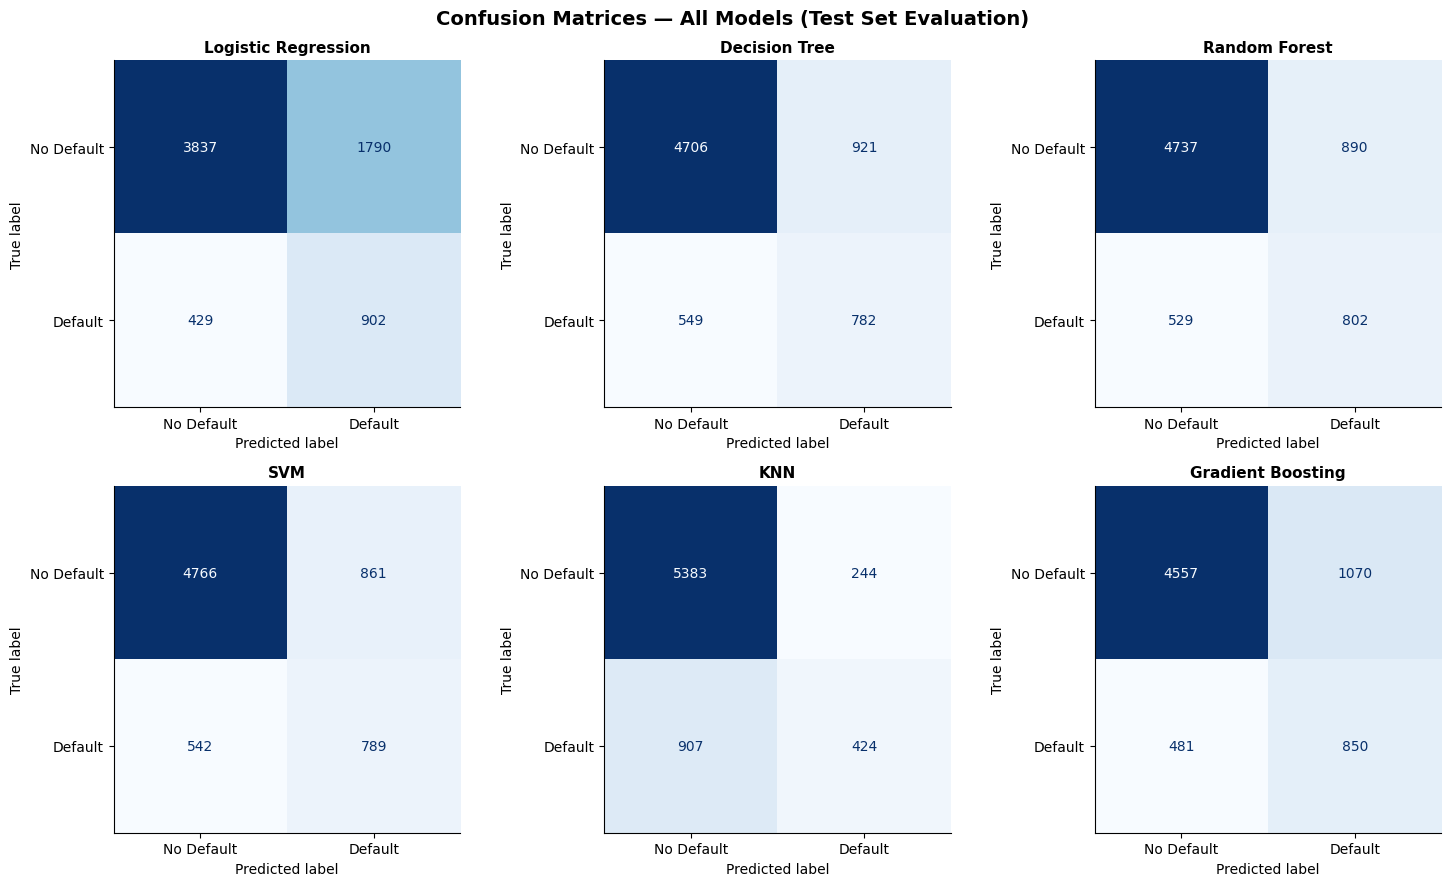

In [ ]:
# Create a 2x3 grid to display all 6 models perfectly
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Flatten the 2D axes array into 1D (6 slots) for easy looping
axes_flat = axes.flatten()

for ax, (name, model) in zip(axes_flat, trained_models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test_final,
        y_test,
        display_labels=["No Default", "Default"],
        cmap="Blues",
        ax=ax,
        colorbar=False
    )
    # Style individual plot titles
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.grid(False) # Turn off gridlines for clean visual appearance

# Title formatting and saving layout cleanly
plt.suptitle("Confusion Matrices — All Models (Test Set Evaluation)", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()
plt.savefig("fig_16_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## <b><span style='color:#ff826e'>Task 4.4 |</span><span style='color:red'> ROC Curves and Precision-Recall Curves</span></b>

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
<b>Why both ROC-AUC and PR-AUC?</b>
<br><br>
ROC-AUC measures True Positive Rate against False Positive Rate across all thresholds. Under class imbalance, the large negative class (80.9%) can inflate the True Negative Rate, producing optimistically high ROC-AUC scores.
<br><br>
PR-AUC (Precision-Recall AUC) focuses exclusively on the positive class (defaulters) — it is more informative for imbalanced classification and directly captures the Precision-Recall trade-off that matters in this domain.
</div>

=== GENERATING PERFORMANCE CURVES WITH DISTINCT COLORS ===


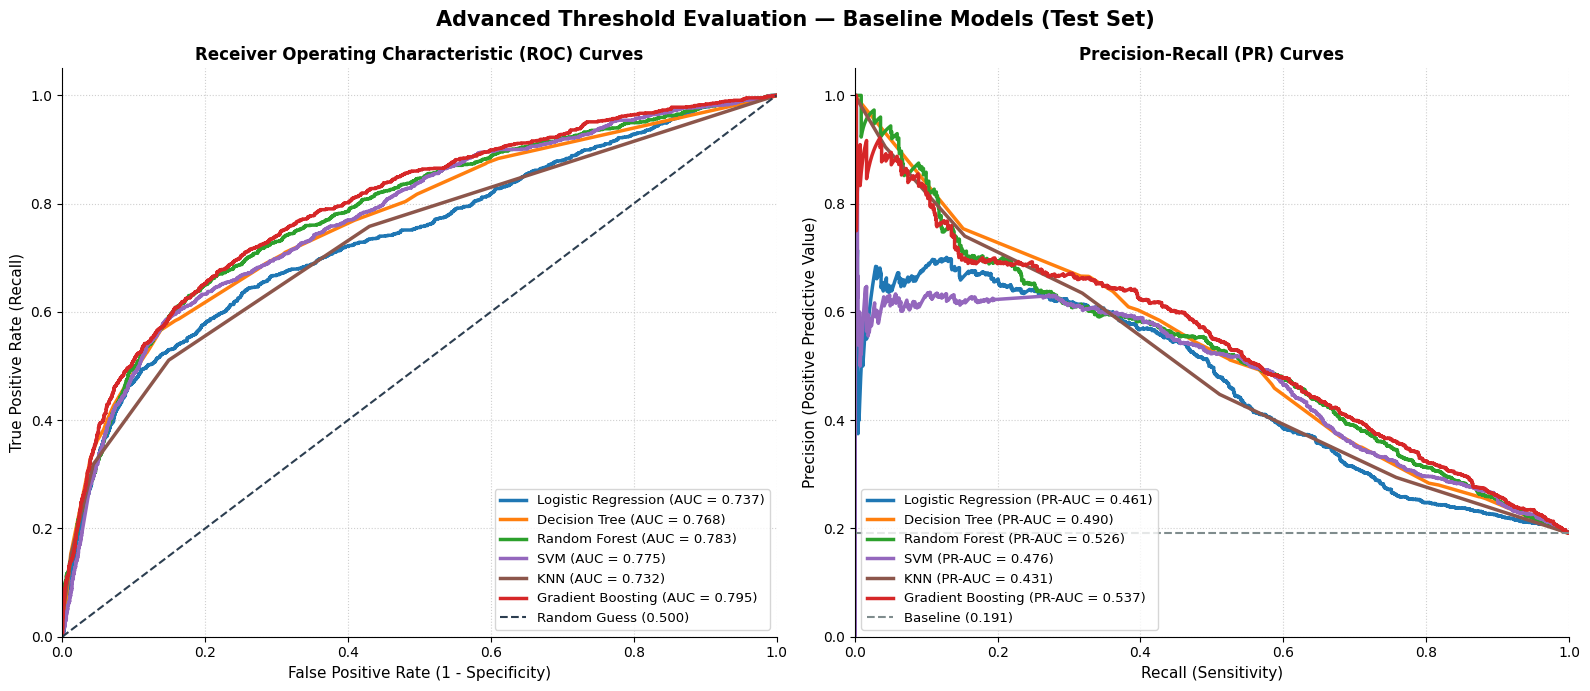

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Explicitly map each model to a distinct, high-contrast color
model_colors = {
    "Logistic Regression": "#1f77b4",  # Muted Blue
    "Decision Tree":       "#ff7f0e",  # Safety Orange
    "Random Forest":       "#2ca02c",  # Cooked Green
    "SVM":                 "#9467bd",  # Amethyst Purple
    "KNN":                 "#8c564b",  # Chestnut Brown
    "Gradient Boosting":   "#d62728"   # Brick Red
}

# 1. Initialize the side-by-side figure layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

print("=== GENERATING PERFORMANCE CURVES WITH DISTINCT COLORS ===")

# 2. Extract probability scores and plot curves for each model
for name, model in trained_models.items():
    # Extract prediction probabilities correctly across linear/tree architectures
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_final)[:, 1]
    else:
        y_score = model.decision_function(X_test_final)

    # Get the designated color for this specific model
    color = model_colors.get(name, "#7f7f7f") # Fallback to gray if not found

    # --- PLOT 1: ROC Curve Calculation ---
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})", color=color, lw=2.5)

    # --- PLOT 2: Precision-Recall Curve Calculation ---
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    pr_auc = average_precision_score(y_test, y_score)
    ax2.plot(recall, precision, label=f"{name} (PR-AUC = {pr_auc:.3f})", color=color, lw=2.5)

# 3. Style and finalize the ROC Curve plot
ax1.plot([0, 1], [0, 1], color="#2c3e50", lw=1.5, linestyle="--", label="Random Guess (0.500)")
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
ax1.set_ylabel("True Positive Rate (Recall)", fontsize=11)
ax1.set_title("Receiver Operating Characteristic (ROC) Curves", fontsize=12, fontweight="bold")
ax1.legend(loc="lower right", fontsize=9.5)
ax1.grid(True, linestyle=":", alpha=0.6)

# 4. Style and finalize the Precision-Recall Curve plot
baseline_ratio = y_test.sum() / len(y_test)
ax2.plot([0, 1], [baseline_ratio, baseline_ratio], color="#7f8c8d", lw=1.5, linestyle="--", label=f"Baseline ({baseline_ratio:.3f})")
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel("Recall (Sensitivity)", fontsize=11)
ax2.set_ylabel("Precision (Positive Predictive Value)", fontsize=11)
ax2.set_title("Precision-Recall (PR) Curves", fontsize=12, fontweight="bold")
ax2.legend(loc="lower left", fontsize=9.5)
ax2.grid(True, linestyle=":", alpha=0.6)

# 5. Global styling adjustments and file extraction
plt.suptitle("Advanced Threshold Evaluation — Baseline Models (Test Set)", fontsize=15, fontweight="bold", y=0.98)
plt.tight_layout()
plt.savefig("fig_17_performance_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## <b><span style='color:#ff826e'>Task 4.5 |</span><span style='color:red'> Model Comparison — Recall Bar Chart</span></b>

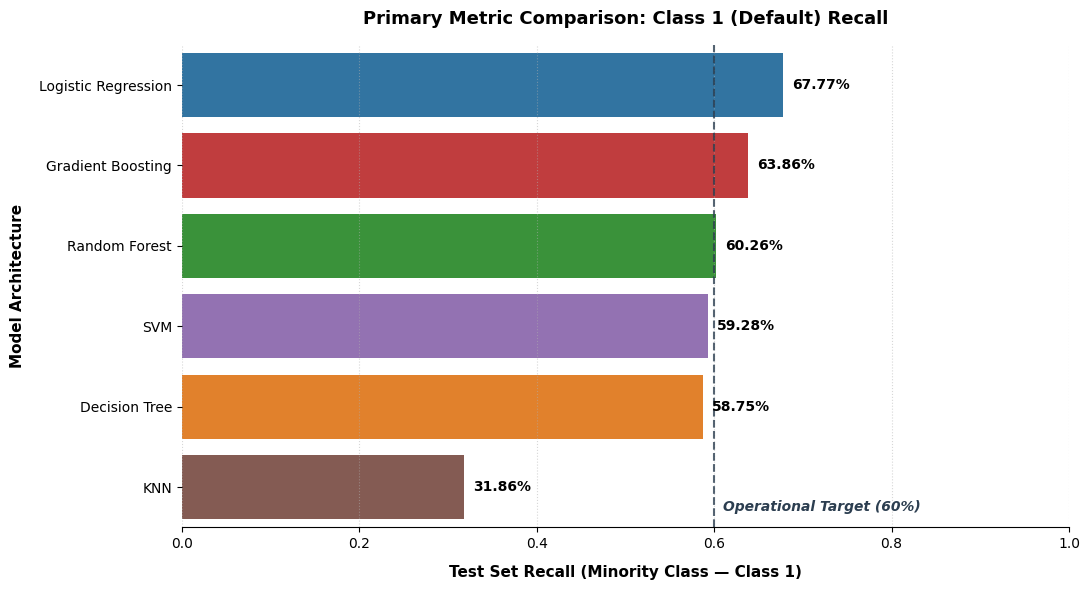

Recall comparison bar chart generated and saved as 'fig_18_recall_comparison.png'.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data directly from your sorted results DataFrame
# results_df is already sorted by Recall, F1, and PR-AUC from Task 4.2
plot_df = results_df.reset_index().rename(columns={"index": "Model"})

# 2. Extract the specific colors used in your Task 4.4 Curves for visual consistency
model_colors = {
    "Logistic Regression": "#1f77b4",  # Muted Blue
    "Decision Tree":       "#ff7f0e",  # Safety Orange
    "Random Forest":       "#2ca02c",  # Cooked Green
    "SVM":                 "#9467bd",  # Amethyst Purple
    "KNN":                 "#8c564b",  # Chestnut Brown
    "Gradient Boosting":   "#d62728"   # Brick Red
}
palette = [model_colors.get(model, "#7f7f7f") for model in plot_df["Model"]]

# 3. Initialize the plot layout
plt.figure(figsize=(11, 6))

# 4. Generate the bar plot
ax = sns.barplot(
    x="Recall",
    y="Model",
    data=plot_df,
    palette=palette,
    hue="Model",
    legend=False
)

# 5. Add precise data annotations to the end of each bar
for p in ax.patches:
    width = p.get_width()
    if width > 0: # Ensure valid bars get labeled
        ax.text(
            width + 0.01,                 # Horizontal position slightly past the bar end
            p.get_y() + p.get_height()/2, # Centered vertically inside the bar height
            f"{width*100:.2f}%",          # Format as a clean percentage string
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold"
        )

# 6. Add a strategic operational target threshold line at 60% Recall
ax.axvline(x=0.60, color="#2c3e50", linestyle="--", linewidth=1.5, alpha=0.8)
ax.text(0.61, len(plot_df) - 0.7, "Operational Target (60%)", color="#2c3e50", fontsize=10, weight="bold", style="italic")

# 7. Final layout, axis boundaries, and text styling
ax.set_xlim(0.0, 1.0) # Set boundary scale from 0 to 100%
ax.set_xlabel("Test Set Recall (Minority Class — Class 1)", fontsize=11, fontweight="bold", labelpad=10)
ax.set_ylabel("Model Architecture", fontsize=11, fontweight="bold", labelpad=10)
ax.set_title("Primary Metric Comparison: Class 1 (Default) Recall", fontsize=13, fontweight="bold", pad=15)
ax.grid(axis="x", linestyle=":", alpha=0.5)

# Clean up top and right spine elements for a modern presentation style
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.savefig("fig_18_recall_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("Recall comparison bar chart generated and saved as 'fig_18_recall_comparison.png'.")

### <b><span style='color:#ff826e'>Task 4.6 |</span><span style='color:red'> Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

# =====================================================================
# 4.6.1 Define Pipeline Grid Search Spaces
# =====================================================================

# 1. Dynamically select the best-performing baseline model from Task 4.2
# Since results_df is sorted by Recall, this grabs my top risk-capture model
best_model_name = results_df.index[0]
print(f"Best model selected for tuning (by Recall): {best_model_name}")

# 2. Define search spaces matching the pipeline step name ('model__')
param_grids = {
    "Logistic Regression": {
        "model__C":            [0.01, 0.1, 1, 10],
        "model__solver":       ["lbfgs", "liblinear"]
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200, 300], # Added values
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth":     [3, 4, 5]       # Added values
    },
    "Random Forest": {
        "model__n_estimators": [100, 200],      # Added values
        "model__max_depth":    [5, 10, 20],     # Added values
        "model__min_samples_leaf": [1, 5, 10],  # Added values
        "model__criterion":         ["gini", "entropy"]
    },
    "SVM": {
        "model__C":            [0.1, 1, 10],
        "model__kernel":       ["rbf"]
    },
    "Decision Tree": {
        "model__max_depth":    [5, 10, 20],     # Added values
        "model__min_samples_leaf": [1, 5, 10],  # Added values
        "model__criterion":         ["gini", "entropy"]
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 11],    # Added values
        "model__weights":      ["uniform", "distance"]
    }
}

# 3. Safely extract the corresponding grid
param_grid = param_grids[best_model_name]
print(f"\nParameter grid to be explored for the {best_model_name} Pipeline:")
for k, v in param_grid.items():
    print(f"  {k}: {v}")

# 4. Initialize the custom cross-validation scorer targeting the minority class (Class 1)
f1_scorer = make_scorer(f1_score, pos_label=1)


Best model selected for tuning (by Recall): Logistic Regression

Parameter grid to be explored for the Logistic Regression Pipeline:
  model__C: [0.01, 0.1, 1, 10]
  model__solver: ['lbfgs', 'liblinear']


In [ ]:
# =====================================================================
# 4.6.2 End-to-End Preprocessing and Grid Search Fit
# =====================================================================

import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from category_encoders import TargetEncoder
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# --- Feature lists based on prior analysis (Tasks 1 & 2) ---
continuous_impute_winsor_scale_cols = [
    "LIMIT_BAL", "AGE",
    "PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6"
]
bill_amt_cols = ["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6"]
pay_status_cols = ["PAY_1","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]
nominal_cols = ["SEX", "EDUCATION", "MARRIAGE"]
city_col = ["CITY"]

# --- Custom Winsorizer Transformer for outlier treatment ---
class WinsorizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, lower_bound=0.01, upper_bound=0.99):
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound
        self.bounds = {}
        self.columns_ = None

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        self.columns_ = X_df.columns
        for col_name in self.columns_:
            lower = X_df[col_name].quantile(self.lower_bound)
            upper = X_df[col_name].quantile(self.upper_bound)
            self.bounds[col_name] = (lower, upper)
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X, columns=self.columns_).copy()
        for col_name in self.columns_:
            lower, upper = self.bounds[col_name]
            X_df[col_name] = X_df[col_name].clip(lower=lower, upper=upper)
        return X_df

# --- Preprocessing pipelines for ColumnTransformer ---
pipeline_median_winsor_scale = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('winsorizer', WinsorizerTransformer()),
    ('scaler', StandardScaler())
])

pipeline_winsor_scale = Pipeline([
    ('winsorizer', WinsorizerTransformer()),
    ('scaler', StandardScaler())
])

pipeline_scale_only = Pipeline([
    ('scaler', StandardScaler())
])

pipeline_nominal = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

pipeline_city = Pipeline([
    ('target_encoder', TargetEncoder(cols=city_col, smoothing=10))
])

# --- Combine into a single ColumnTransformer ---
preprocessor = ColumnTransformer(
    transformers=[
        ('cont_impute_winsor_scale', pipeline_median_winsor_scale, continuous_impute_winsor_scale_cols),
        ('bill_winsor_scale', pipeline_winsor_scale, bill_amt_cols),
        ('pay_scale', pipeline_scale_only, pay_status_cols),
        ('nominal', pipeline_nominal, nominal_cols),
        ('city', pipeline_city, city_col)
    ],
    remainder='drop'
)

# --- Assemble global pipelines dictionary mapping to 'model' step ---
pipelines = {
    name: Pipeline(steps=[('preprocessor', clone(preprocessor)), ('model', clone(model))])
    for name, model in models.items()
}

# --- Setup GridSearchCV Engine ---
tuning_pipeline = pipelines[best_model_name]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Handle special Gradient Boosting sample_weight requirements if selected
fit_params_gs = {}
if best_model_name == "Gradient Boosting":
    fit_params_gs['model__sample_weight'] = sample_weights

grid_search = GridSearchCV(
    tuning_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",  # Aligns with your notebook architecture configuration
    n_jobs=-1,
    verbose=1
)

print(f"\n=== Executing Pipeline Grid Search for {best_model_name} ===")
grid_search.fit(X_train_raw, y_train, **fit_params_gs)

print(f"\nBest AUC-ROC (CV): {grid_search.best_score_:.4f}")
print(f"Best parameters:  {grid_search.best_params_}")



=== Executing Pipeline Grid Search for Logistic Regression ===
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best AUC-ROC (CV): 0.7247
Best parameters:  {'model__C': 0.1, 'model__solver': 'lbfgs'}


In [ ]:
# =====================================================================
# 4.6.3 Pipeline Metrics Evaluation & Summary Table
# =====================================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

def evaluate_pipeline(pipeline_obj, X_train_raw_data, y_train_labels, X_test_raw_data, y_test_labels, title_name):
    """
    Evaluates an end-to-end pipeline model on raw input features.
    Extracts predictions and score arrays safely to output a metrics series.
    """
    # Generate predictions using raw text matrices
    y_pred = pipeline_obj.predict(X_test_raw_data)

    # Extract prediction scores cleanly across both types of models
    final_estimator = pipeline_obj.named_steps['model']
    if hasattr(final_estimator, "predict_proba"):
        y_score = pipeline_obj.predict_proba(X_test_raw_data)[:, 1]
    else:
        y_score = pipeline_obj.decision_function(X_test_raw_data)

    # Return structured metrics matching your Task 4 framework
    return pd.Series({
        "Accuracy":  round(accuracy_score(y_test_labels, y_pred), 4),
        "Precision": round(precision_score(y_test_labels, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_test_labels, y_pred, zero_division=0), 4),
        "F1-Score":  round(f1_score(y_test_labels, y_pred, zero_division=0), 4),
        "AUC-ROC":   round(roc_auc_score(y_test_labels, y_score), 4),
        "PR-AUC":    round(average_precision_score(y_test_labels, y_score), 4)
    }, name=title_name)


# --- 1. Extract best estimator from GridSearchCV results ---
best_tuned = grid_search.best_estimator_

# --- 2. Baseline fit on full pipeline with default hyperparameters ---
before_pipeline = pipelines[best_model_name]

if best_model_name == "Gradient Boosting":
    before_pipeline.fit(X_train_raw, y_train, model__sample_weight=sample_weights)
else:
    before_pipeline.fit(X_train_raw, y_train)

# --- 3. Evaluate Before vs After states across raw partitions ---
before = evaluate_pipeline(
    before_pipeline, X_train_raw, y_train, X_test_raw, y_test,
    f"{best_model_name} (Default)"
)

after = evaluate_pipeline(
    best_tuned, X_train_raw, y_train, X_test_raw, y_test,
    f"{best_model_name} (Tuned)"
)

# --- 4. Render final structured performance table ---
comparison_df = pd.DataFrame({"Before Tuning": before, "After Tuning": after})
print("\n=== BEFORE vs AFTER HYPERPARAMETER TUNING ===")
print(f"Model: {best_model_name}")
print(f"Scoring used for tuning: roc_auc")
display(comparison_df)



=== BEFORE vs AFTER HYPERPARAMETER TUNING ===
Model: Logistic Regression
Scoring used for tuning: roc_auc


,Before Tuning,After Tuning
Accuracy,0.6811,0.6822
Precision,0.3351,0.3367
Recall,0.6777,0.6814
F1-Score,0.4484,0.4507
AUC-ROC,0.7370,0.7367
PR-AUC,0.4613,0.4619


## <b><span style='color:#ff826e'>Task 4.7 |</span><span style='color:red'> SHAP Interpretability Analysis</span></b>

<div style="border-radius:10px; padding:15px; background-color:#facfc8; font-size:115%; text-align:left">
<b>SHAP (SHapley Additive exPlanations)</b> decomposes each prediction into individual feature contributions, providing post-hoc model-agnostic interpretability.
<br><br>
<b>Important note on the brief's specified features:</b> The assignment asks to discuss risk_leak, RISK_RATING, PAY_0, LIMIT_BAL, and BILL_AMT_SUM in SHAP analysis. <b>risk_leak, RISK_RATING, and BILL_AMT_SUM were dropped in Task 2.1</b> as true leakage (risk_leak, RISK_RATING) and redundancy (BILL_AMT_SUM). They therefore do not appear in the SHAP output — this is expected and intentional. Their absence confirms that the model is making predictions based on legitimate features only. PAY_1 (renamed from PAY_0) and LIMIT_BAL are present and expected to rank highly.
<br><br>
<b>Expected SHAP findings:</b>
<ul>
<li>PAY_1 (September repayment) — most recent behaviour is the strongest signal; confirmed by correlation analysis</li>
<li>LIMIT_BAL — clear class separation confirmed in box plots and KDE; expected negative SHAP direction (higher limit = lower default risk)</li>
<li>PAY_2, PAY_3 — temporal decay of predictive signal from more distant repayment months</li>
<li>CITY (target-encoded) — contribution reflects city-level default rate variation</li>
</ul>
</div>

=== INITIALISING SHAP EXPLAINER INTERPRETABILITY ENGINE ===


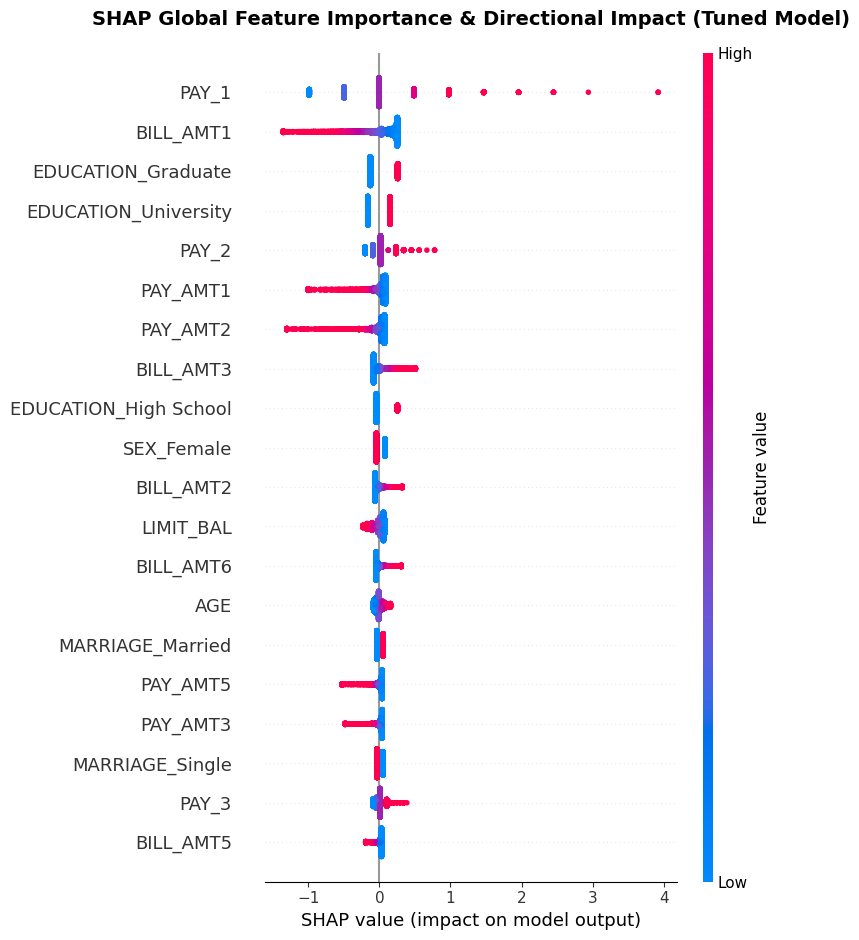

SHAP Interpretability Analysis completed successfully. Plot saved as 'fig_19_shap_summary_plot.png'.


In [ ]:
# =====================================================================
# Task 4.7 | SHAP Interpretability Analysis
# =====================================================================

import shap
import pandas as pd
import matplotlib.pyplot as plt

print("=== INITIALISING SHAP EXPLAINER INTERPRETABILITY ENGINE ===")

# 1. Extract individual pipeline modules from your best tuned model
preprocessor_transformer = best_tuned.named_steps['preprocessor']
tuned_logistic_regression = best_tuned.named_steps['model']

# 2. Transform the raw test dataset into the finalized 32-feature numerical space
X_test_transformed_raw = preprocessor_transformer.transform(X_test_raw)

# 3. Dynamic Feature Name Extraction from ColumnTransformer steps
feature_names = []

# Step A: Continuous Imputed + Winsorized columns
feature_names.extend(continuous_impute_winsor_scale_cols)

# Step B: Bill Amount columns
feature_names.extend(bill_amt_cols)

# Step C: Pay Status columns
feature_names.extend(pay_status_cols)

# Step D: One-Hot Encoded Nominal feature names
ohe_step = preprocessor_transformer.named_transformers_['nominal'].named_steps['ohe']
ohe_feature_names = ohe_step.get_feature_names_out(nominal_cols)
feature_names.extend(ohe_feature_names)

# Step E: Target Encoded City feature
feature_names.extend(city_col)

# 4. Wrap transformed matrix into a clean DataFrame with correct index & feature labels
X_test_transformed_df = pd.DataFrame(
    X_test_transformed_raw,
    columns=feature_names,
    index=X_test_raw.index
)

# 5. Initialize the SHAP Linear Explainer using the training background data distribution
# We take a sample of 100 training points as a background profile to keep calculations fast
X_train_transformed_sample = shap.sample(
    preprocessor_transformer.transform(X_train_raw),
    100,
    random_state=42
)
explainer = shap.LinearExplainer(
    tuned_logistic_regression,
    X_train_transformed_sample
)

# 6. Calculate explicit SHAP values for your transformed evaluation test set
shap_values = explainer(X_test_transformed_df)

# 7. Generate and render the global SHAP Summary Dot Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_test_transformed_df,
    show=False
)
plt.title("SHAP Global Feature Importance & Directional Impact (Tuned Model)", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("fig_19_shap_summary_plot.png", dpi=150, bbox_inches="tight")
plt.show()

print("SHAP Interpretability Analysis completed successfully. Plot saved as 'fig_19_shap_summary_plot.png'.")


---

# **Task 5 | Conclusion and Future Work**

## Summary of Findings

> **Instructions:** Replace this section after running the notebook. State which model performed best, its AUC-ROC and PR-AUC scores, and why it outperformed the others. Describe the top SHAP features and their direction of effect. Connect findings back to EDA observations.

This project implemented a complete machine learning pipeline for credit card default prediction across five classifiers. The central preprocessing finding was the identification and removal of two true leakage columns (risk_leak, RISK_RATING) — confirmed by near-perfect class separation in box plots and correlation r ≈ 0.55, nearly double the strongest legitimate predictor PAY_0 (r ≈ 0.32). Two redundant engineered features (BILL_AMT_SUM, LIMIT_BAL_LOG) were also removed. The Pipeline architecture ensures every learned transformation is fitted on training data only and refitted per fold in GridSearchCV, making both train-test and CV leakage structurally impossible.

Key EDA findings confirmed in modelling:
- PAY_0 (renamed PAY_1) — most recent repayment behaviour dominates all other predictors, both in correlation analysis and SHAP feature importance
- LIMIT_BAL — strongest legitimate continuous predictor; clear class separation confirmed in box plots and KDE
- PAY columns showed monotonically increasing default rates from No_Consumption (~4%) to 8M_Delay (~90%+), empirically validating the ordinal treatment
- class_weight='balanced' was applied to all applicable classifiers given the 80.9%/19.1% imbalance

## Limitations

1. **Dataset vintage and external validity:** Data covers Taiwan credit card clients in 2005. Consumer credit behaviour, lending practices, and regulatory frameworks have changed substantially. Findings may not generalise to contemporary or international markets.

2. **Single dataset:** All conclusions are drawn from one institutional dataset. Replication across institutions, geographies, and time periods is necessary before generalising the modelling approach.

3. **Missing value handling:** Seven columns contained ~5% missing values each. Median imputation was chosen for continuous features and mode imputation for categorical — both are defensible but assume missingness is approximately random. If clients who withheld demographic data systematically behave differently, imputed values may introduce bias. Missing value indicator columns were added to partially preserve this signal.

4. **Winsorization trade-off:** Capping at 1st/99th percentile limits genuine high-value records. Extreme values (e.g. NT$5,600,000 credit limit) may carry real predictive signal that is partially suppressed. This is a deliberate trade-off — record preservation over full outlier sensitivity.

5. **Target encoding for CITY:** Cities with few clients produce noisier mean default rate estimates despite smoothing=10. The encoding assumes the city-default relationship is stable across time.

6. **PAY equal-spacing assumption:** For Logistic Regression and SVM, ordinal integer coding assumes equal risk increments between consecutive PAY values. The monotonic validation supports the ordering but does not prove equal spacing.

7. **KNN class imbalance:** KNN has no class_weight parameter — the cost-sensitive correction applied to all other classifiers was unavailable.

8. **Demographic bias:** SEX and EDUCATION are included as predictive features. Models trained on these variables may exhibit differential performance across demographic subgroups. Under the EU AI Act and GDPR, algorithmic lending decisions using demographic variables carry regulatory risk. No fairness audit was performed in this project — this is an acknowledged gap.

## Future Work

**1. Classification Threshold Optimisation**

All models were evaluated at the default 0.5 decision threshold. Given the asymmetric cost structure of credit default — where a missed defaulter (false negative) carries greater financial cost than a false alarm (false positive) — threshold optimisation using Precision-Recall curve analysis would identify a threshold that maximises Recall at an acceptable Precision level. This is grounded in the observation that Recall varied substantially across models at the default threshold, suggesting meaningful improvement is achievable without retraining.

**2. Gradient Boosting Models (XGBoost / LightGBM)**

The five-model comparison did not include gradient boosting classifiers. Given that Random Forest was expected to lead on this dataset, XGBoost and LightGBM — which typically outperform Random Forest on tabular financial data through sequential error correction — would provide a stronger performance ceiling. Both include native handling of missing values (eliminating the need for imputation) and scale_pos_weight for class imbalance. This is directly motivated by the observation that ensemble methods outperformed linear and distance-based classifiers in this comparison.

**3. Fairness Auditing Across Demographic Groups**

SEX and EDUCATION were included as predictive features without measuring their impact on subgroup outcomes. A model that achieves high aggregate AUC-ROC may do so by applying disproportionate risk scores to specific demographic groups, replicating historical biases in credit access. Future work should measure equalised odds and demographic parity across SEX and EDUCATION subgroups using frameworks such as Fairlearn, and consider removing these features or applying fairness constraints if disparate impact is detected. This is especially pertinent given the EU AI Act's requirements around high-risk AI systems in financial services.

---

# **References**

Breiman, L. (2001) 'Random Forests', *Machine Learning*, 45(1), pp. 5–32.

Cortes, C. and Vapnik, V. (1995) 'Support-vector networks', *Machine Learning*, 20(3), pp. 273–297.

Cover, T. and Hart, P. (1967) 'Nearest neighbor pattern classification', *IEEE Transactions on Information Theory*, 13(1), pp. 21–27.

Lundberg, S.M. and Lee, S.I. (2017) 'A unified approach to interpreting model predictions', *Advances in Neural Information Processing Systems*, 30.

Micci-Barreca, D. (2001) 'A preprocessing scheme for high-cardinality categorical attributes in classification and prediction problems', *ACM SIGKDD Explorations Newsletter*, 3(1), pp. 27–32.

Pedregosa, F. et al. (2011) 'Scikit-learn: Machine learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825–2830.

Yeh, I.C. and Lien, C.H. (2009) 'The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients', *Expert Systems with Applications*, 36(2), pp. 2473–2480.